In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tqdm.notebook import tqdm
import json
import h5py
import os

import warnings
warnings.filterwarnings("ignore")

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model
from DiscEvolution.constants import *

In [2]:
def h5_to_dict(h5obj):
    out = {}
    for k, v in h5obj.items():
        if isinstance(v, h5py.Dataset):
            out[k] = v[()]          # load dataset into memory
        else:
            out[k] = h5_to_dict(v)  # recurse into group
    return out     

crPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/HWFix/CR_1.0Myr/New_Elsasser/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260910_114110.h5"
xrPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/HWFix/XR_1.0Myr/New_Elsasser/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260910_114208.h5"
cxPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/HWFix/CRXR_1.0Myr/New_Elsasser/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260910_113949.h5"

print('\n  -------- data ---------')
with h5py.File(crPath, "r") as crf:
    CR = h5_to_dict(crf)
    CRattr = dict(crf.attrs)

for i in CR.keys():
    print(i)

with h5py.File(xrPath, "r") as xrf:
    XR = h5_to_dict(xrf)
    XRattr = dict(xrf.attrs)

with h5py.File(cxPath, "r") as cxf:
    CX = h5_to_dict(cxf)
    CXattr = dict(cxf.attrs)



  -------- data ---------
B_xe
C_xe
D_xe
H
JXR
Lambda
M_iso
M_transition
Mcs
Mdot_r
Mes
NH
P
R
R_dz
R_dz_t
R_faces
Rp
Sigc
Sigma_G
Sigma_dust
Sigma_grain_size
Sigma_pebble_size
Sigma_pebbles
Sigma_planetesimals
St
T
Tc
Vdrift
X_cores
X_envs
alpha_R
disk_Mass
disk_Mdot_p
disk_Mdot_star
disk_atom_gas_abund
disk_atom_ice_abund
disk_ice_lines
disk_mol_gas_abund
disk_mol_ice_abund
disk_planetesimal_atom_abund
disk_planetesimal_mol_abund
eta_diff
ice_lines
n_density
nu
psi_R
rho_mid
sigmaXR
t
tau_XR
time_snap
v_r
xe
zeta
zeta_CR
zeta_XR


In [3]:
crR = CR["R"]
crtsnap = CR["time_snap"]    # Myr        
crSigma_g = CR["Sigma_G"]   
crRdz = CR['R_dz_t']
crt = CR["t"]                # yr
crZeta = CR['zeta']
crZetaCR = CR['zeta_CR']
crZetaXR = CR['zeta_XR']
crLam = CR['Lambda']
crT = CR['T']
crxe = CR['xe']
creta = CR['eta_diff']
crn = CR['n_density']
cralpha = CR['alpha_R']
crpsi = CR['psi_R']
crv_r = CR['v_r']
crMdot_r = CR['Mdot_r']
crR_faces = CR['R_faces']

xrR = XR["R"]
xrtsnap = XR["time_snap"]    # Myr        
xrSigma_g = XR["Sigma_G"]   
xrRdz = XR['R_dz_t']
xrt = XR["t"]                # yr
xrZeta = XR['zeta']
xrZetaCR = XR['zeta_CR']
xrZetaXR = XR['zeta_XR']
xrLam = XR['Lambda']
xrT = XR['T']
xrxe = XR['xe']
xreta = XR['eta_diff']
xrn = XR['n_density']
xralpha = XR['alpha_R']
xrpsi = XR['psi_R']
xrv_r = XR['v_r']
xrMdot_r = XR['Mdot_r']
xrR_faces = XR['R_faces']

cxR = CX["R"]
cxtsnap = CX["time_snap"]    # Myr        
cxSigma_g = CX["Sigma_G"]   
cxRdz = CX['R_dz_t']
cxt = CX["t"]                # yr
cxZeta = CX['zeta']
cxZetaCR = CX['zeta_CR']
cxZetaXR = CX['zeta_XR']
cxLam = CX['Lambda']
cxT = CX['T']
cxxe = CX['xe']
cxeta = CX['eta_diff']
cxn = CX['n_density']
cxalpha = CX['alpha_R']
cxpsi = CX['psi_R']
cxv_r = CX['v_r']
cxMdot_r = CX['Mdot_r']
cxR_faces = CX['R_faces']

In [4]:
arr1 = crtsnap*1e6
arr2 = crt
idx = np.searchsorted(arr2, arr1)           # Find the insertion positions
idx = np.clip(idx, 1, len(arr2) - 1)        # Handle edge cases where the index falls outside array boundaries
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])   # Check whether the left or right neighbor is closer
closest_indices = np.where(left_closer, idx - 1, idx)
cridx = closest_indices
print(cridx)

arr1 = xrtsnap*1e6
arr2 = xrt
idx = np.searchsorted(arr2, arr1)           # Find the insertion positions
idx = np.clip(idx, 1, len(arr2) - 1)        # Handle edge cases where the index falls outside array boundaries
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])   # Check whether the left or right neighbor is closer
closest_indices = np.where(left_closer, idx - 1, idx)
xridx = closest_indices
print(xridx)

arr1 = cxtsnap*1e6
arr2 = cxt
idx = np.searchsorted(arr2, arr1)           # Find the insertion positions
idx = np.clip(idx, 1, len(arr2) - 1)        # Handle edge cases where the index falls outside array boundaries
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])   # Check whether the left or right neighbor is closer
closest_indices = np.where(left_closer, idx - 1, idx)
cxidx = closest_indices
print(cxidx)

print(crtsnap)

[   0   14  149  294  412  529  644  757  869  978 1085 1177]
[   0   13  141  261  379  495  610  723  834  944 1052 1148]
[   0   14  148  290  453  700  911 1066 1190 1300 1404 1496]
[0.    0.005 0.1   0.2   0.3   0.4   0.5   0.6   0.7   0.8   0.9   1.   ]


# Ionization Rates

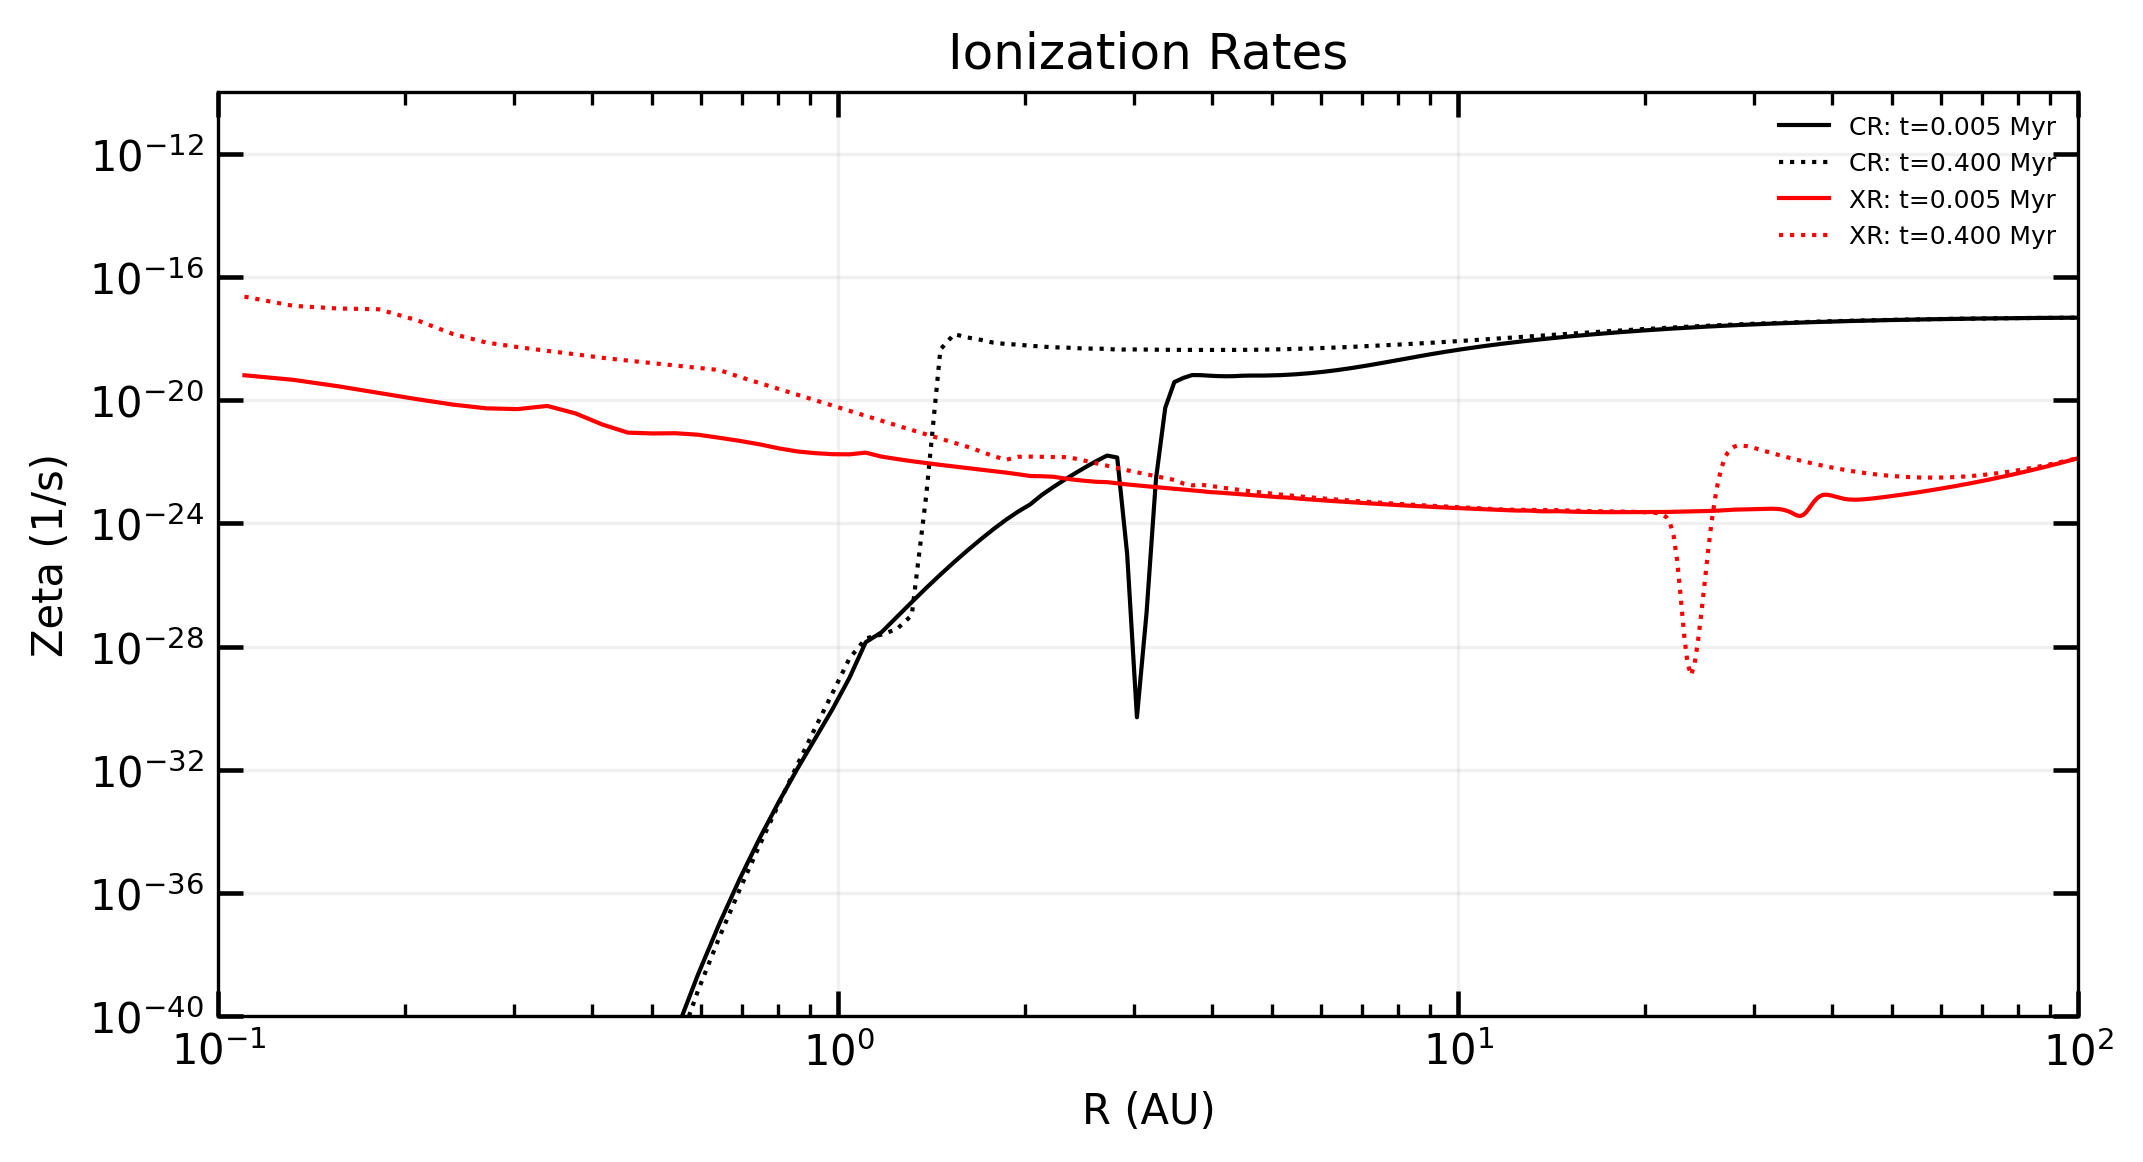

In [5]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('Ionization Rates')
ax.set_xlim(0.1,100)
ax.set_ylim(1e-40,1e-10)

ax.loglog(crR, crZeta[cridx[1]], linestyle='solid', color='black', label=rf"CR: t={crt[cridx[1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crZeta[cridx[5]], linestyle='dotted', color='black', label=rf"CR: t={crt[cridx[5]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrZeta[xridx[1]], linestyle='solid', color='red', label=rf"XR: t={xrt[xridx[1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrZeta[xridx[5]], linestyle='dotted', color='red', label=rf"XR: t={xrt[xridx[5]]/1e6:.3f} Myr", lw = 1.0)
# ax.loglog(cxR, cxZeta[cxidx[1]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[1]]/1e6:.3f} Myr", lw = 1.0)
# ax.loglog(cxR, cxZeta[cxidx[5]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[5]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

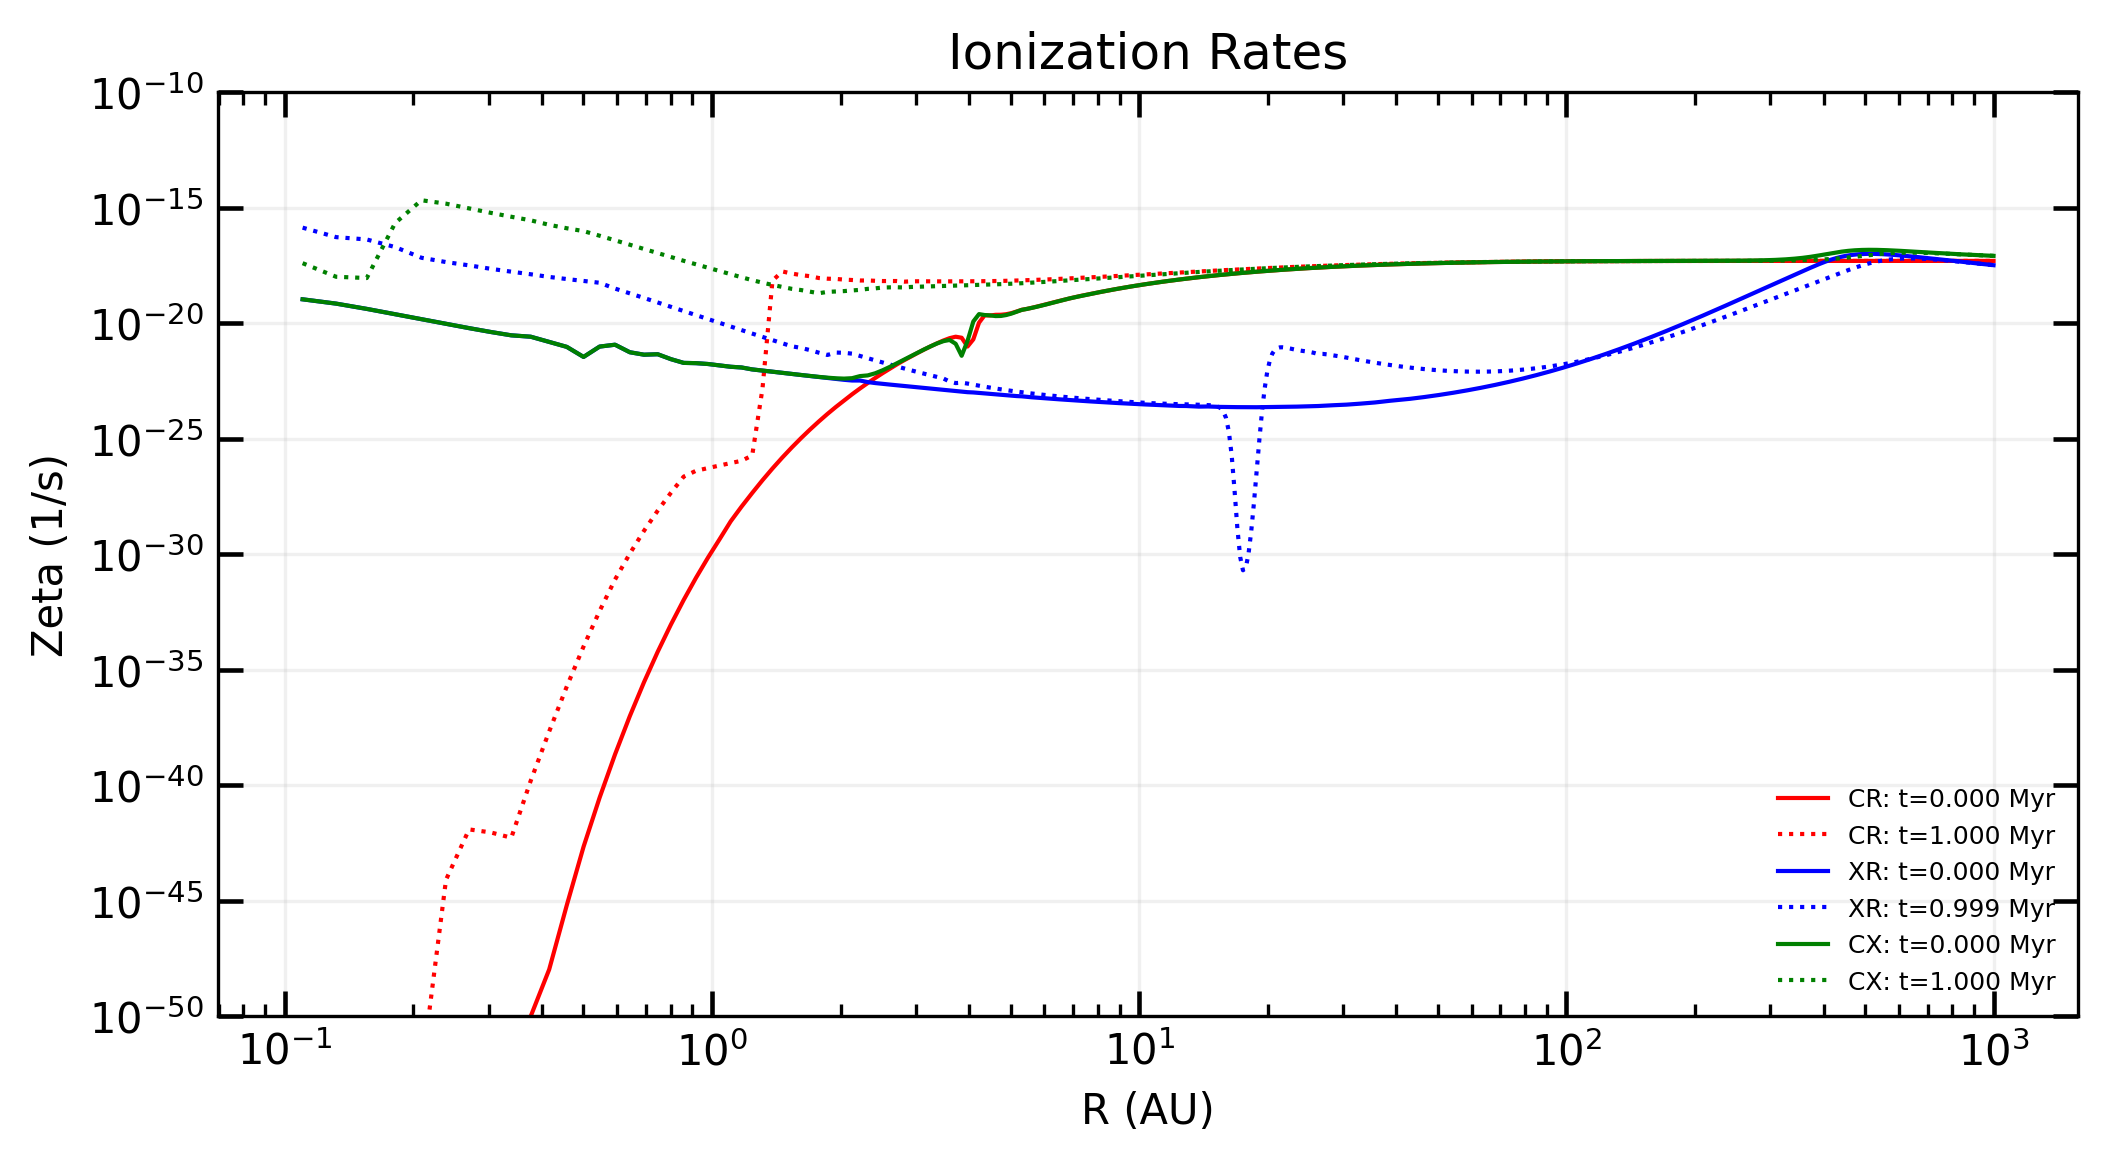

In [6]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('Ionization Rates')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

ax.loglog(crR, crZeta[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crZeta[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrZeta[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrZeta[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

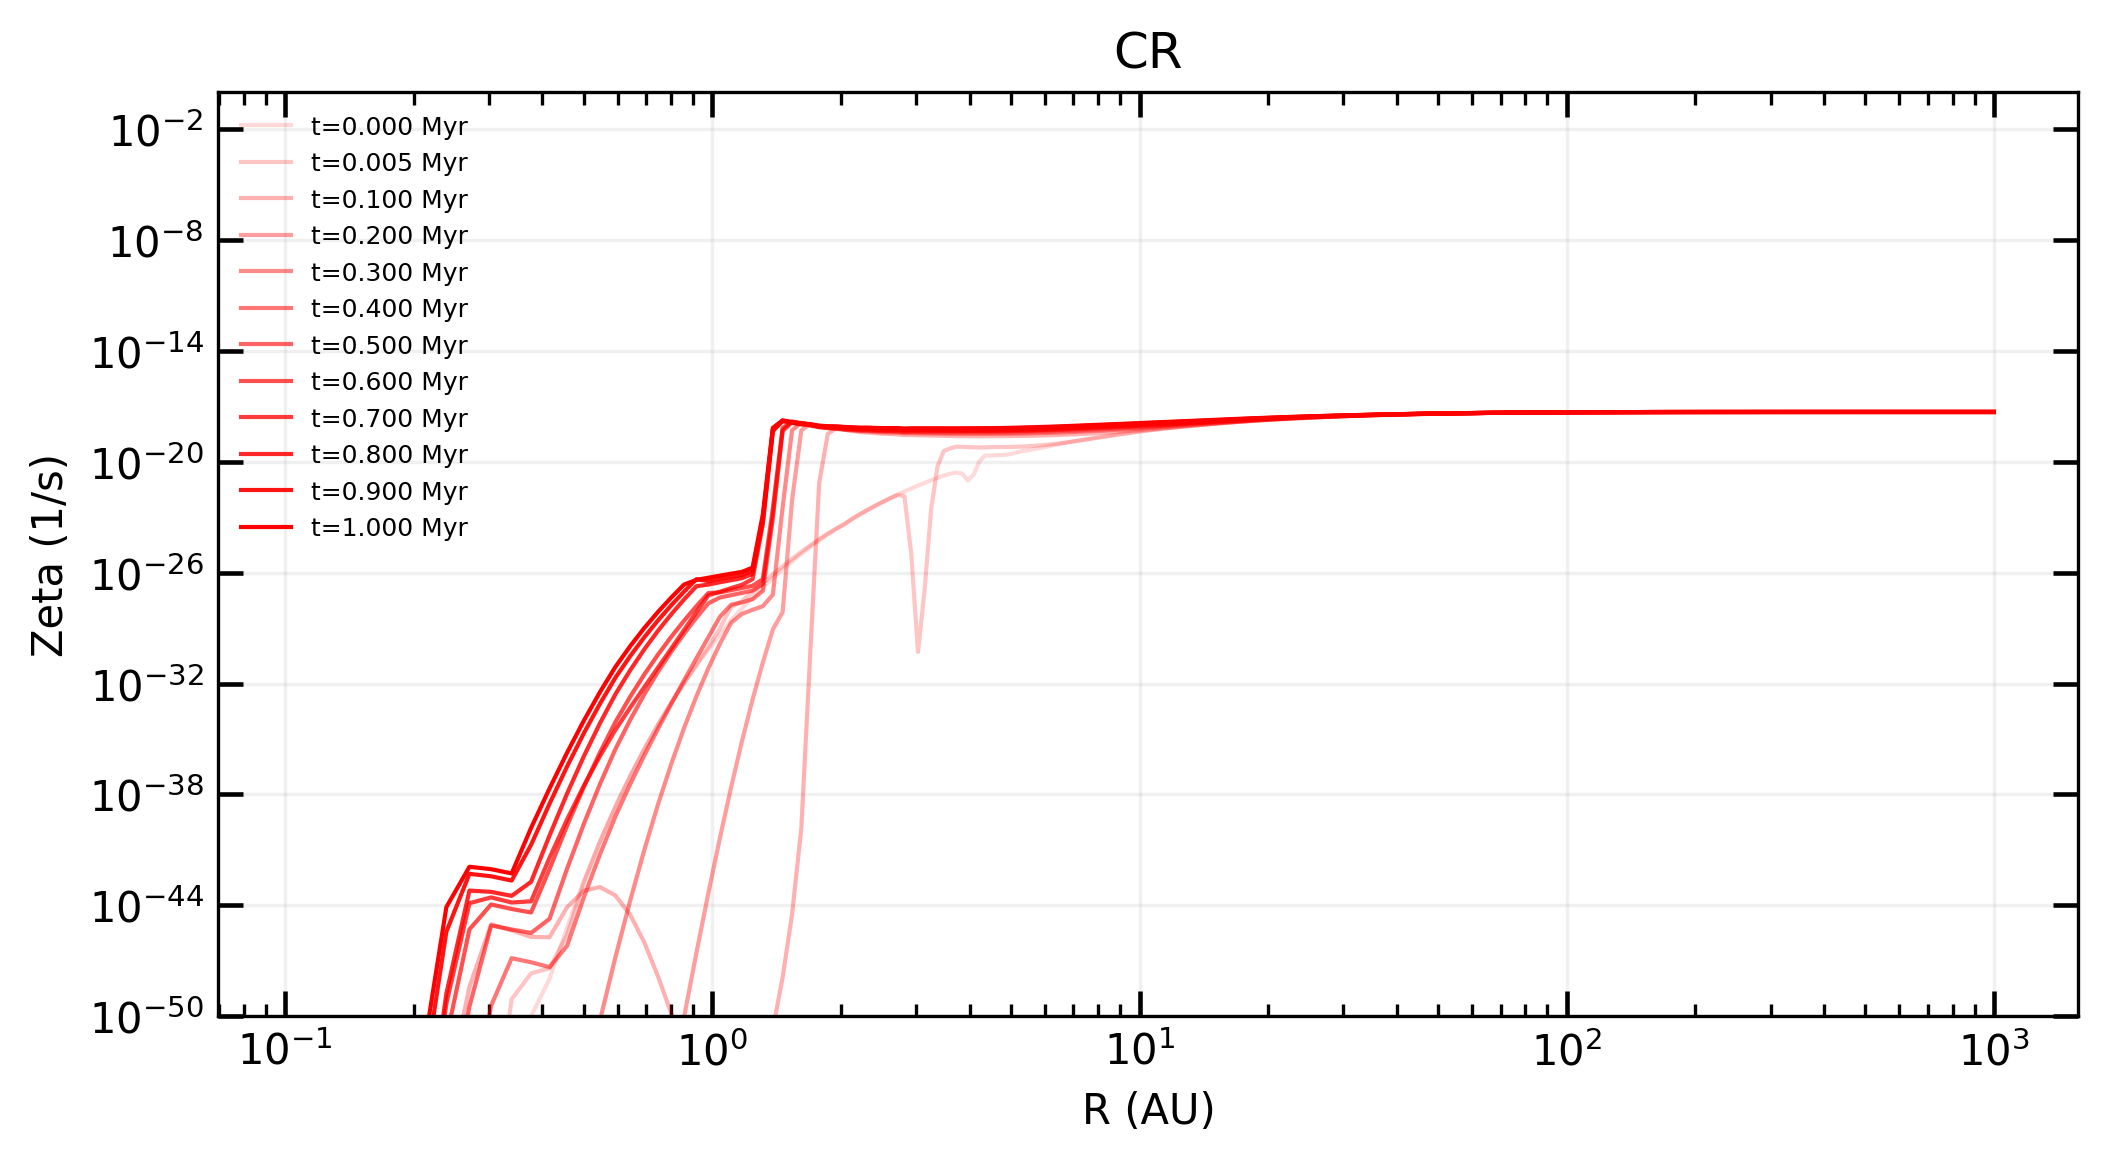

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50)

xdata = crR
ydata = crZeta
for a_i, i in enumerate(cridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

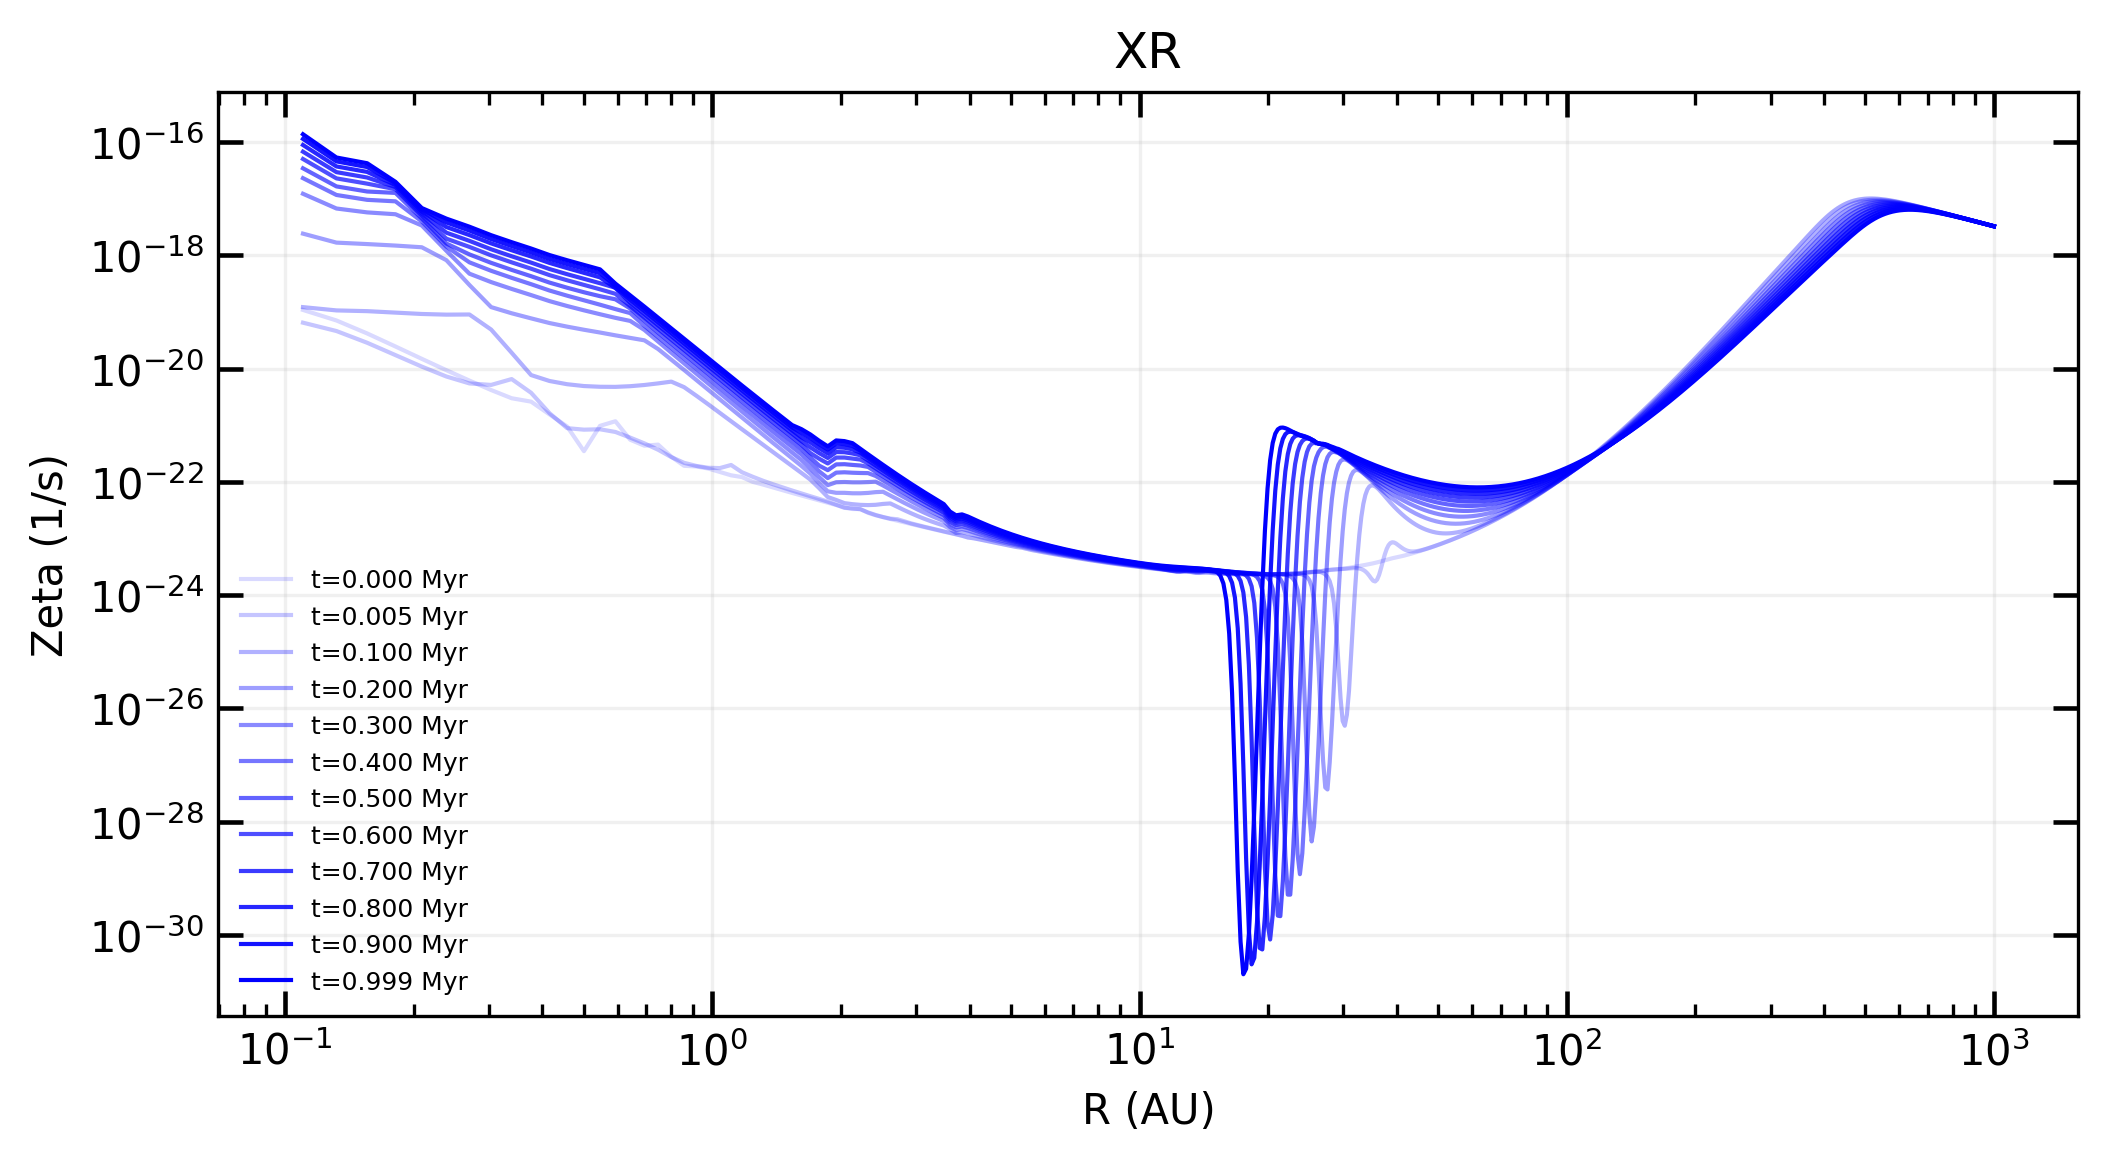

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrZeta
for a_i, i in enumerate(xridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

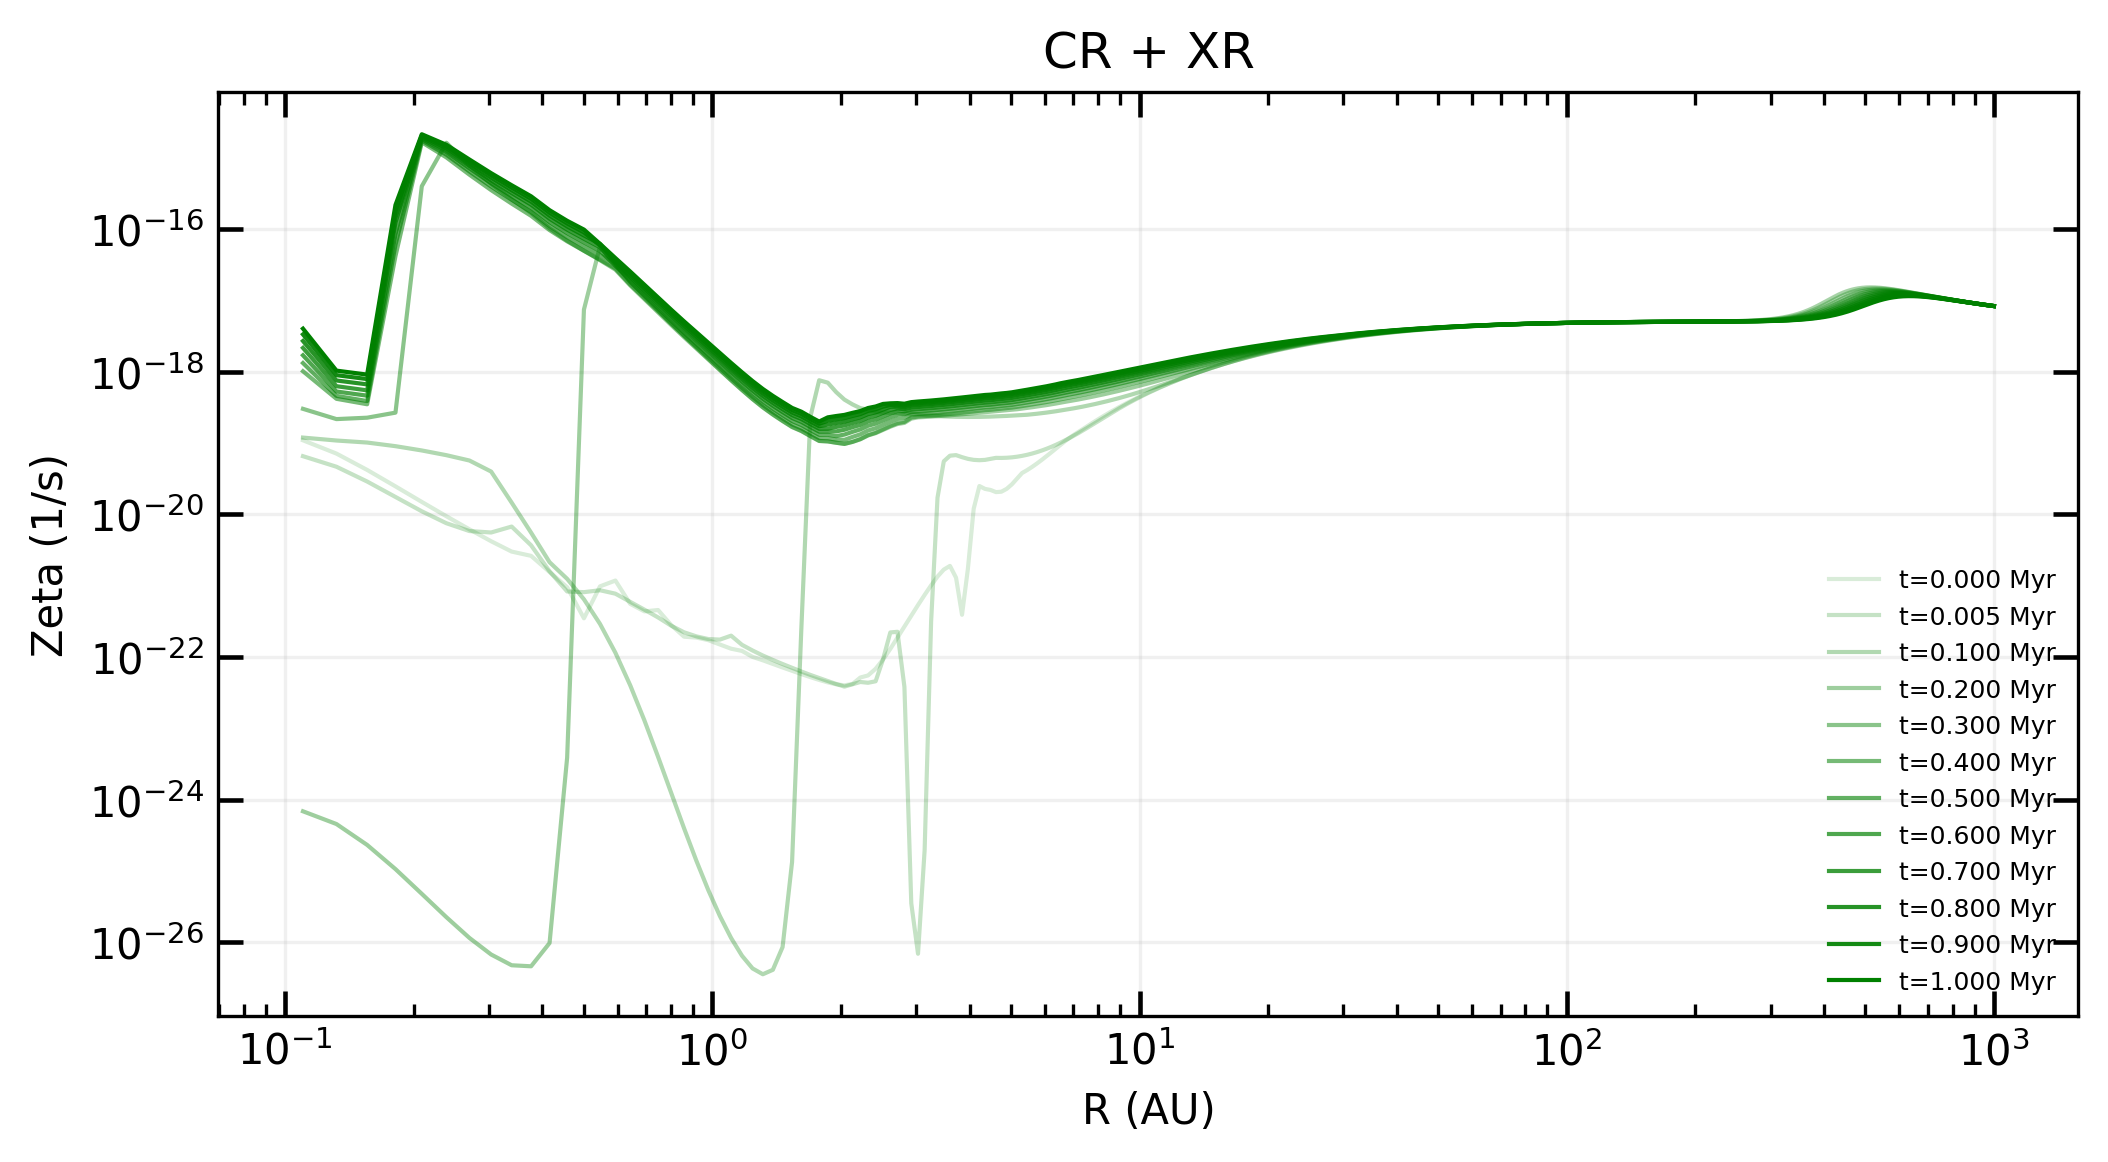

In [9]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxZeta
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

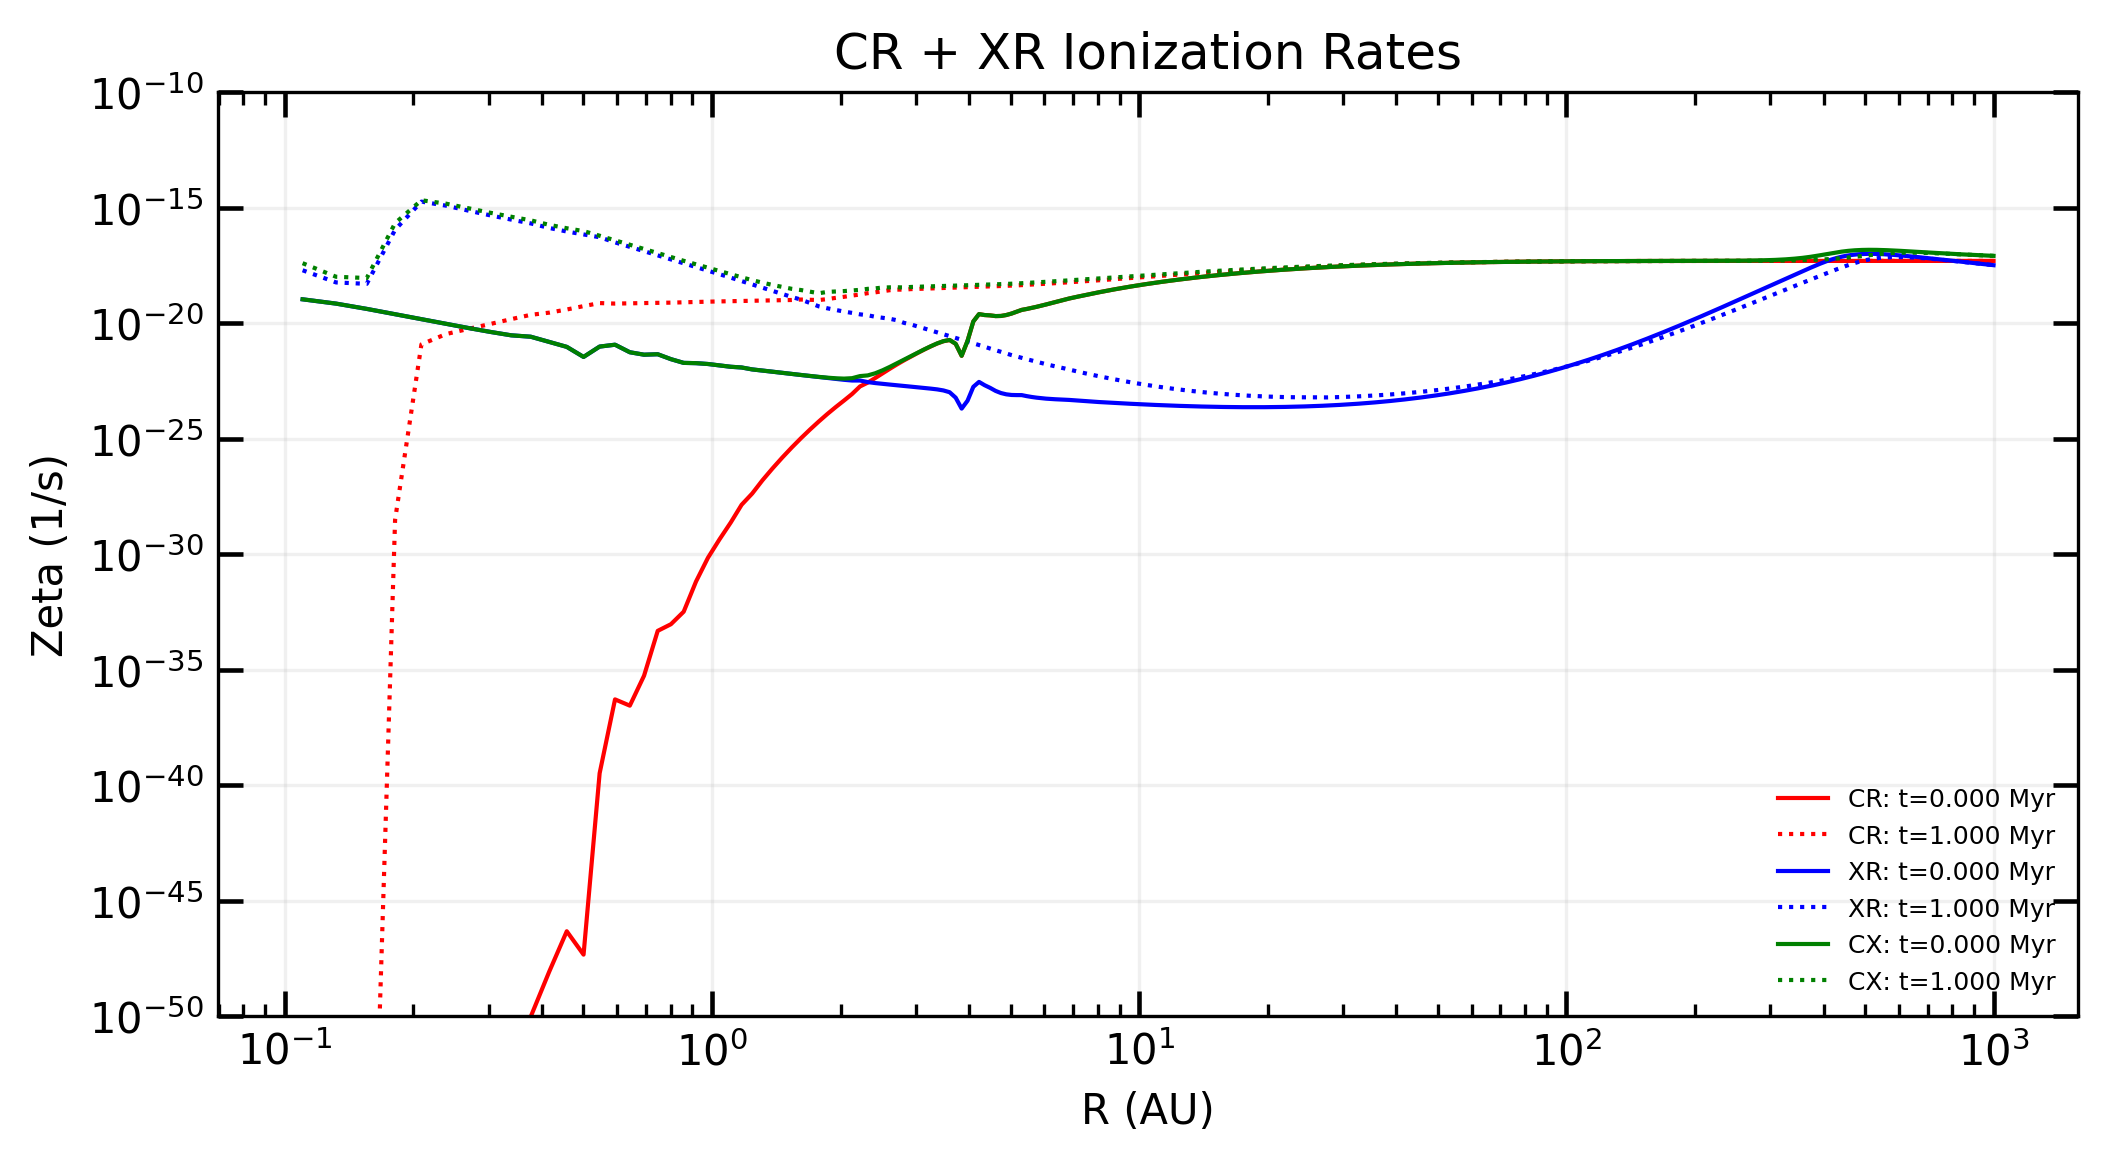

In [10]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR Ionization Rates')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

ax.loglog(cxR, cxZetaCR[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZetaCR[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZetaXR[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZetaXR[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

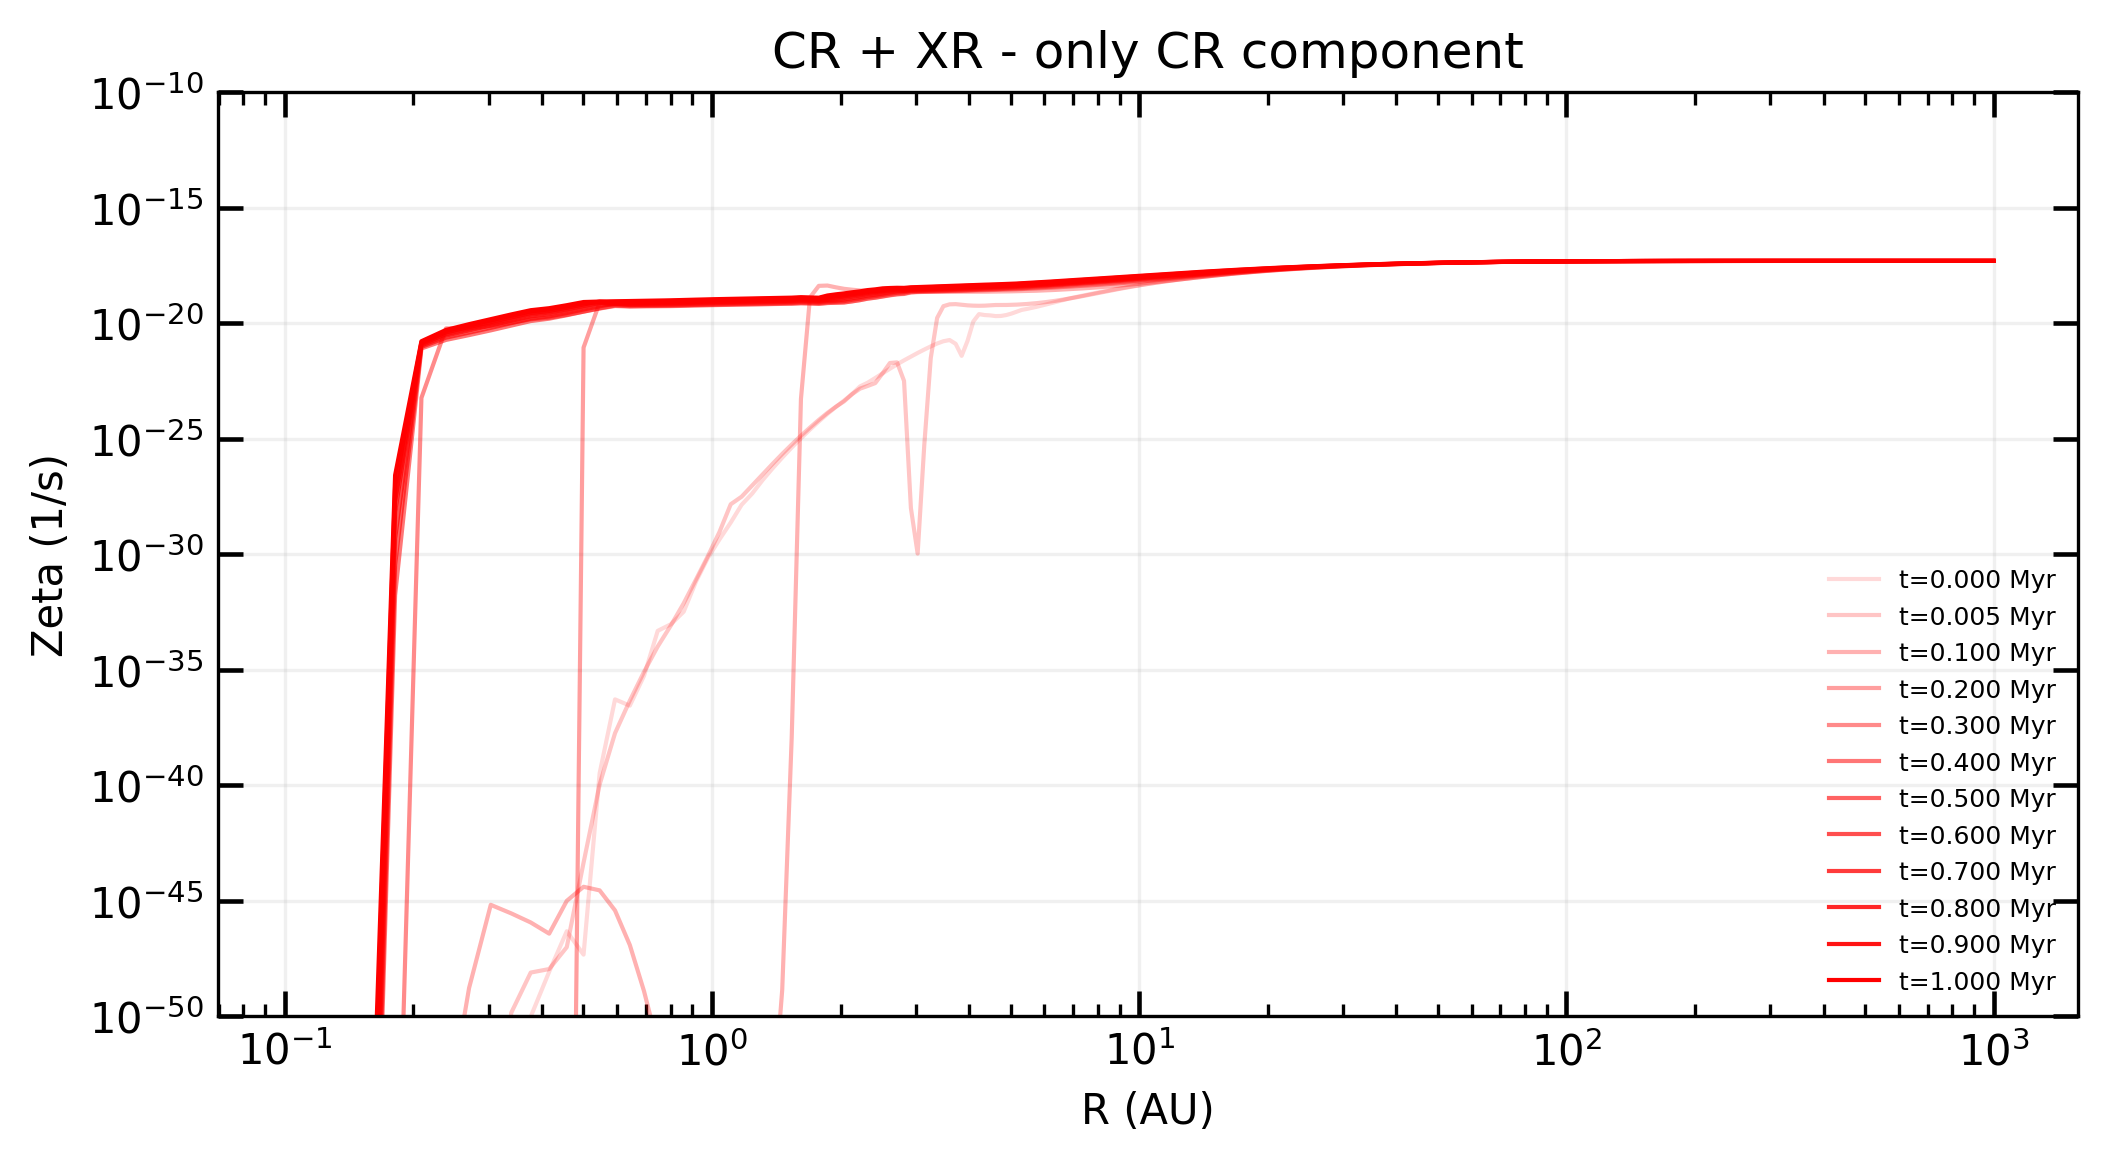

In [11]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR - only CR component')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

xdata = cxR
ydata = cxZetaCR
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

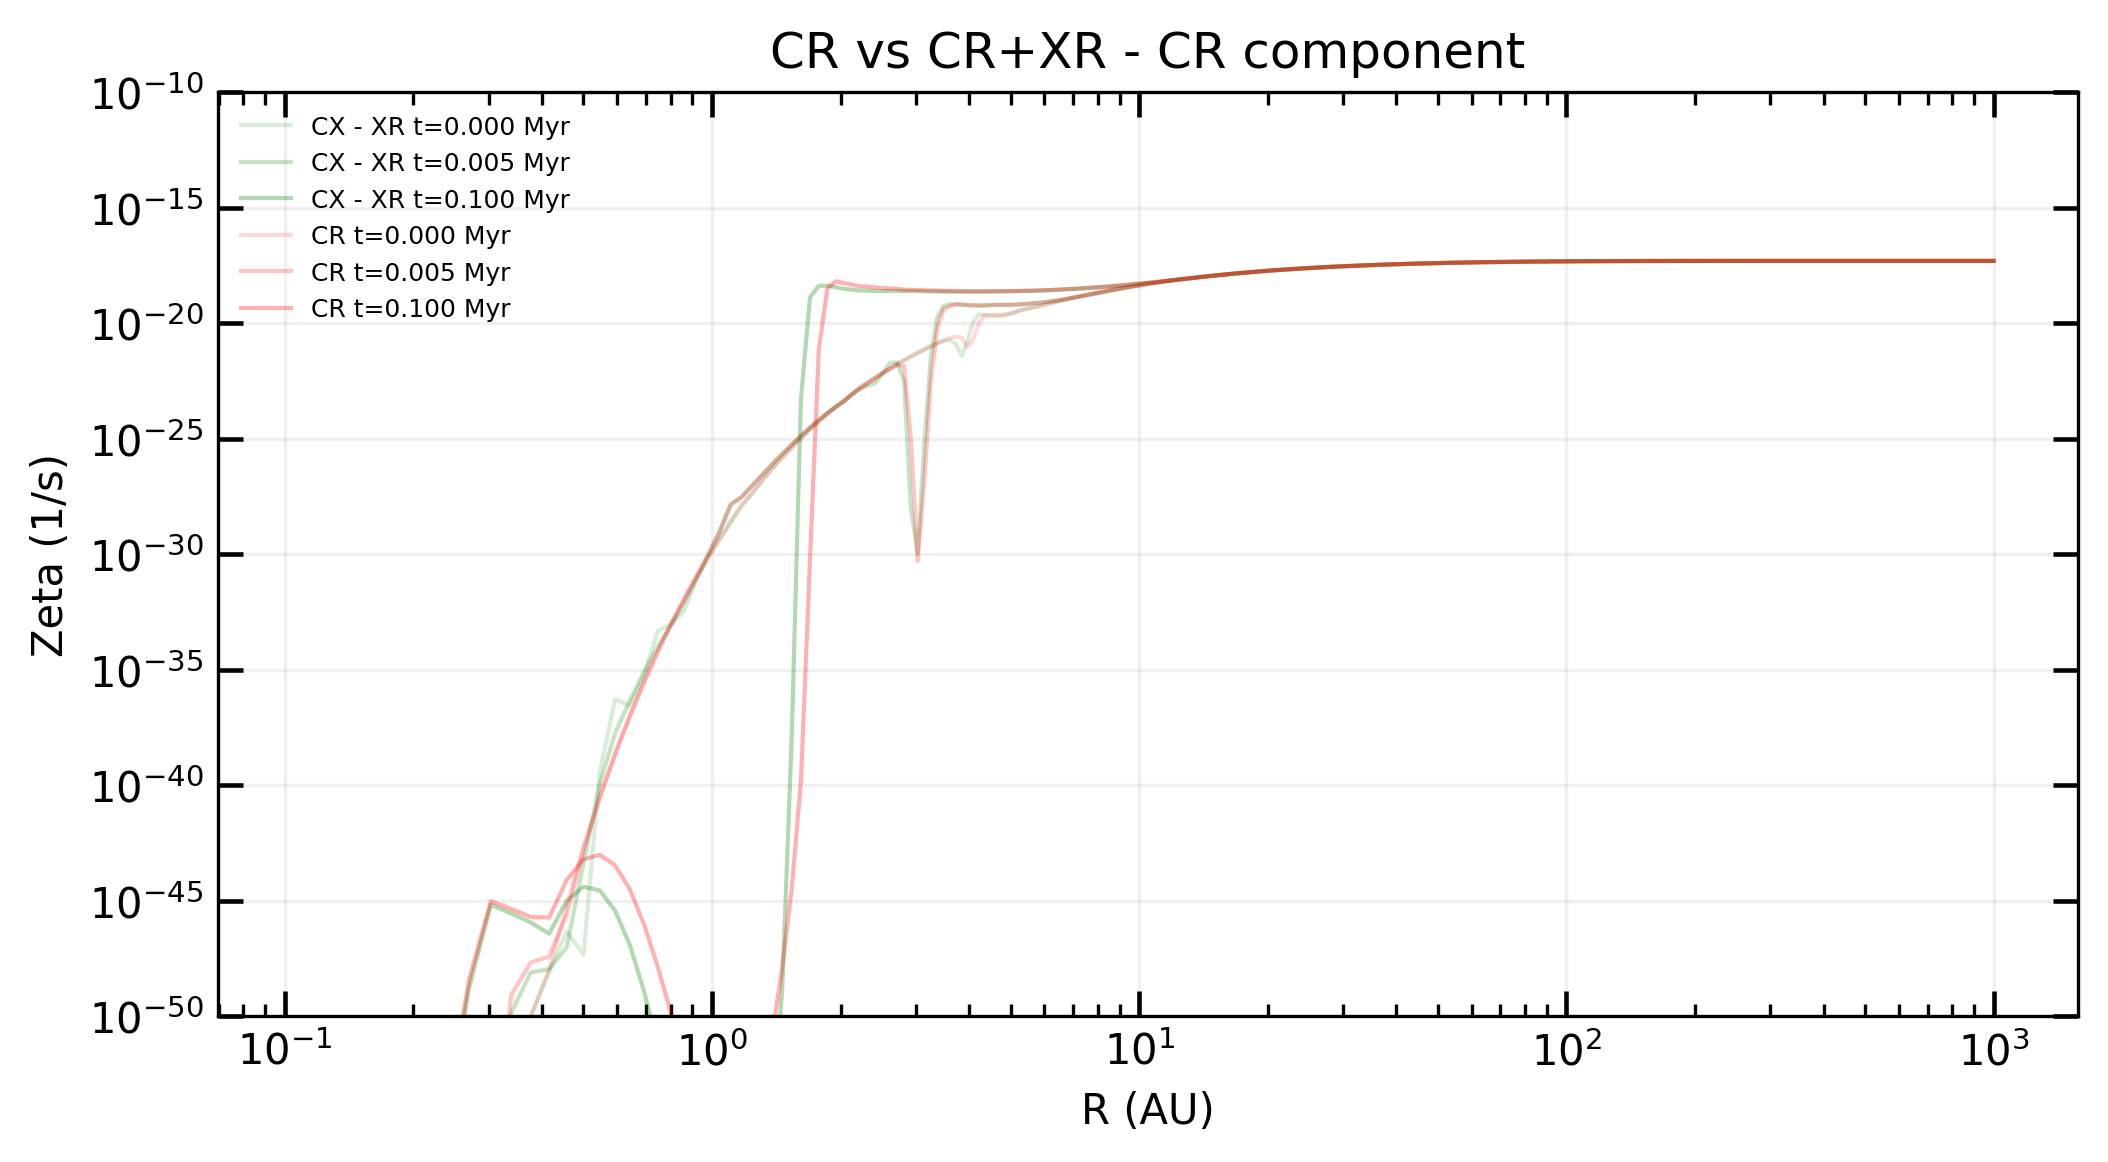

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR vs CR+XR - CR component')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

xdata = cxR
ydata = cxZetaCR
for a_i, i in enumerate(cxidx[:3]):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"CX - XR t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

xdata = crR
ydata = crZeta
for a_i, i in enumerate(cridx[:3]):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"CR t={crt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

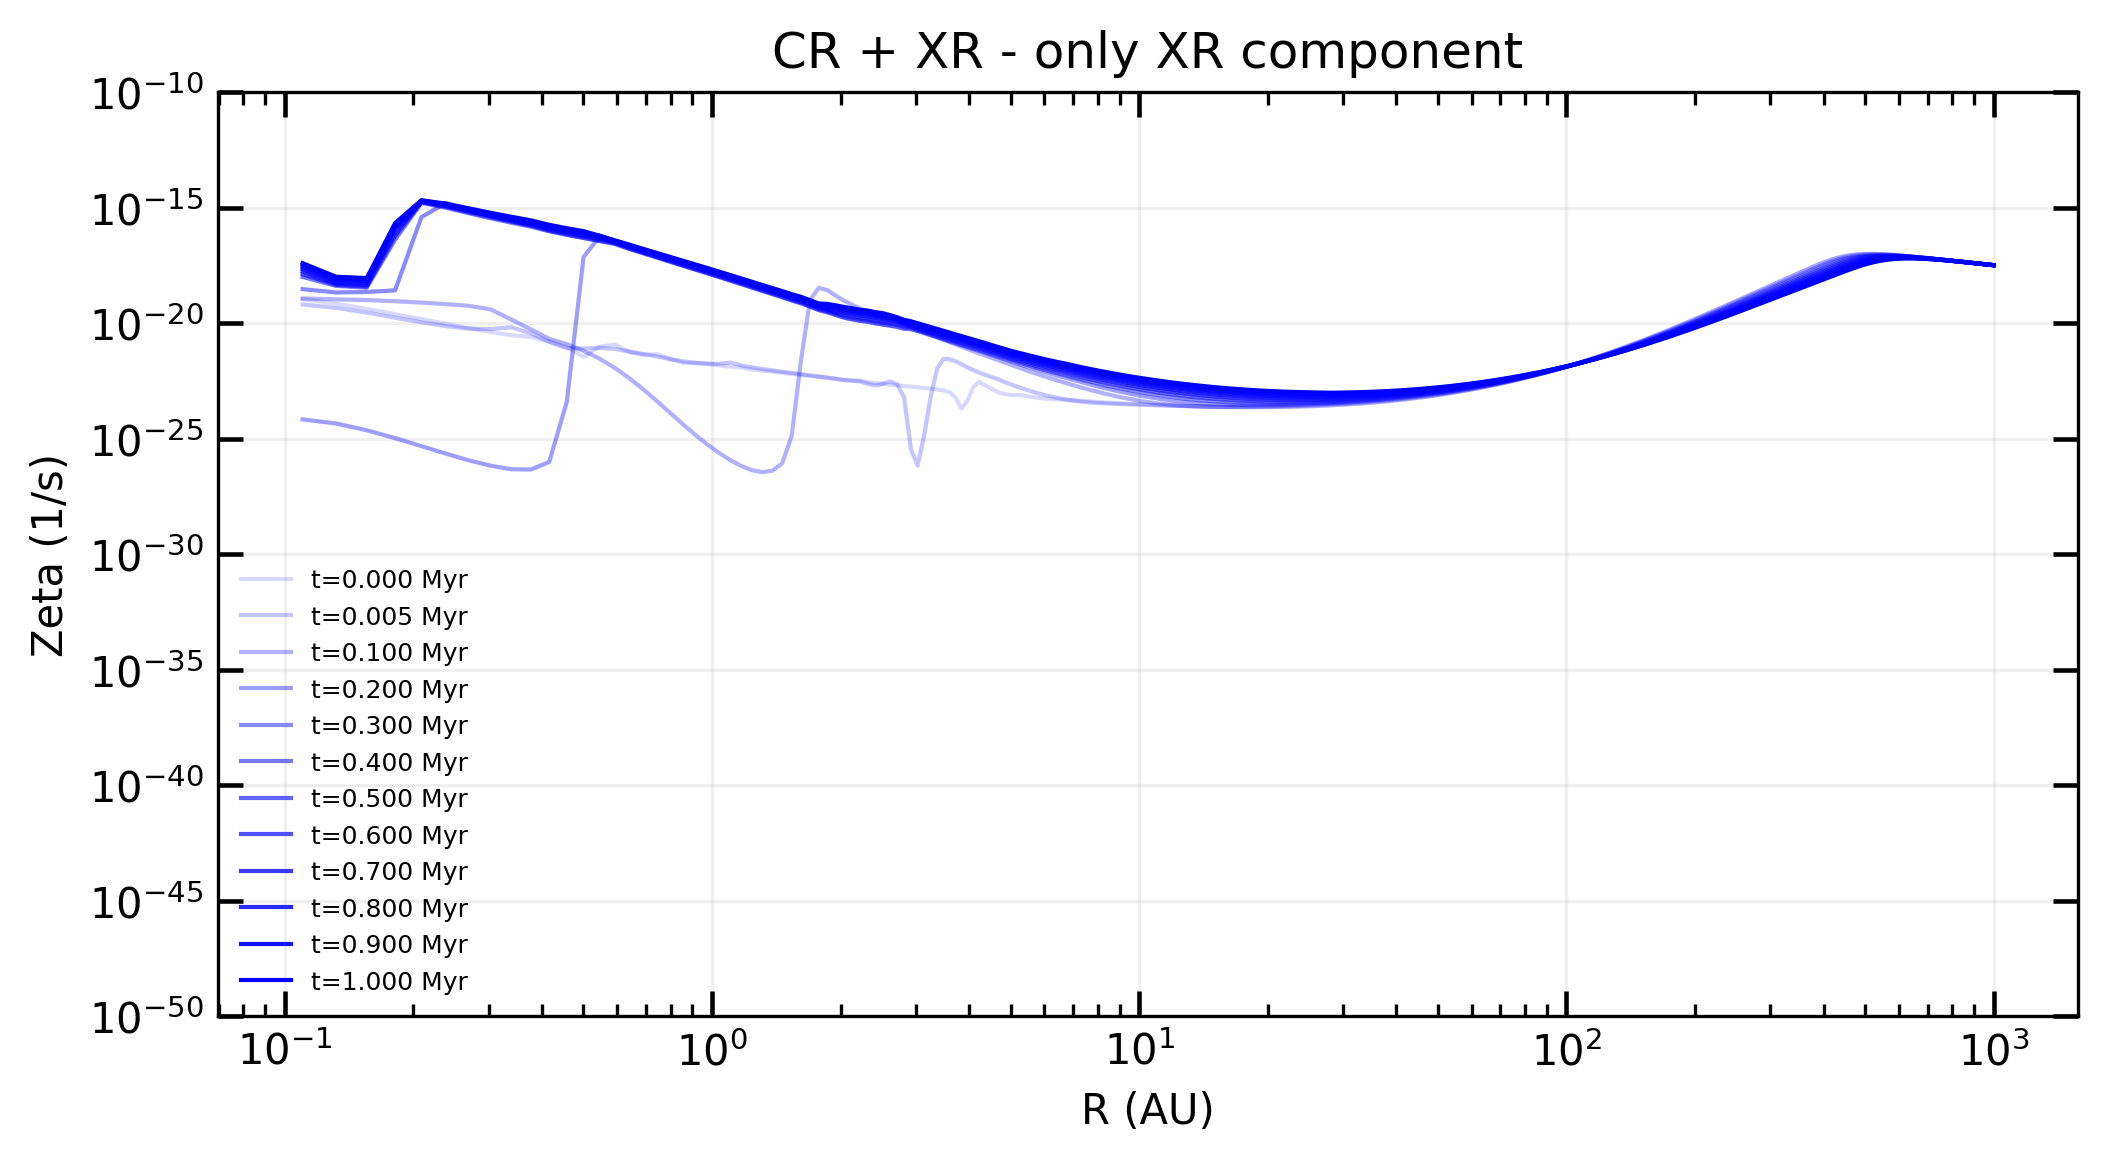

In [13]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR - only XR component')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

xdata = cxR
ydata = cxZetaXR
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

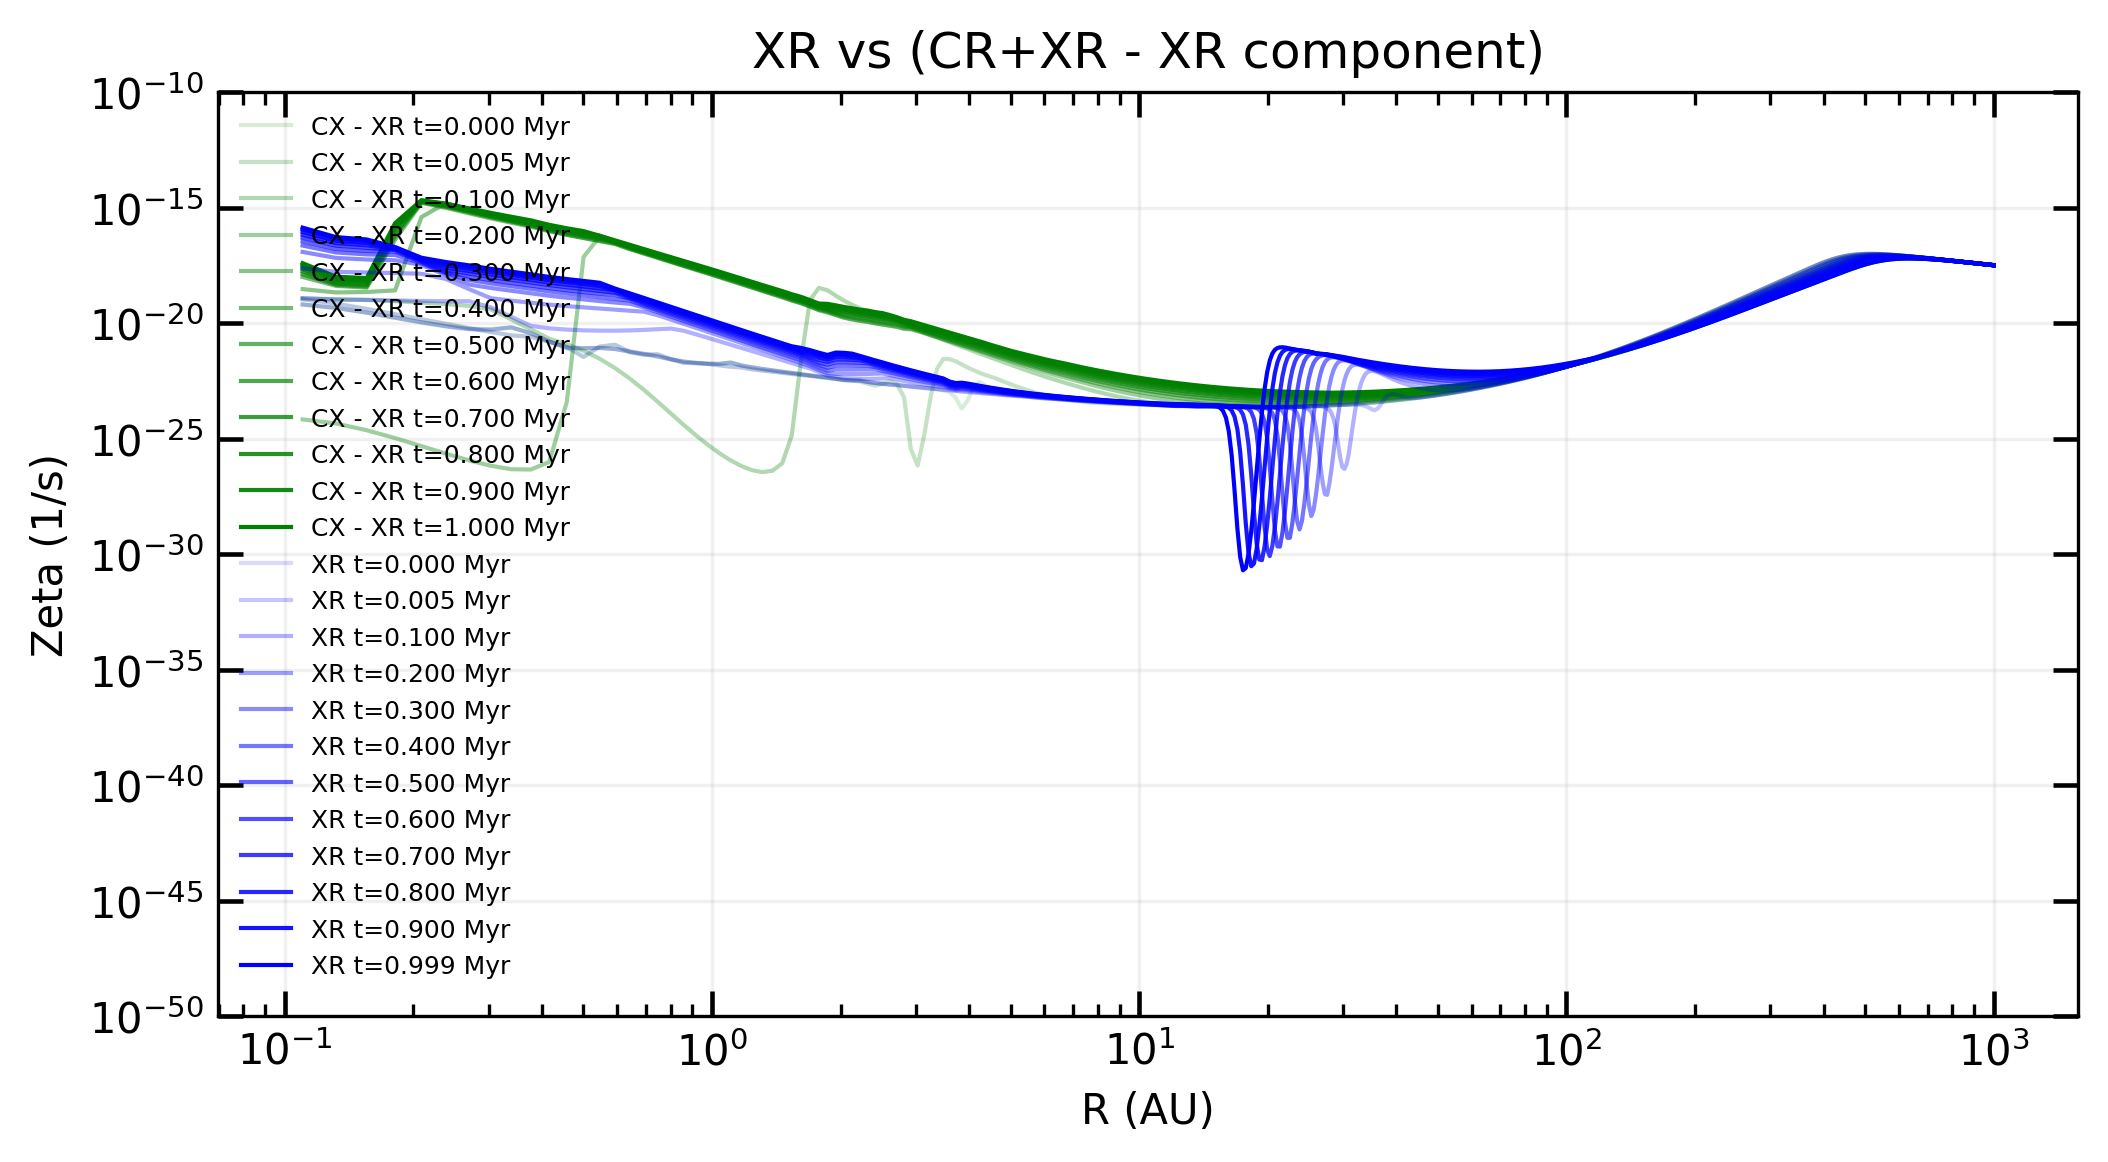

In [14]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('XR vs (CR+XR - XR component)')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

xdata = cxR
ydata = cxZetaXR
for a_i, i in enumerate(cxidx[:]):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"CX - XR t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

xdata = xrR
ydata = xrZeta
for a_i, i in enumerate(xridx[:]):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"XR t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Deadzone Radius

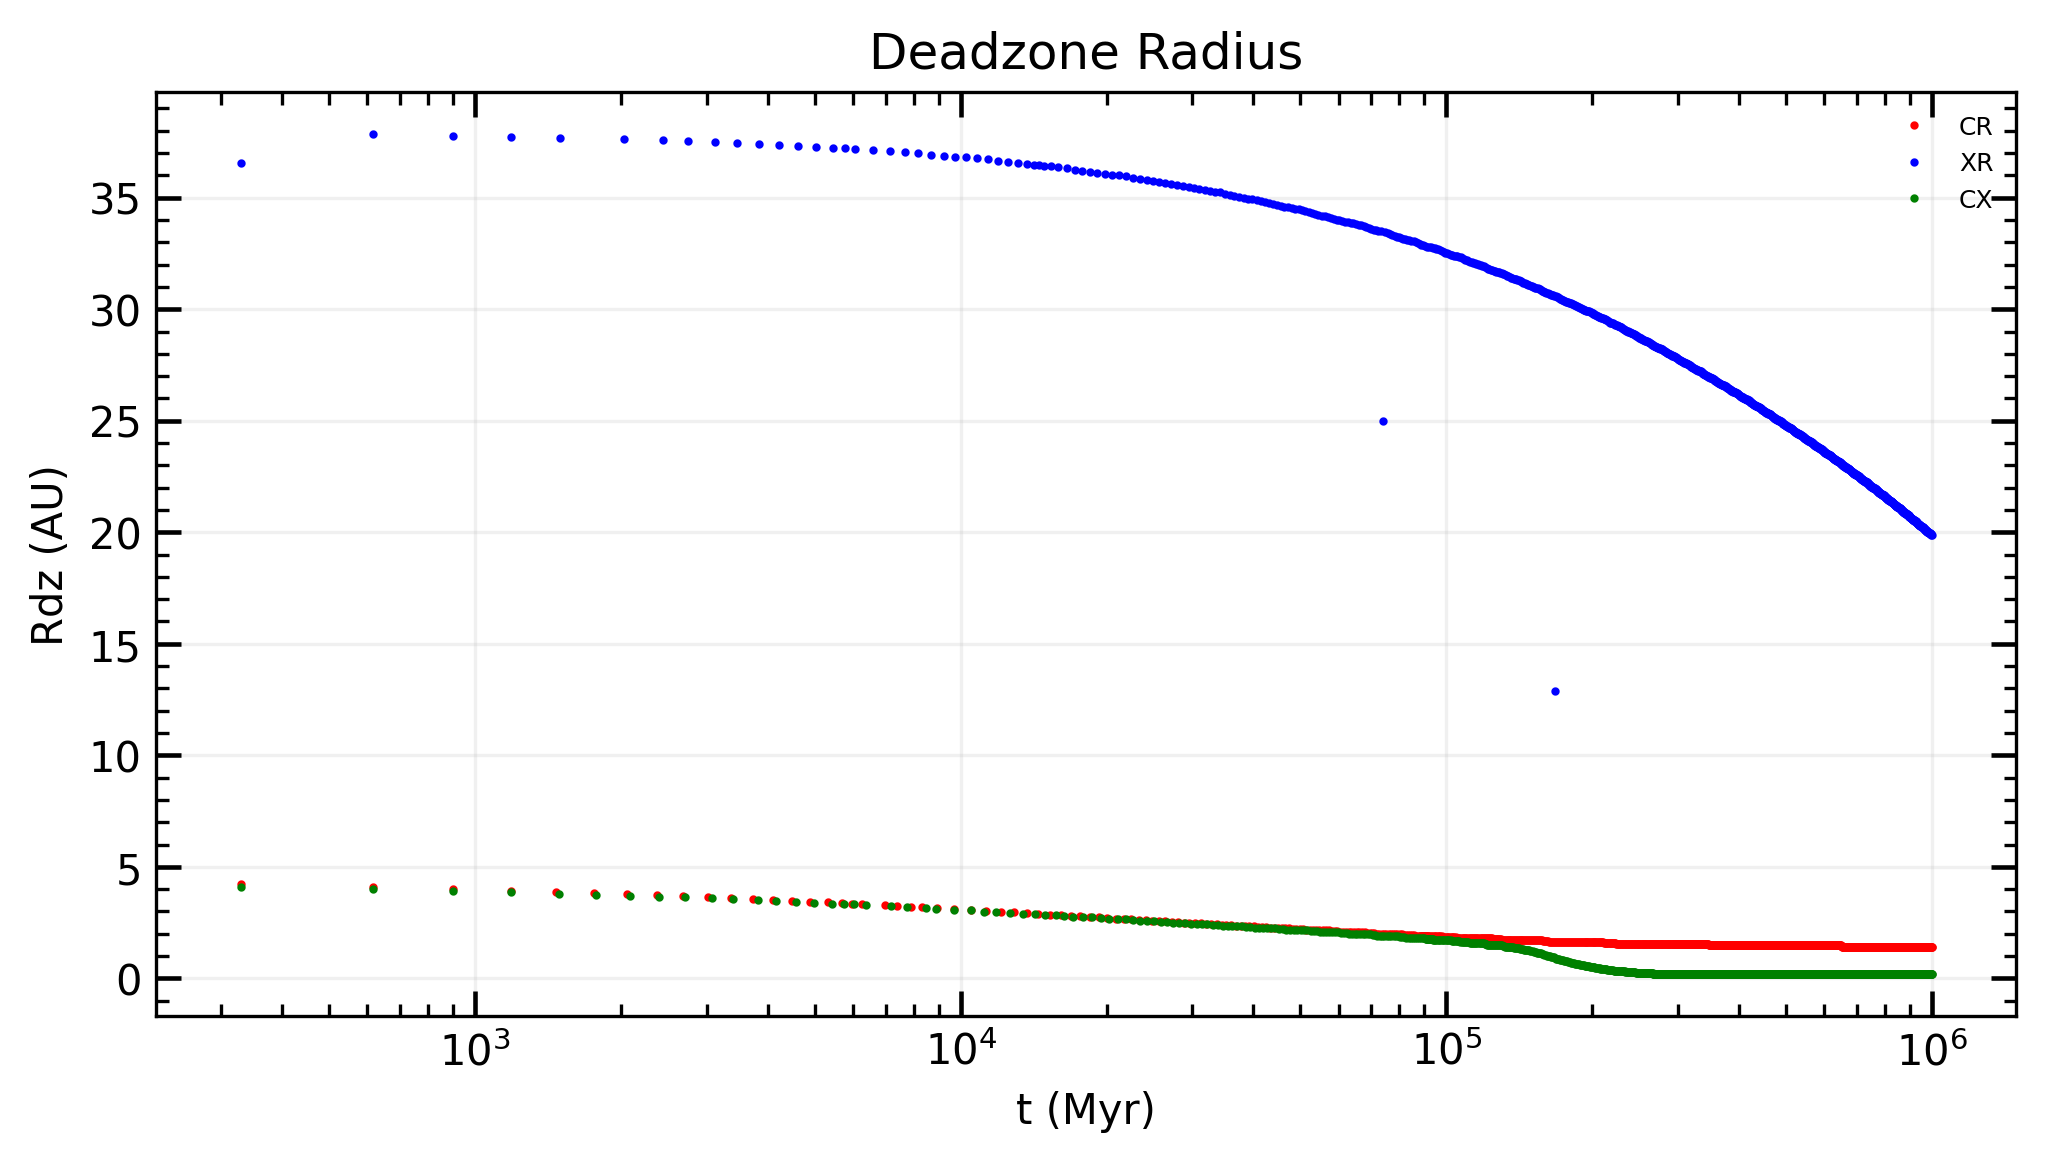

In [15]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('Deadzone Radius')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(crt, crRdz, '.r', label=rf"CR", ms = 2.0)
ax.semilogx(xrt, xrRdz, '.b', label=rf"XR", ms = 2.0)
ax.semilogx(cxt, cxRdz, '.g', label=rf"CX", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

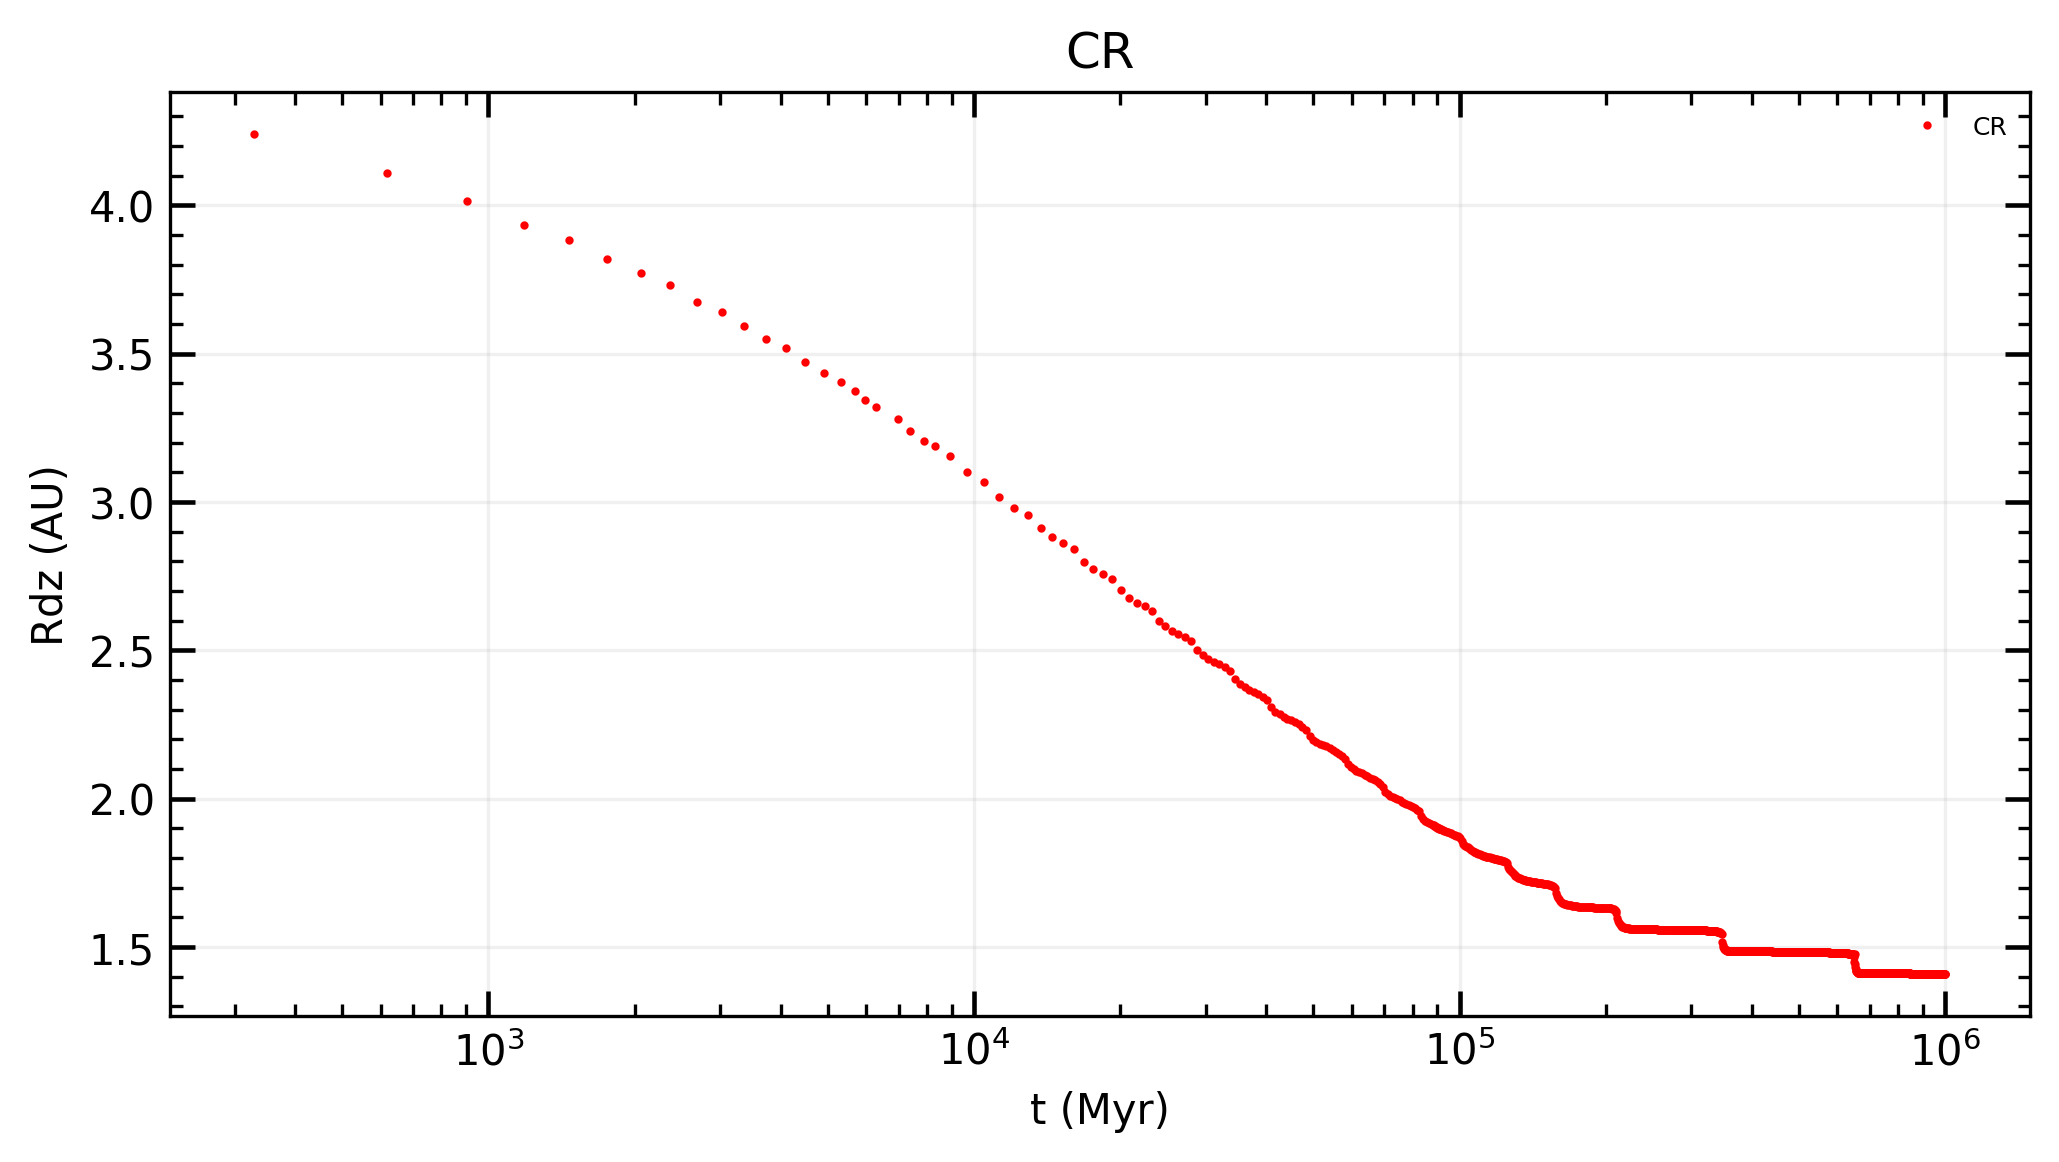

In [16]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('CR')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(crt, crRdz, '.r', label=rf"CR", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

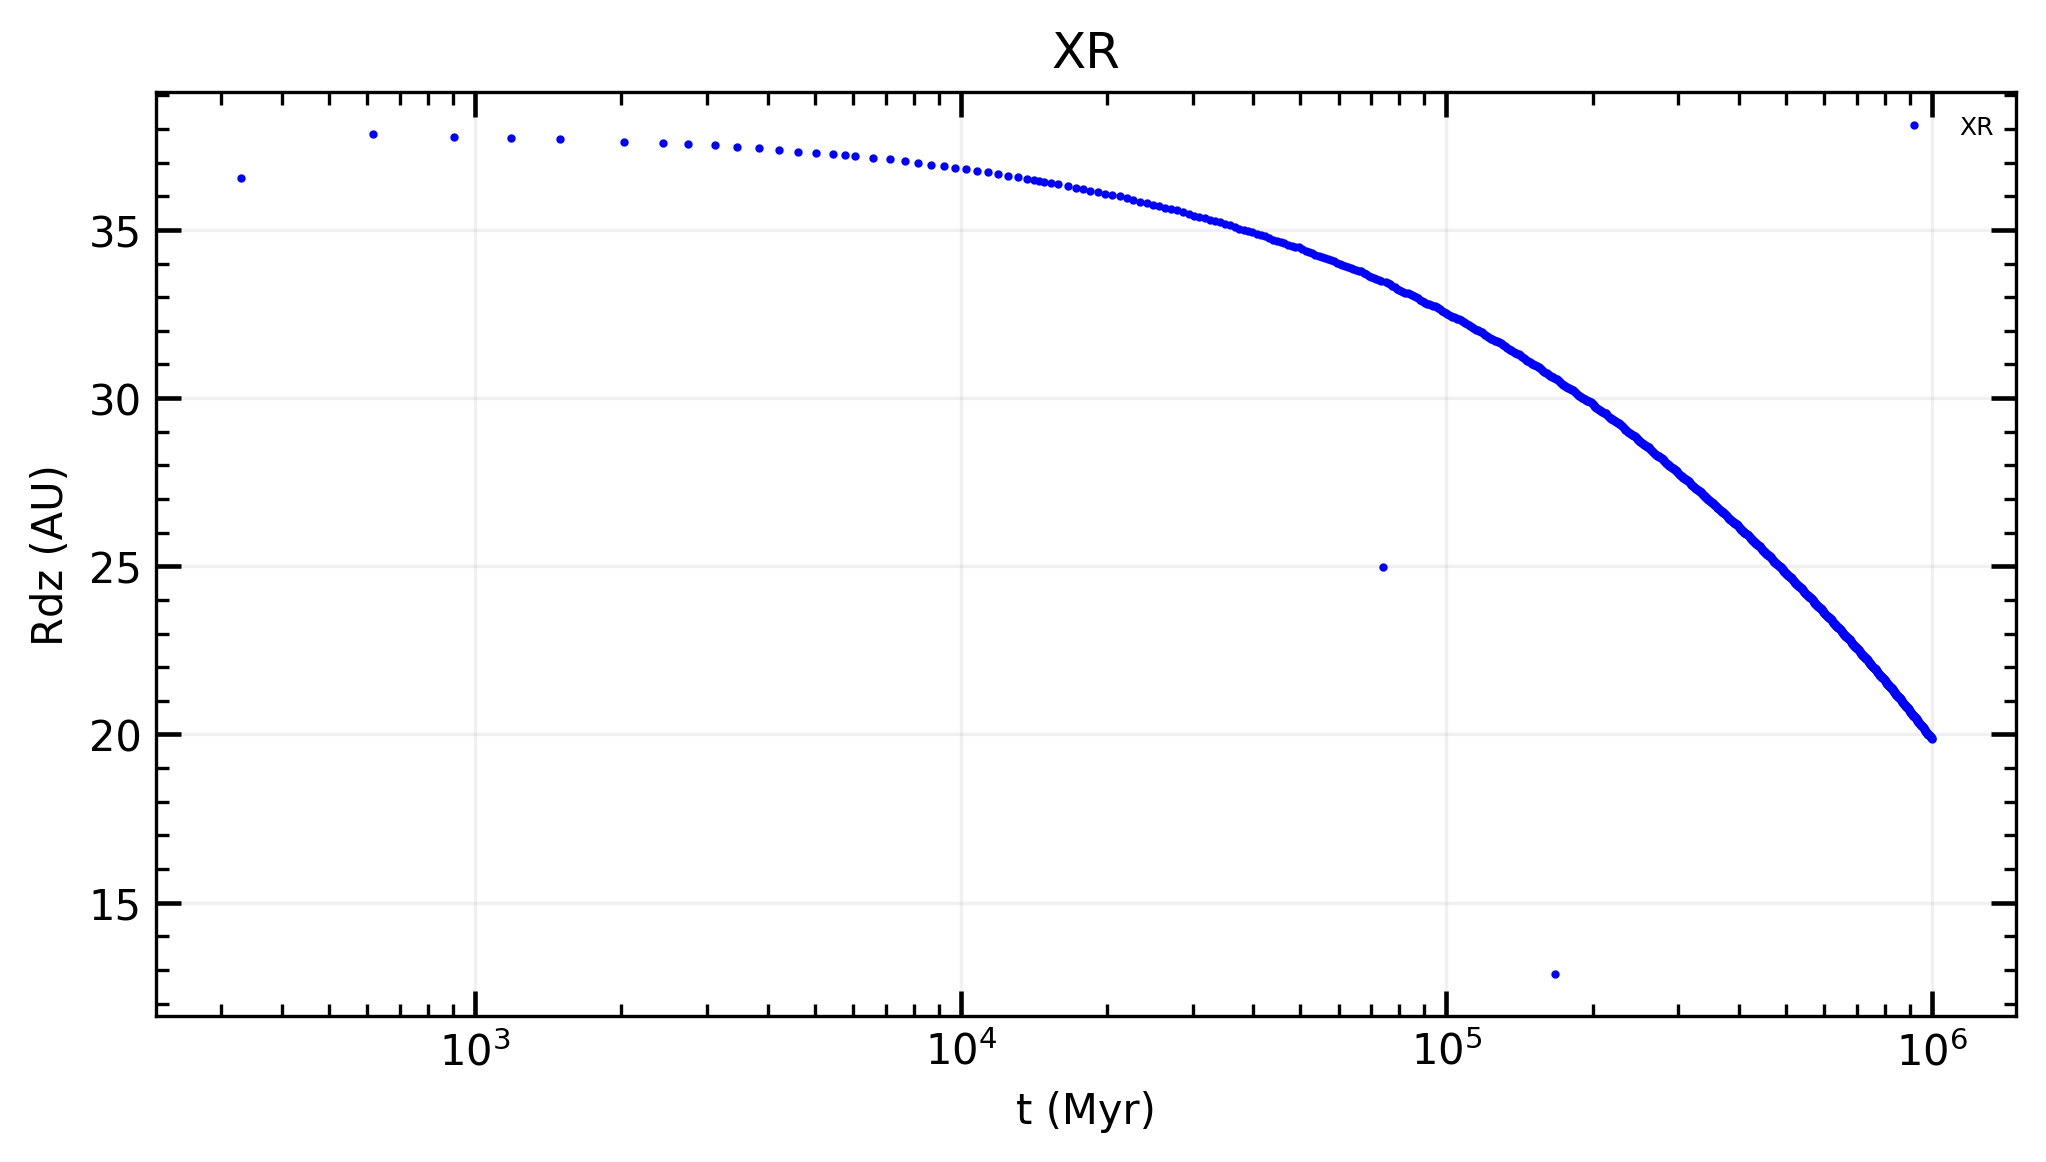

In [17]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('XR')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(xrt, xrRdz, '.b', label=rf"XR", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

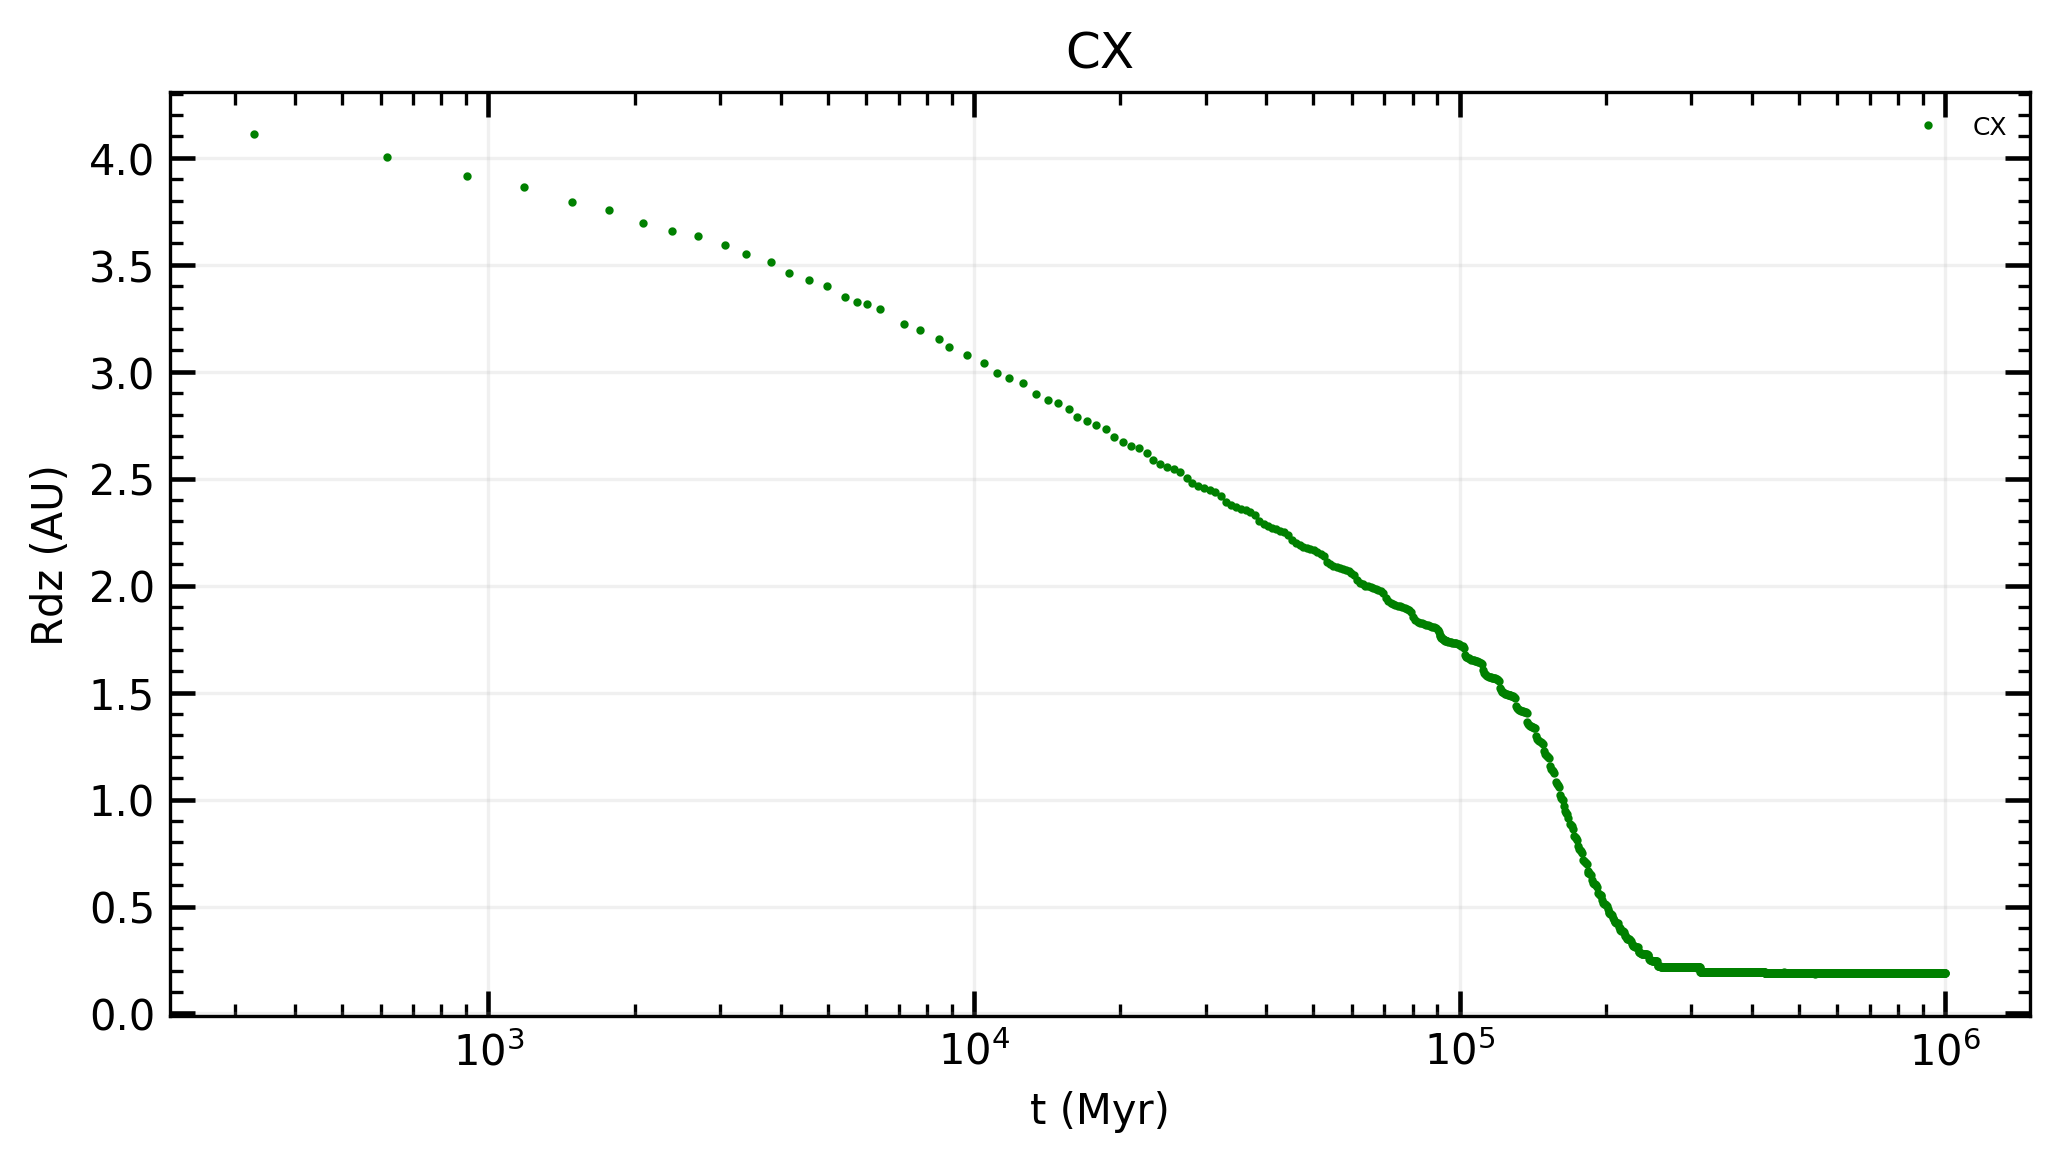

In [18]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('CX')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(cxt, cxRdz, '.g', label=rf"CX", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# xe electron fraction

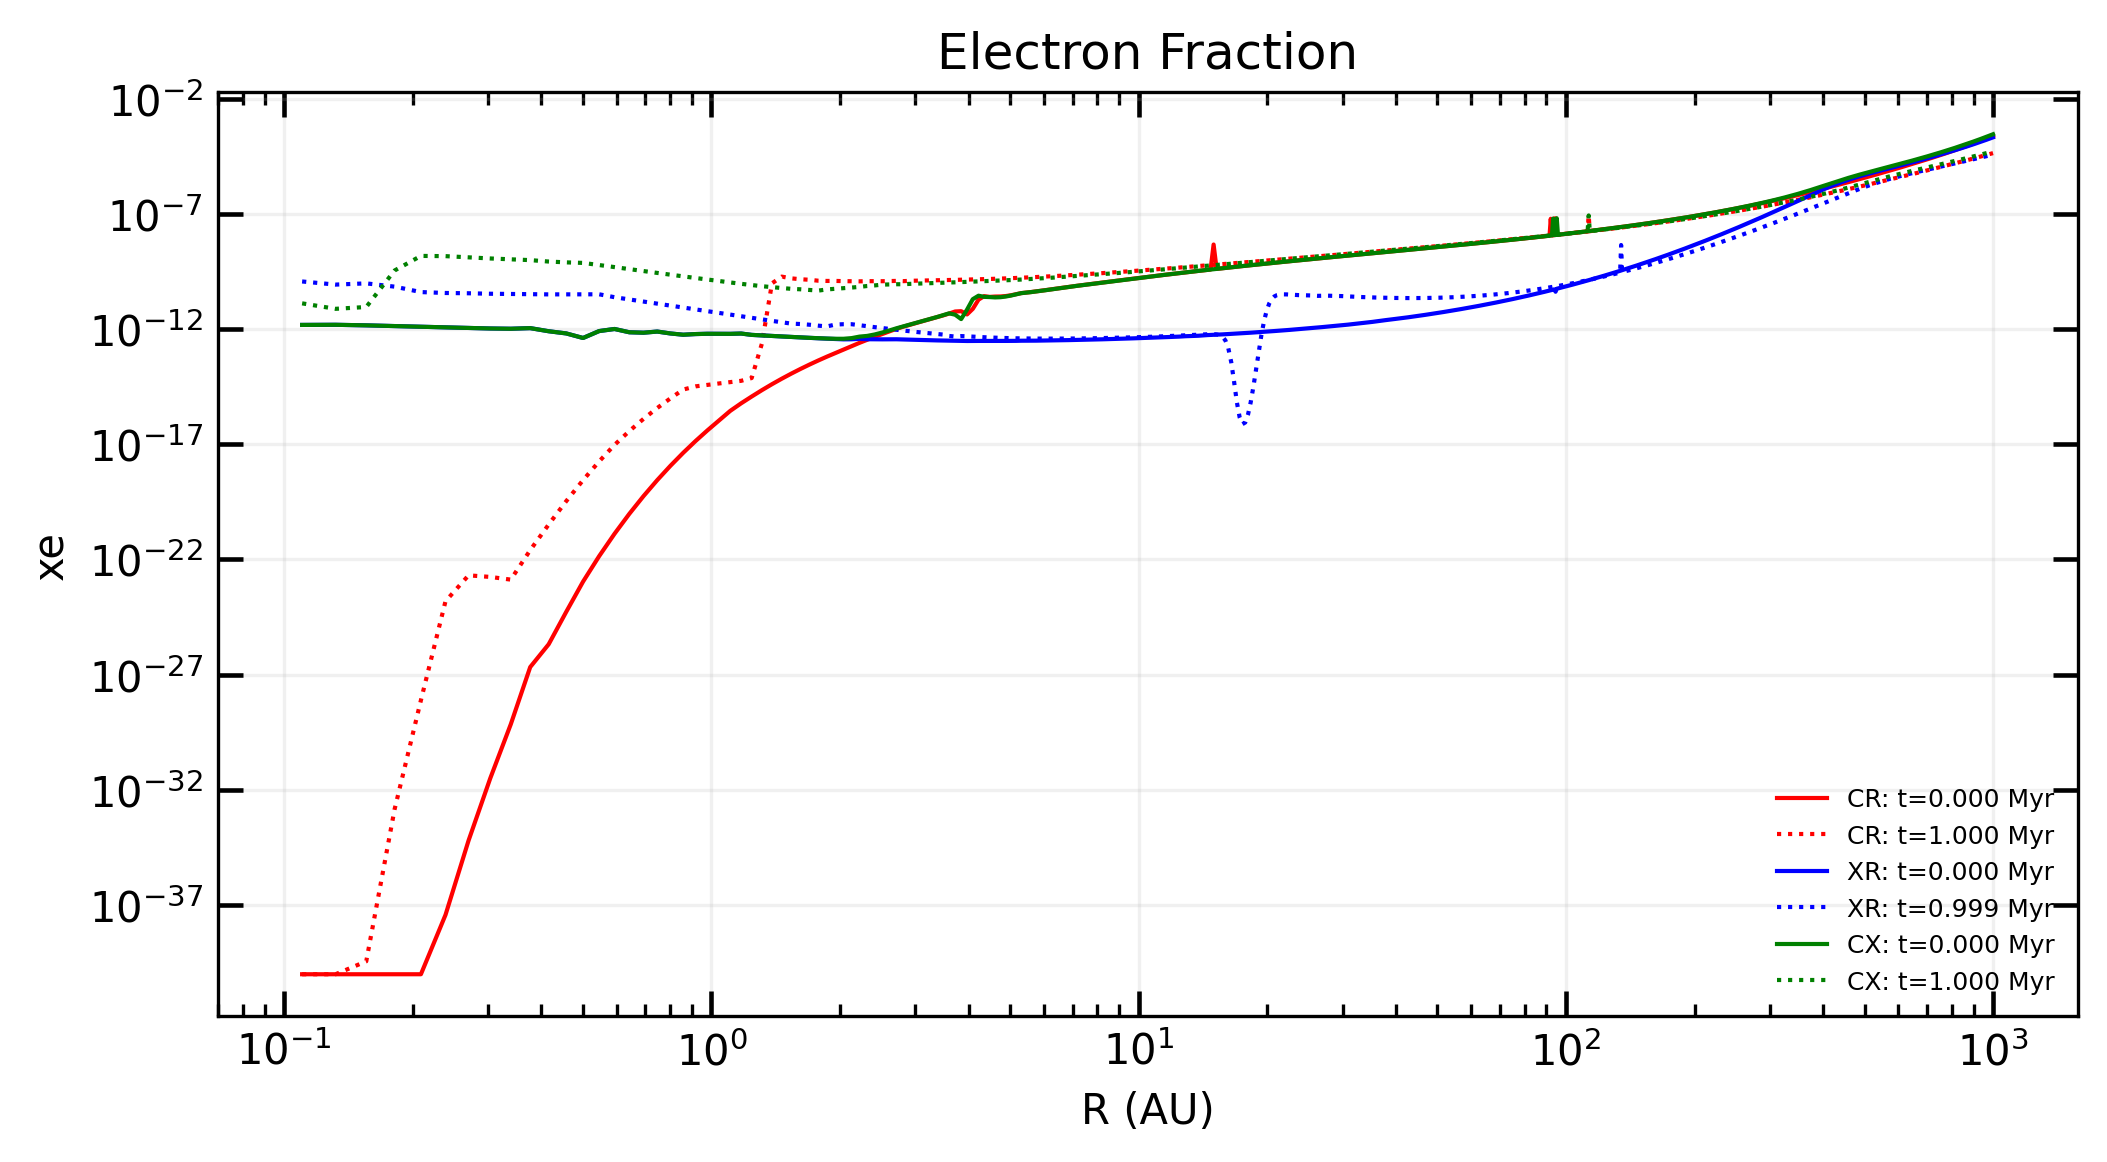

In [19]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('Electron Fraction')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crxe[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crxe[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrxe[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrxe[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxxe[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxxe[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

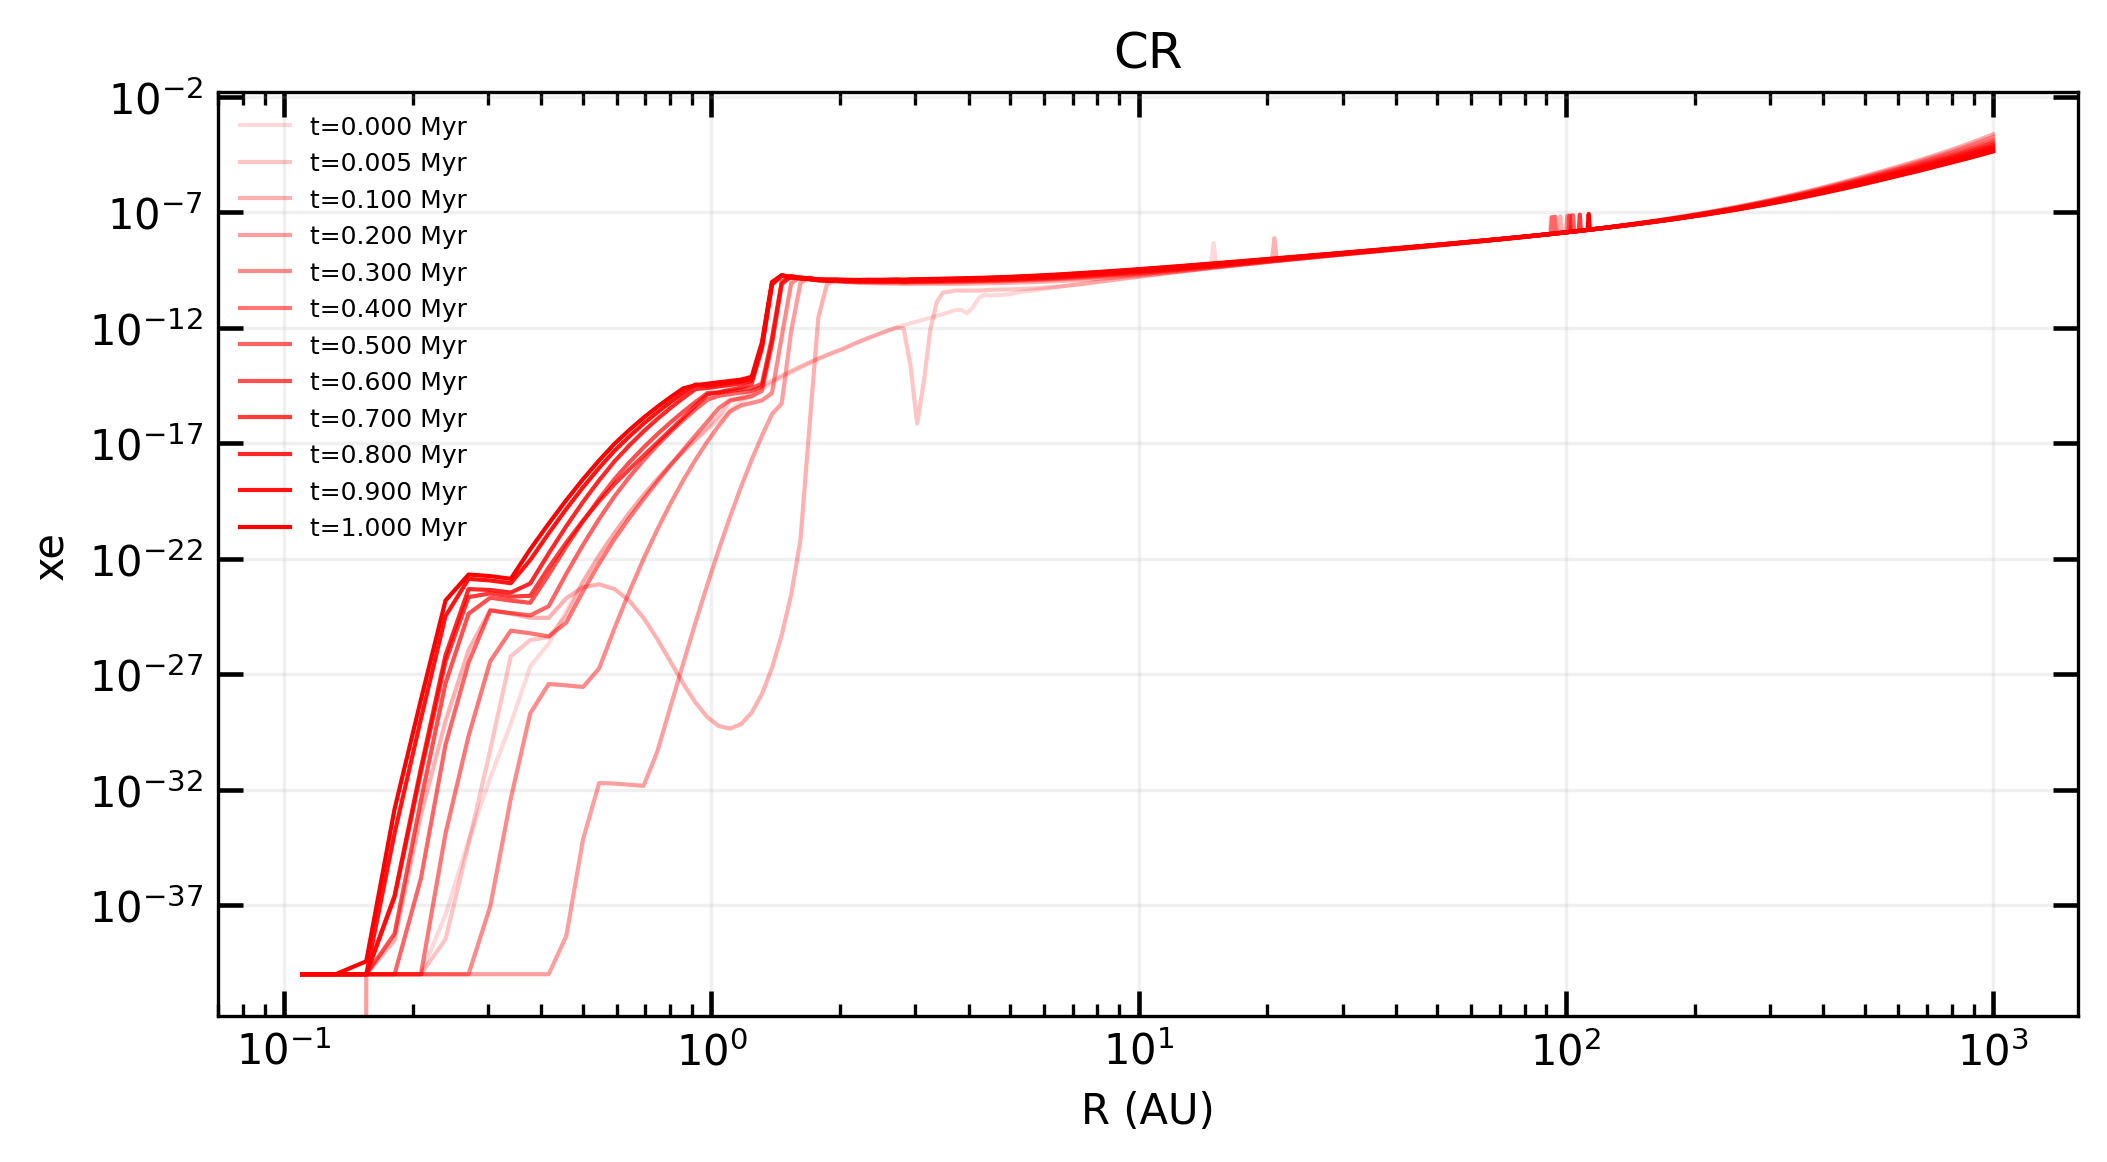

In [20]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('CR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crxe
for a_i, i in enumerate(cridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

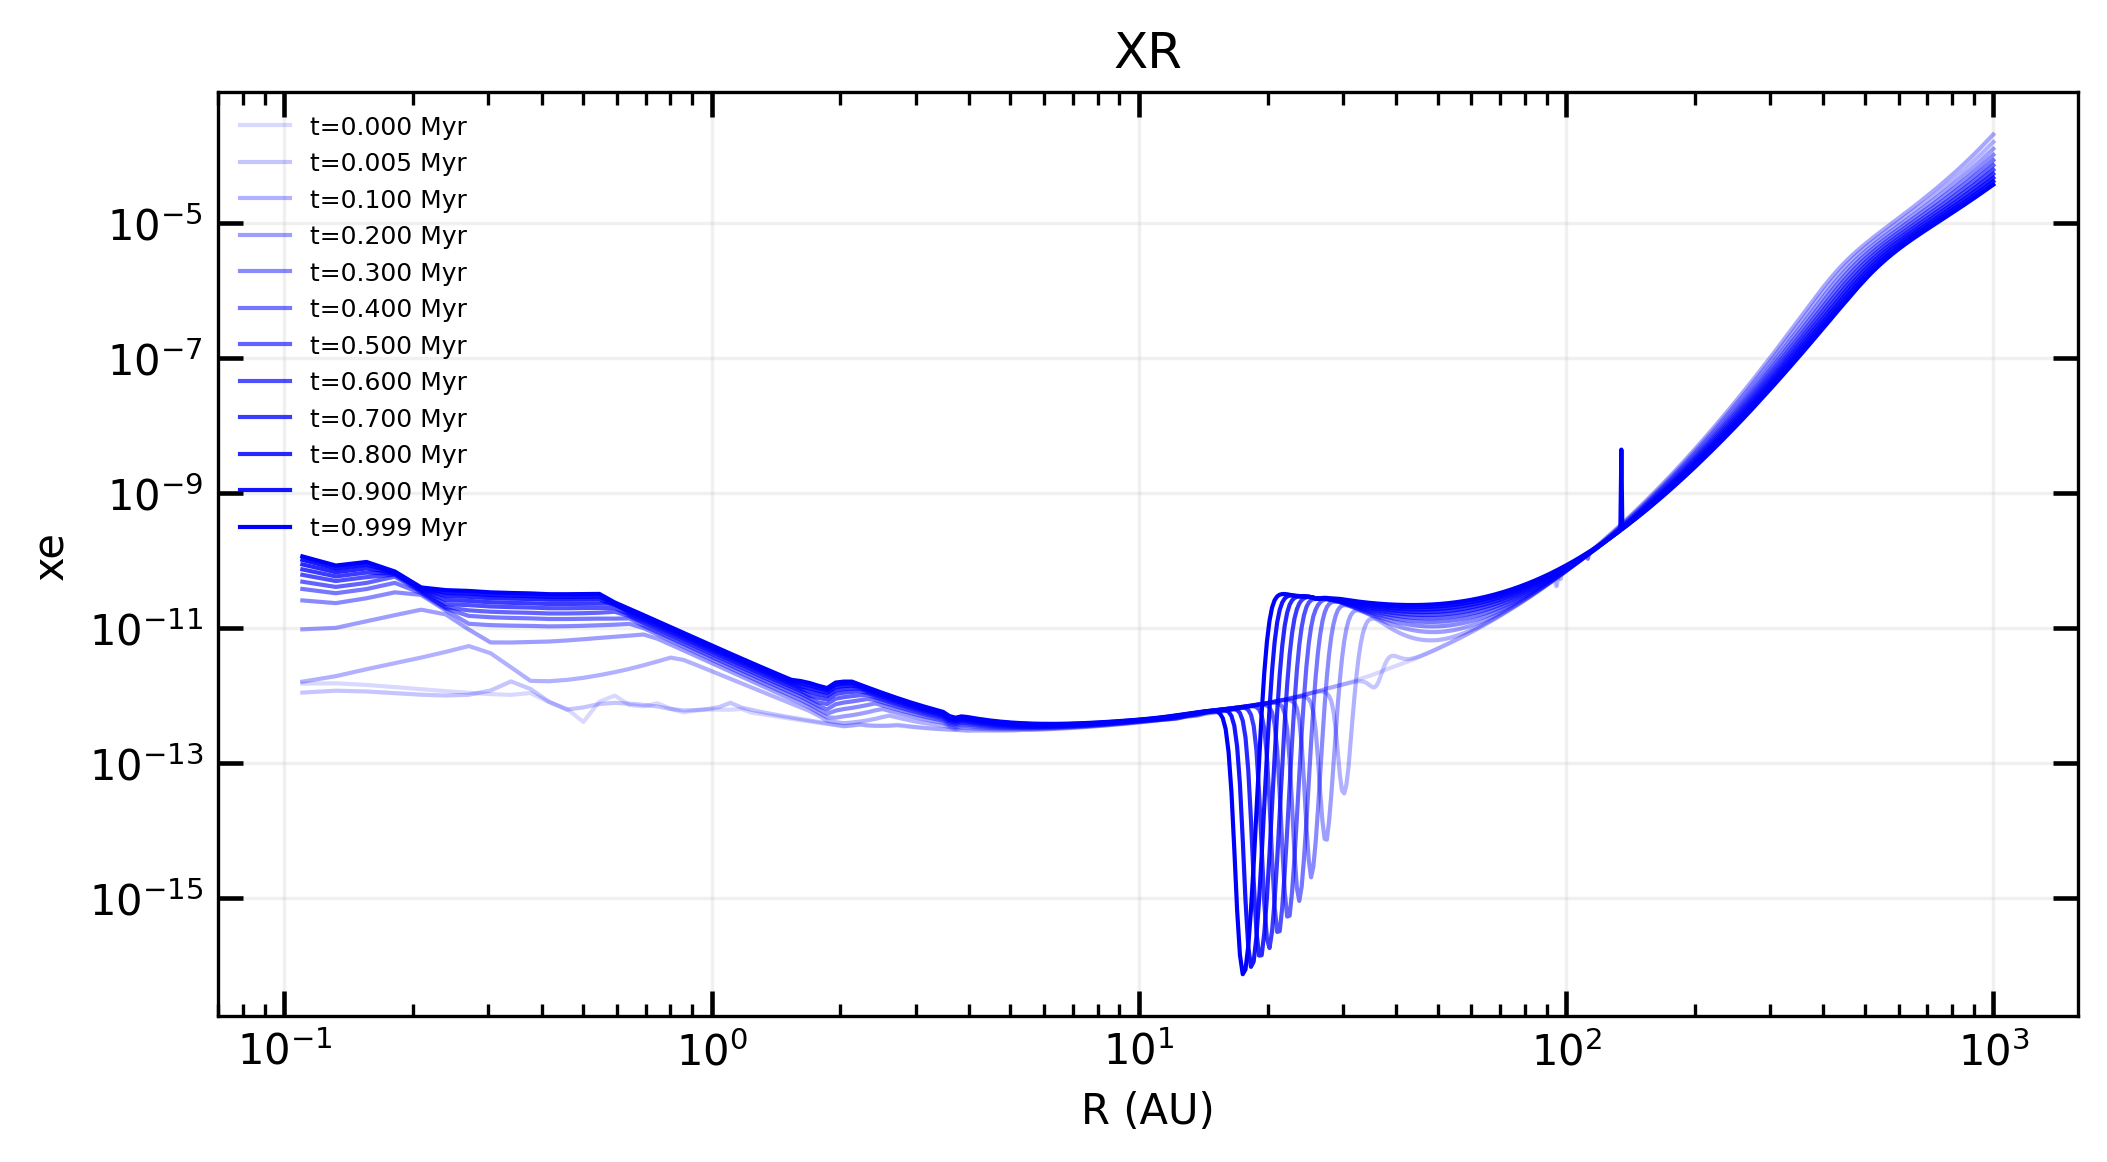

In [21]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrxe
for a_i, i in enumerate(xridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

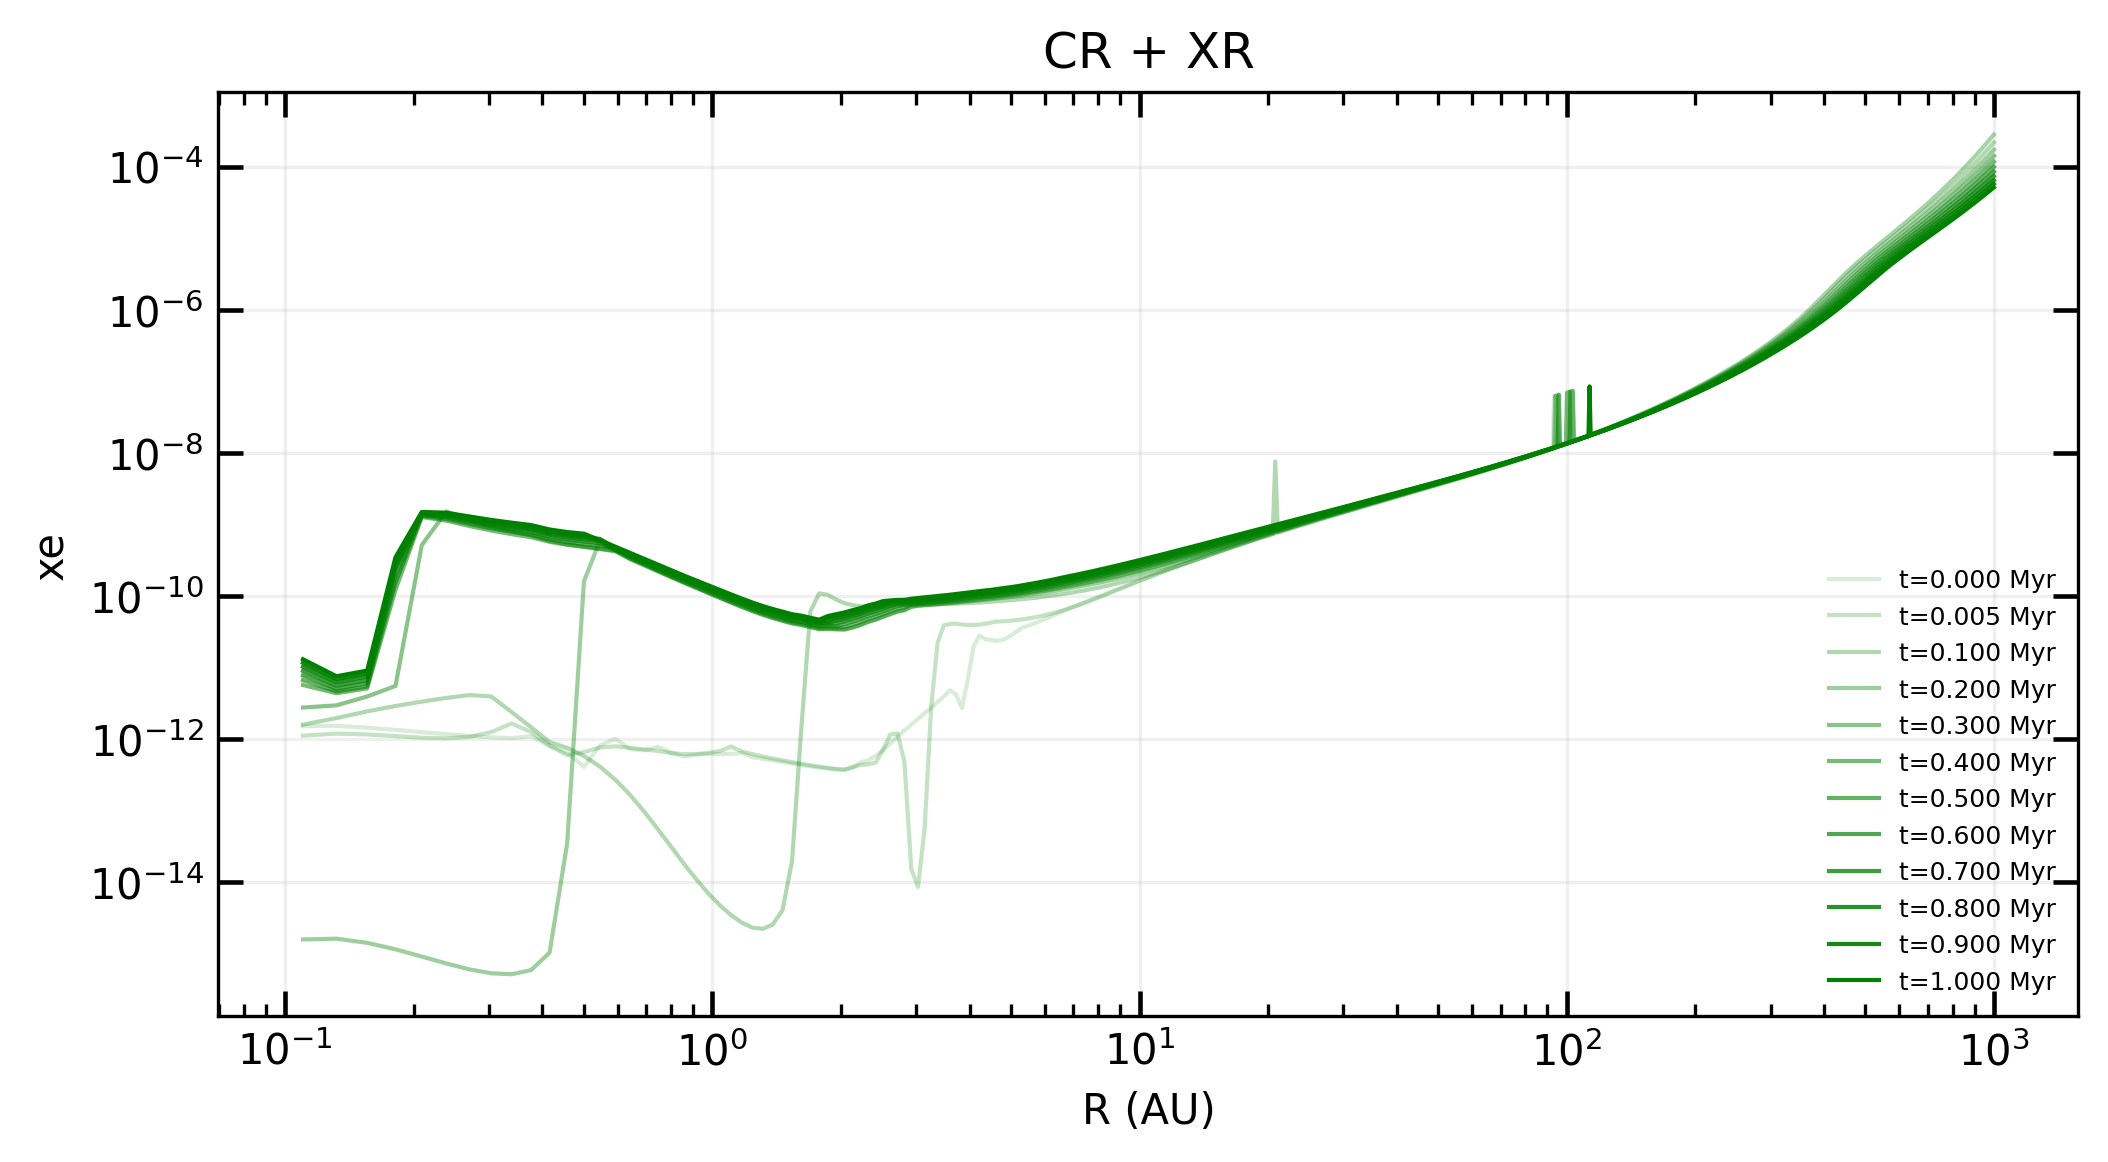

In [22]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxxe
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Elsasser Number

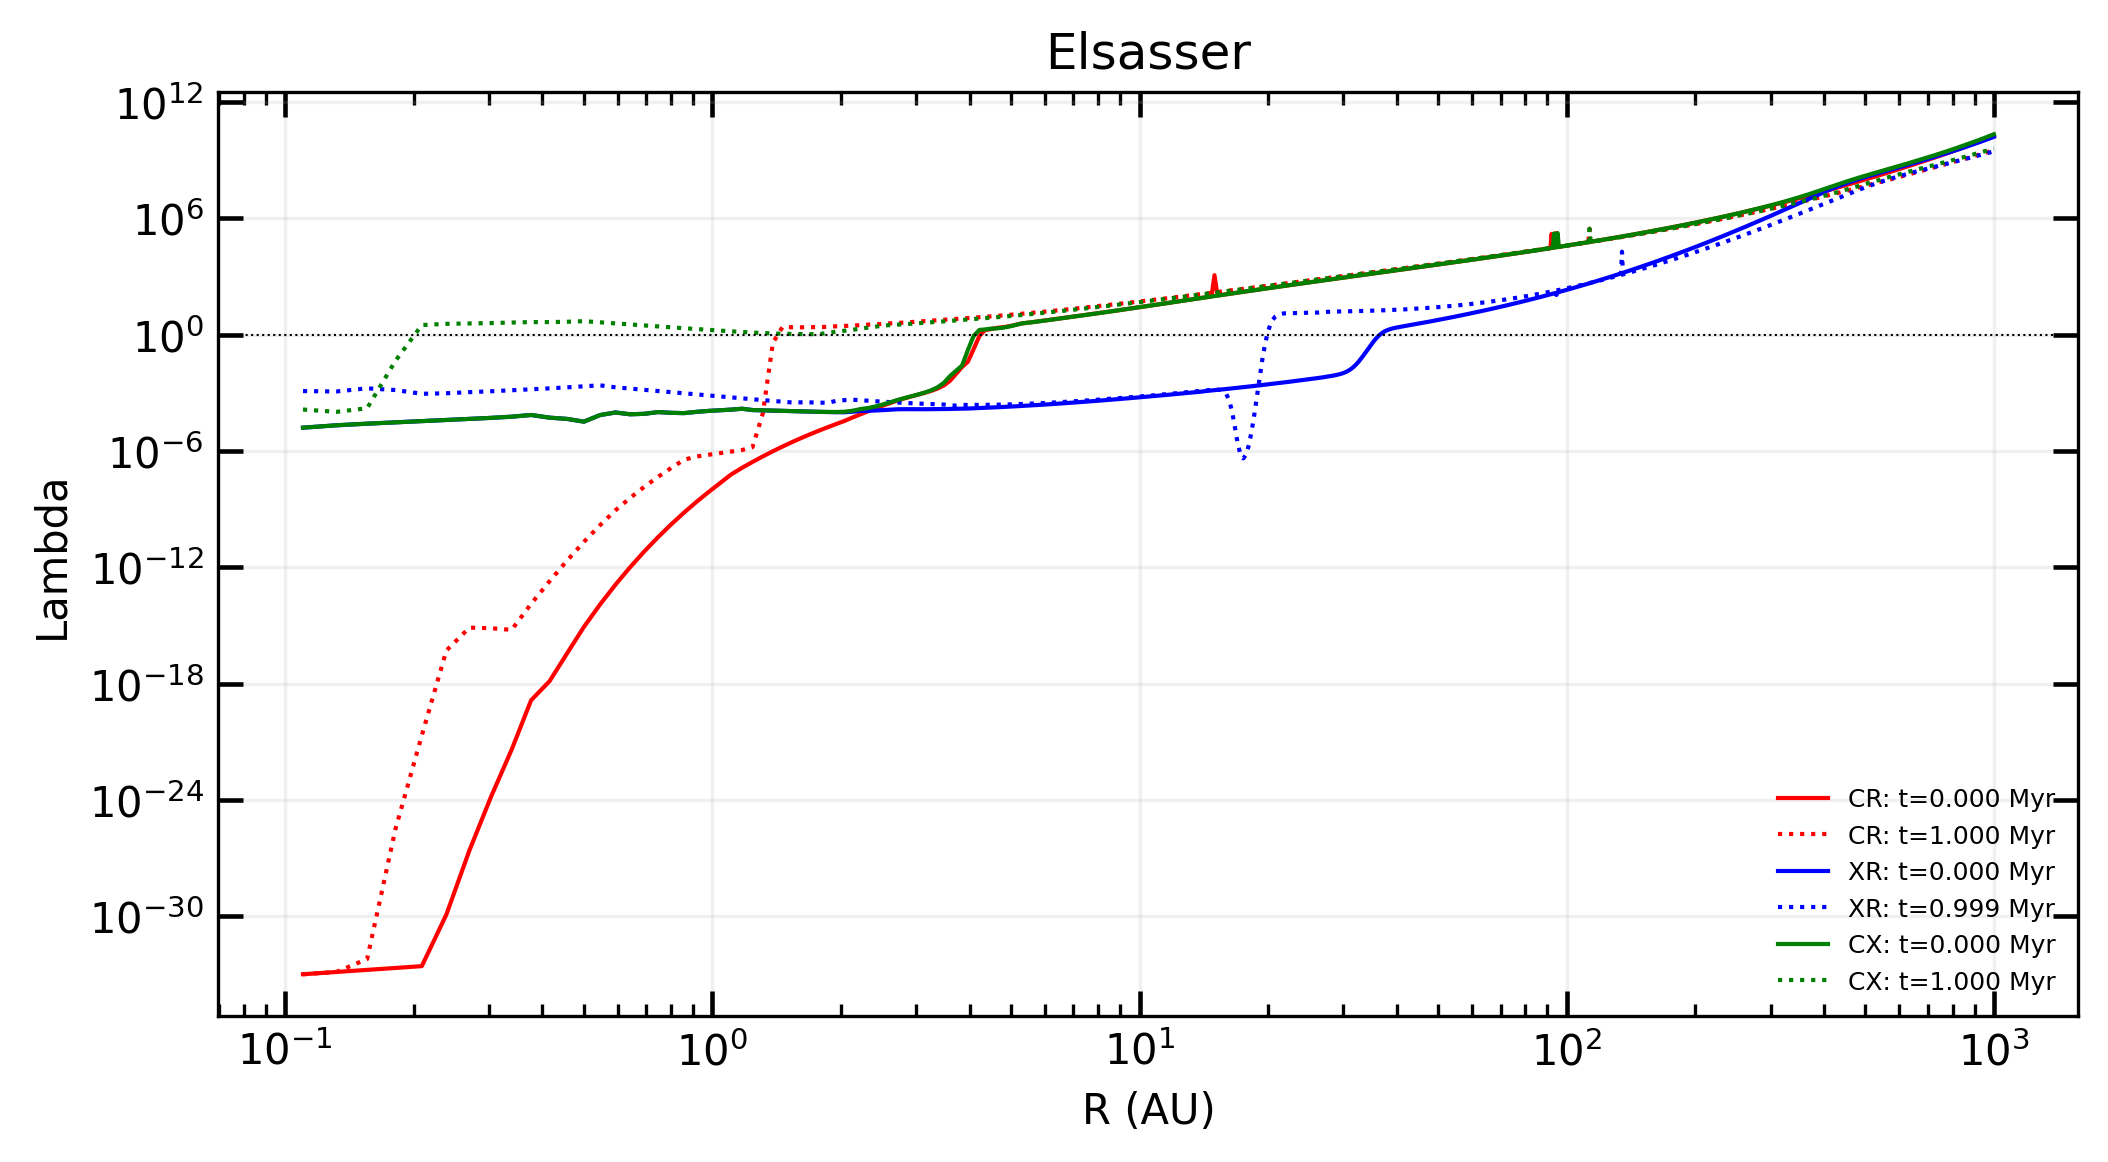

In [23]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Lambda')
plt.title('Elsasser')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crLam[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crLam[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrLam[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrLam[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxLam[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxLam[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.axhline(1, ls = 'dotted', color = 'black', lw = 0.5)
ax.legend(frameon=False, fontsize=6, loc="best")

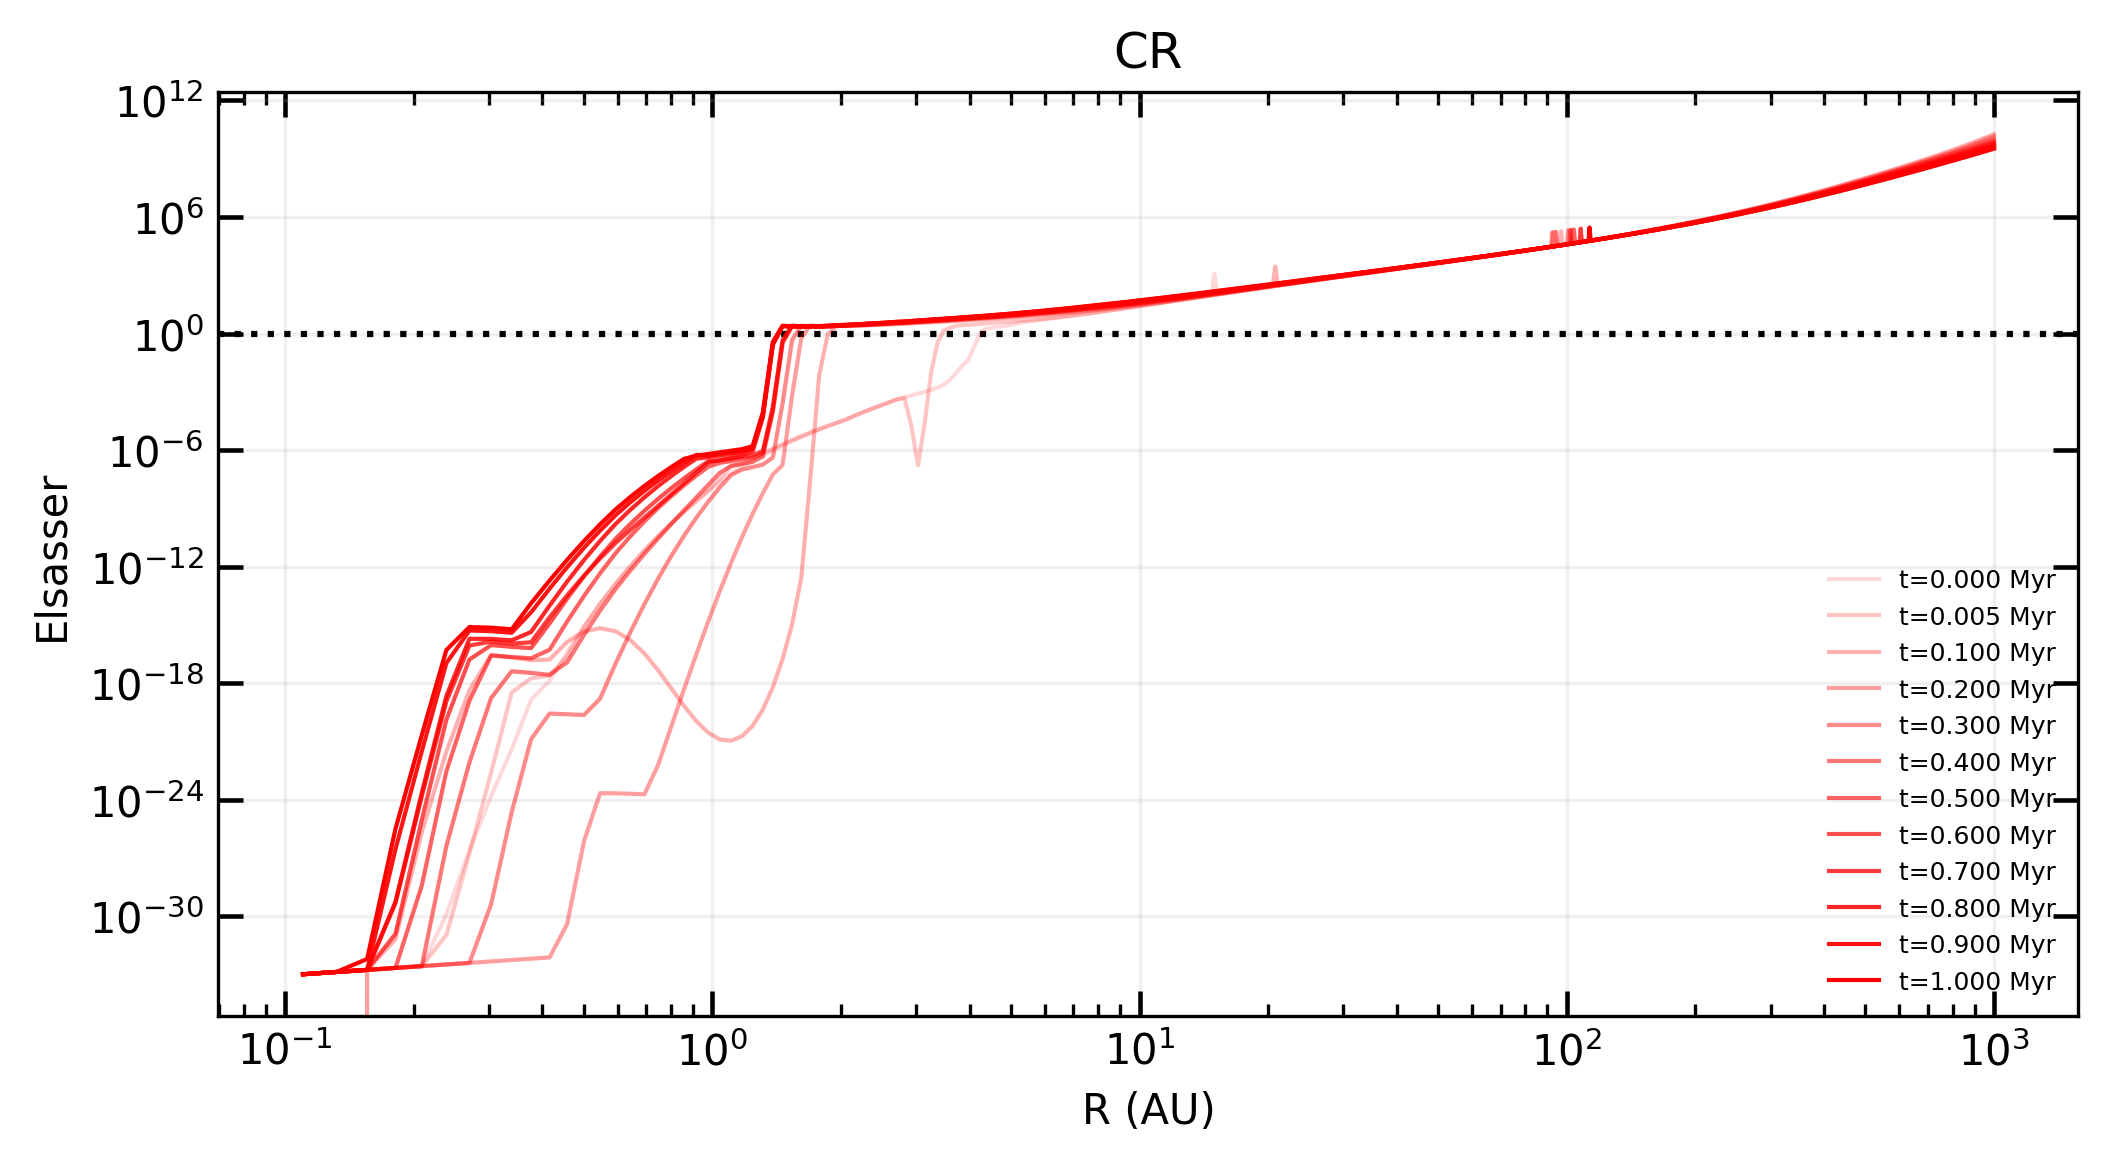

In [24]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Elsasser')
plt.title('CR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)
ax.axhline(y = 1.0, color = 'black', ls = 'dotted')

xdata = crR
ydata = crLam
for a_i, i in enumerate(cridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

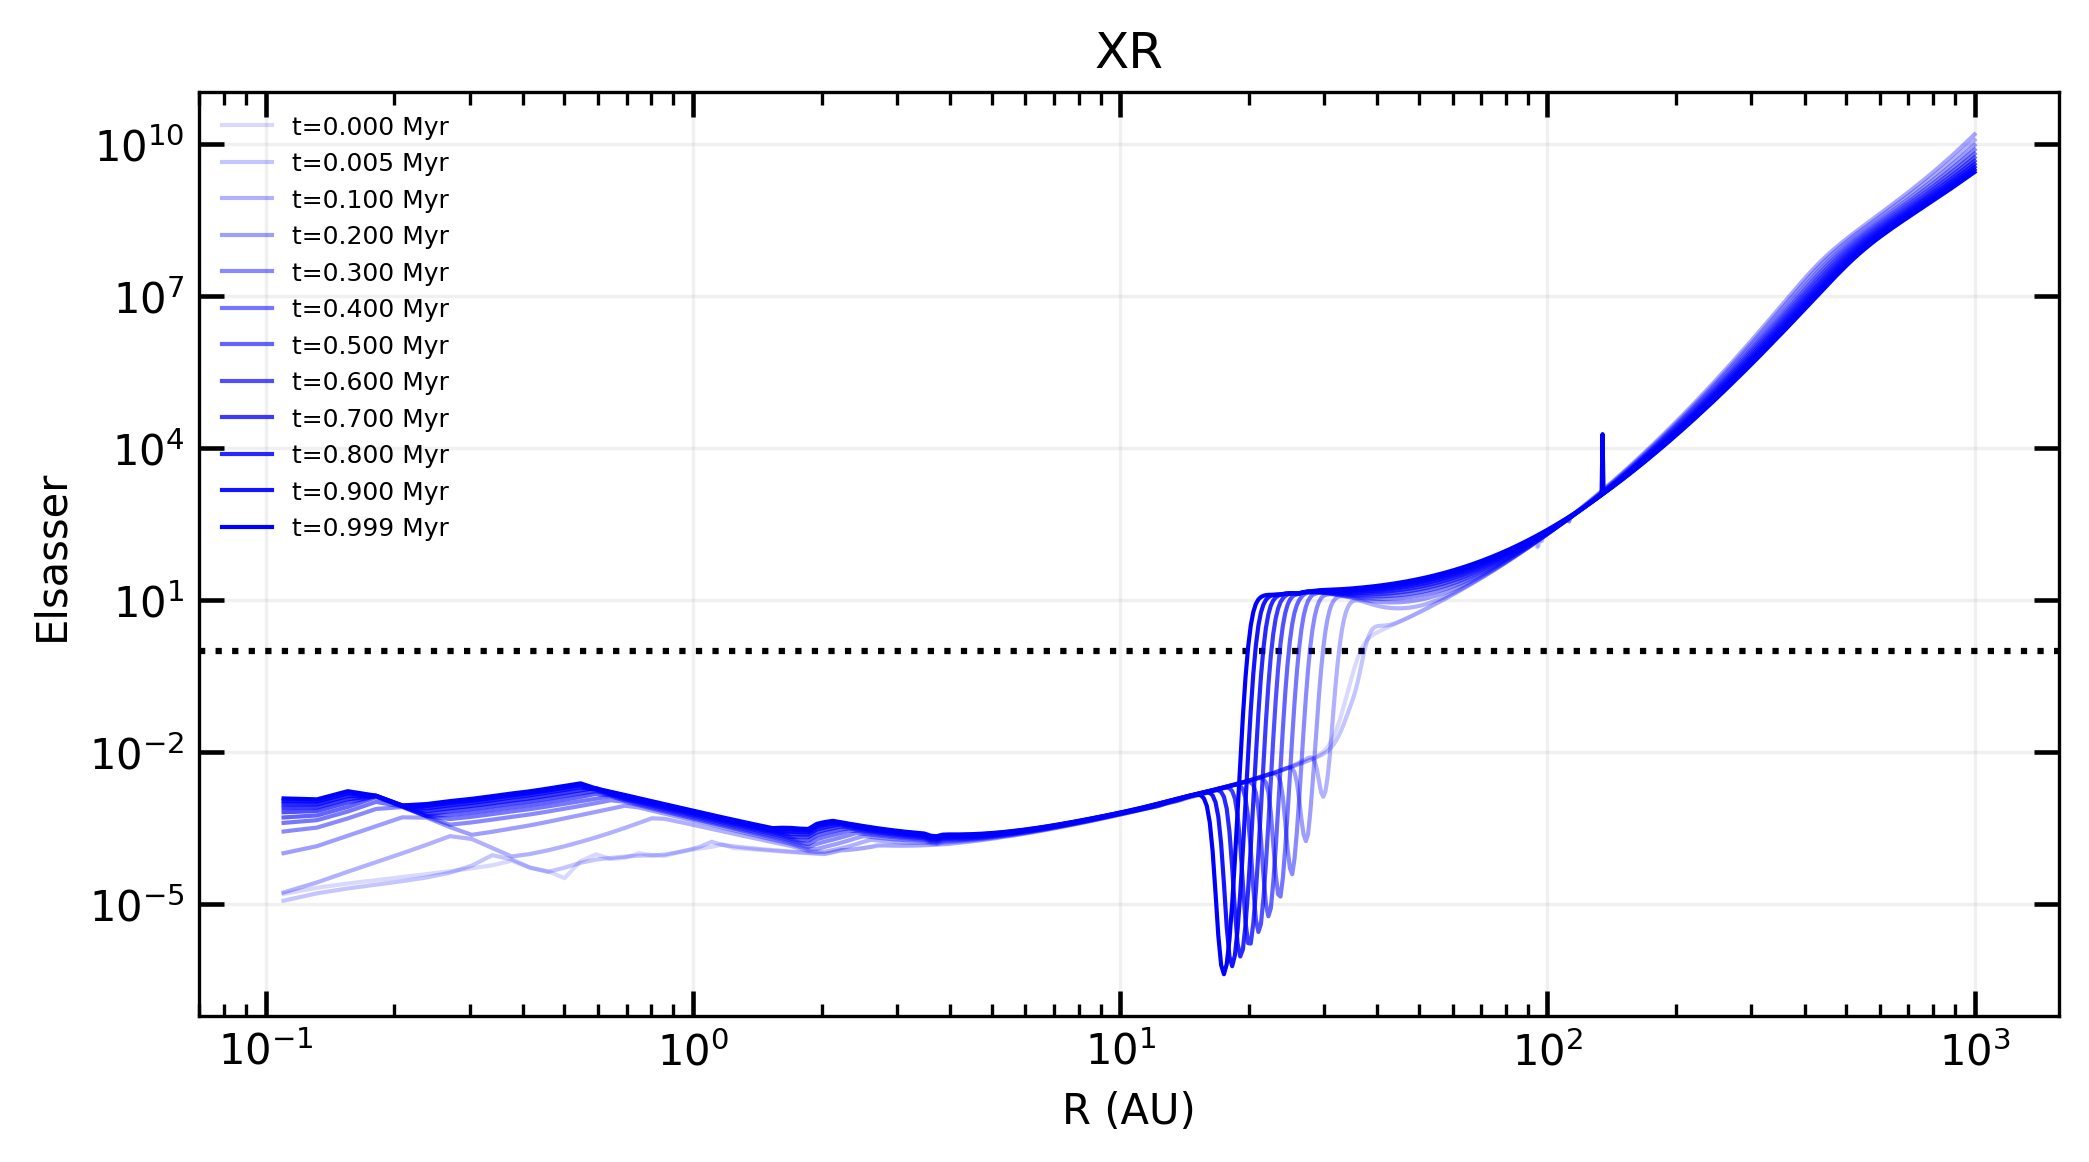

In [25]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Elsasser')
plt.title('XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)
ax.axhline(y = 1.0, color = 'black', ls = 'dotted')

xdata = xrR
ydata = xrLam
for a_i, i in enumerate(xridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

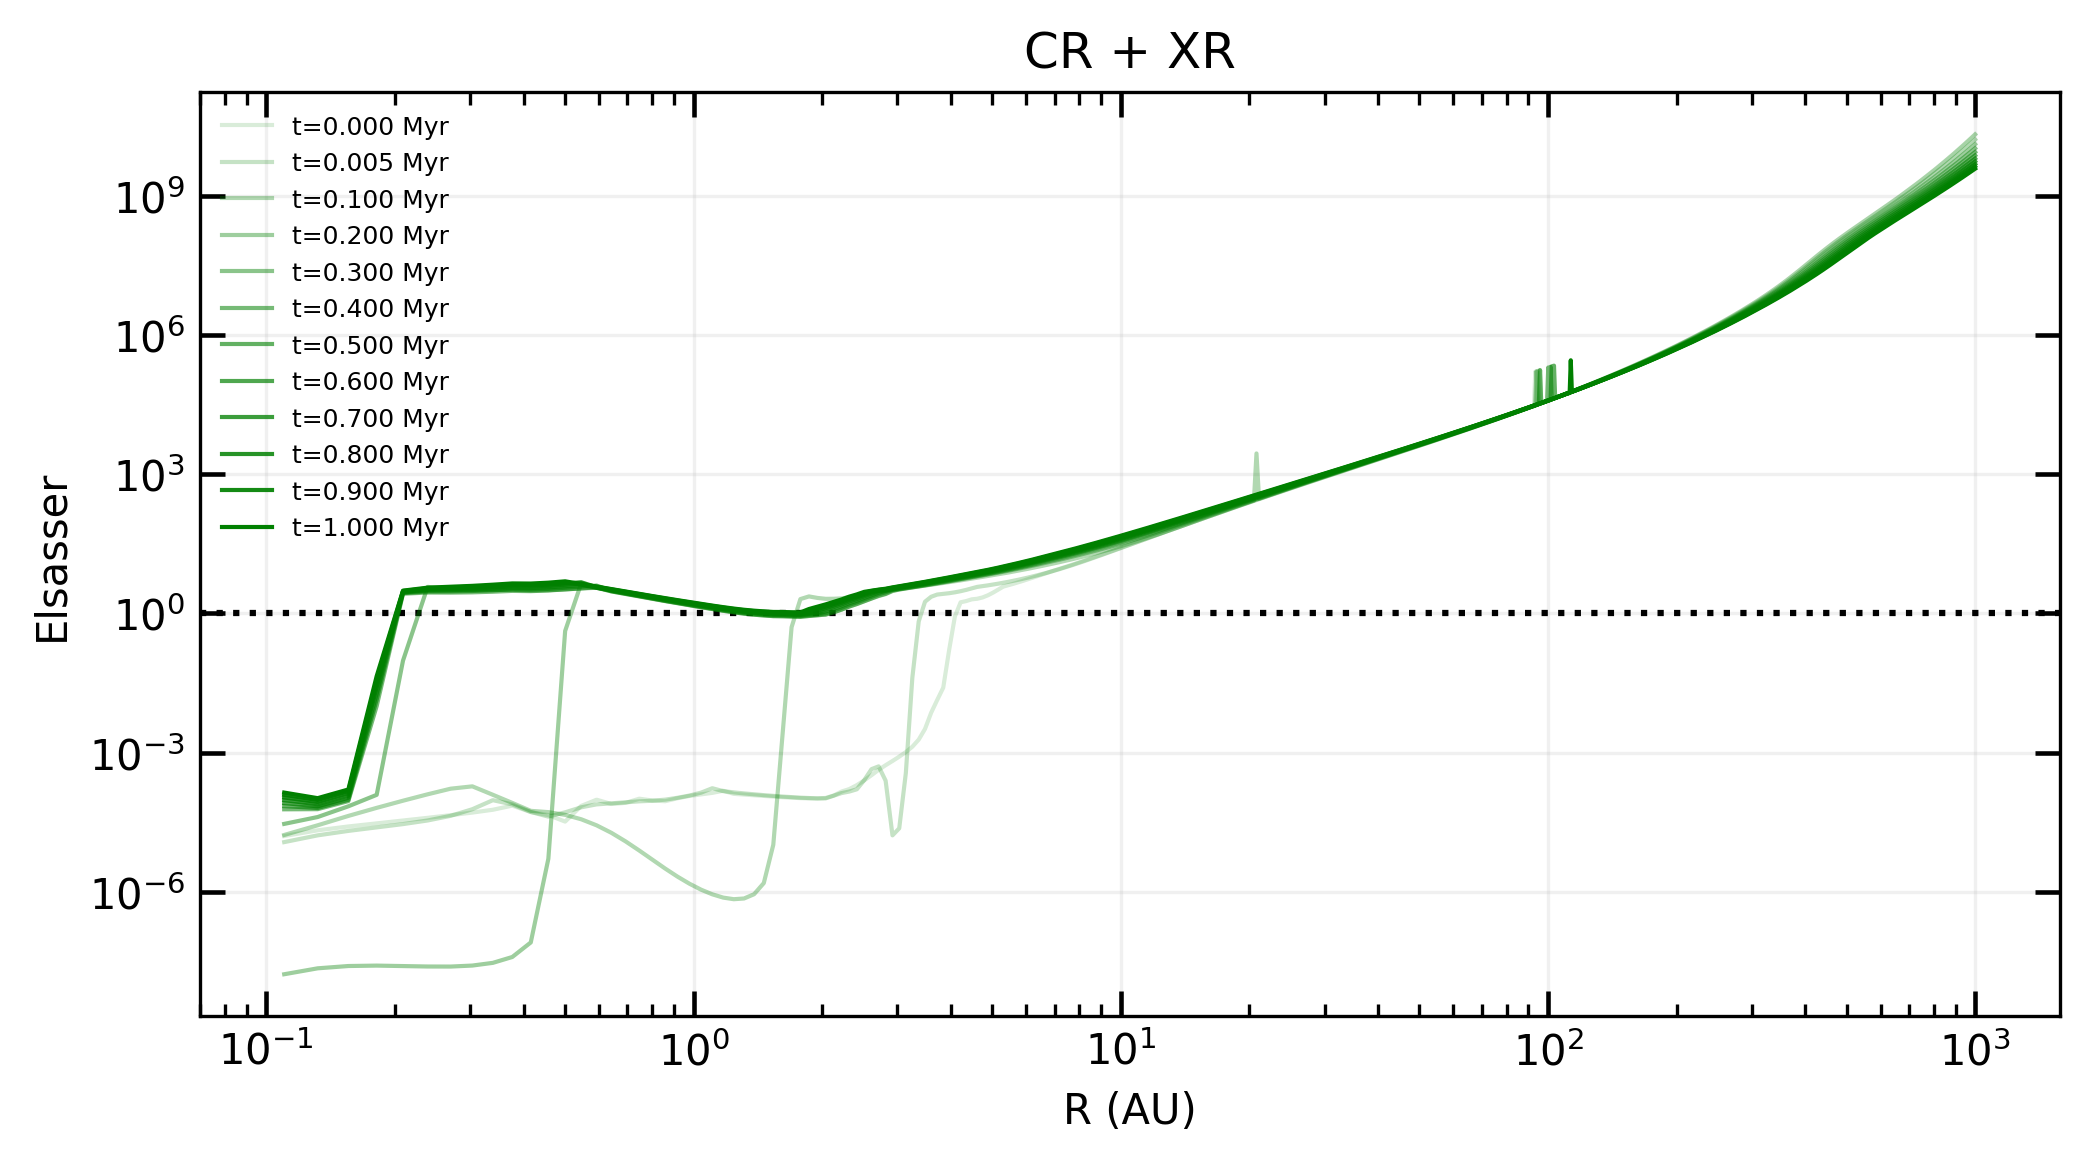

In [26]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Elsasser')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)
ax.axhline(y = 1.0, color = 'black', ls = 'dotted')

xdata = cxR
ydata = cxLam
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# eta Magnetic Diffusivity

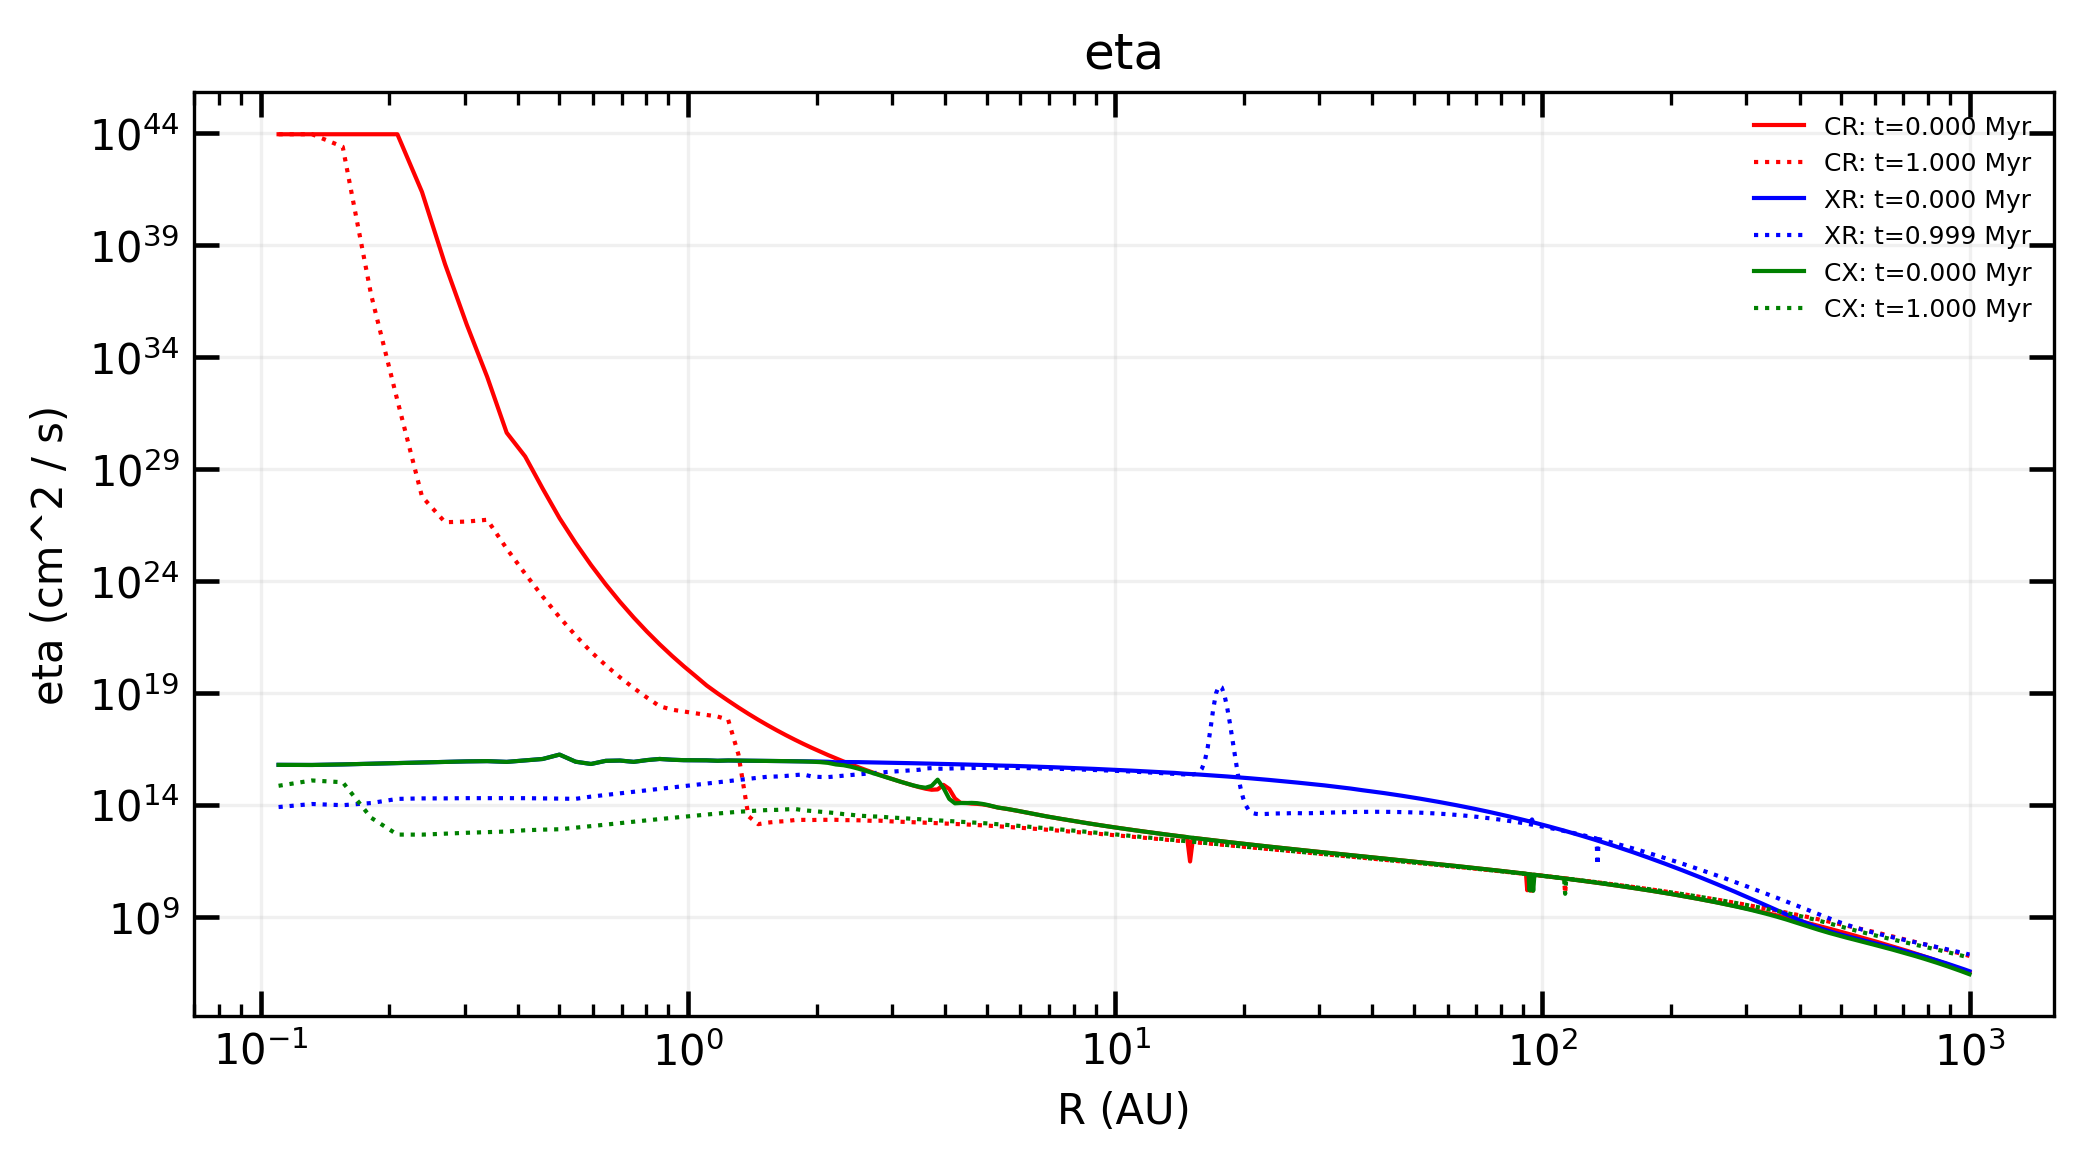

In [27]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('eta (cm^2 / s)')
plt.title('eta')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, creta[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, creta[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xreta[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xreta[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxeta[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxeta[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# n density 

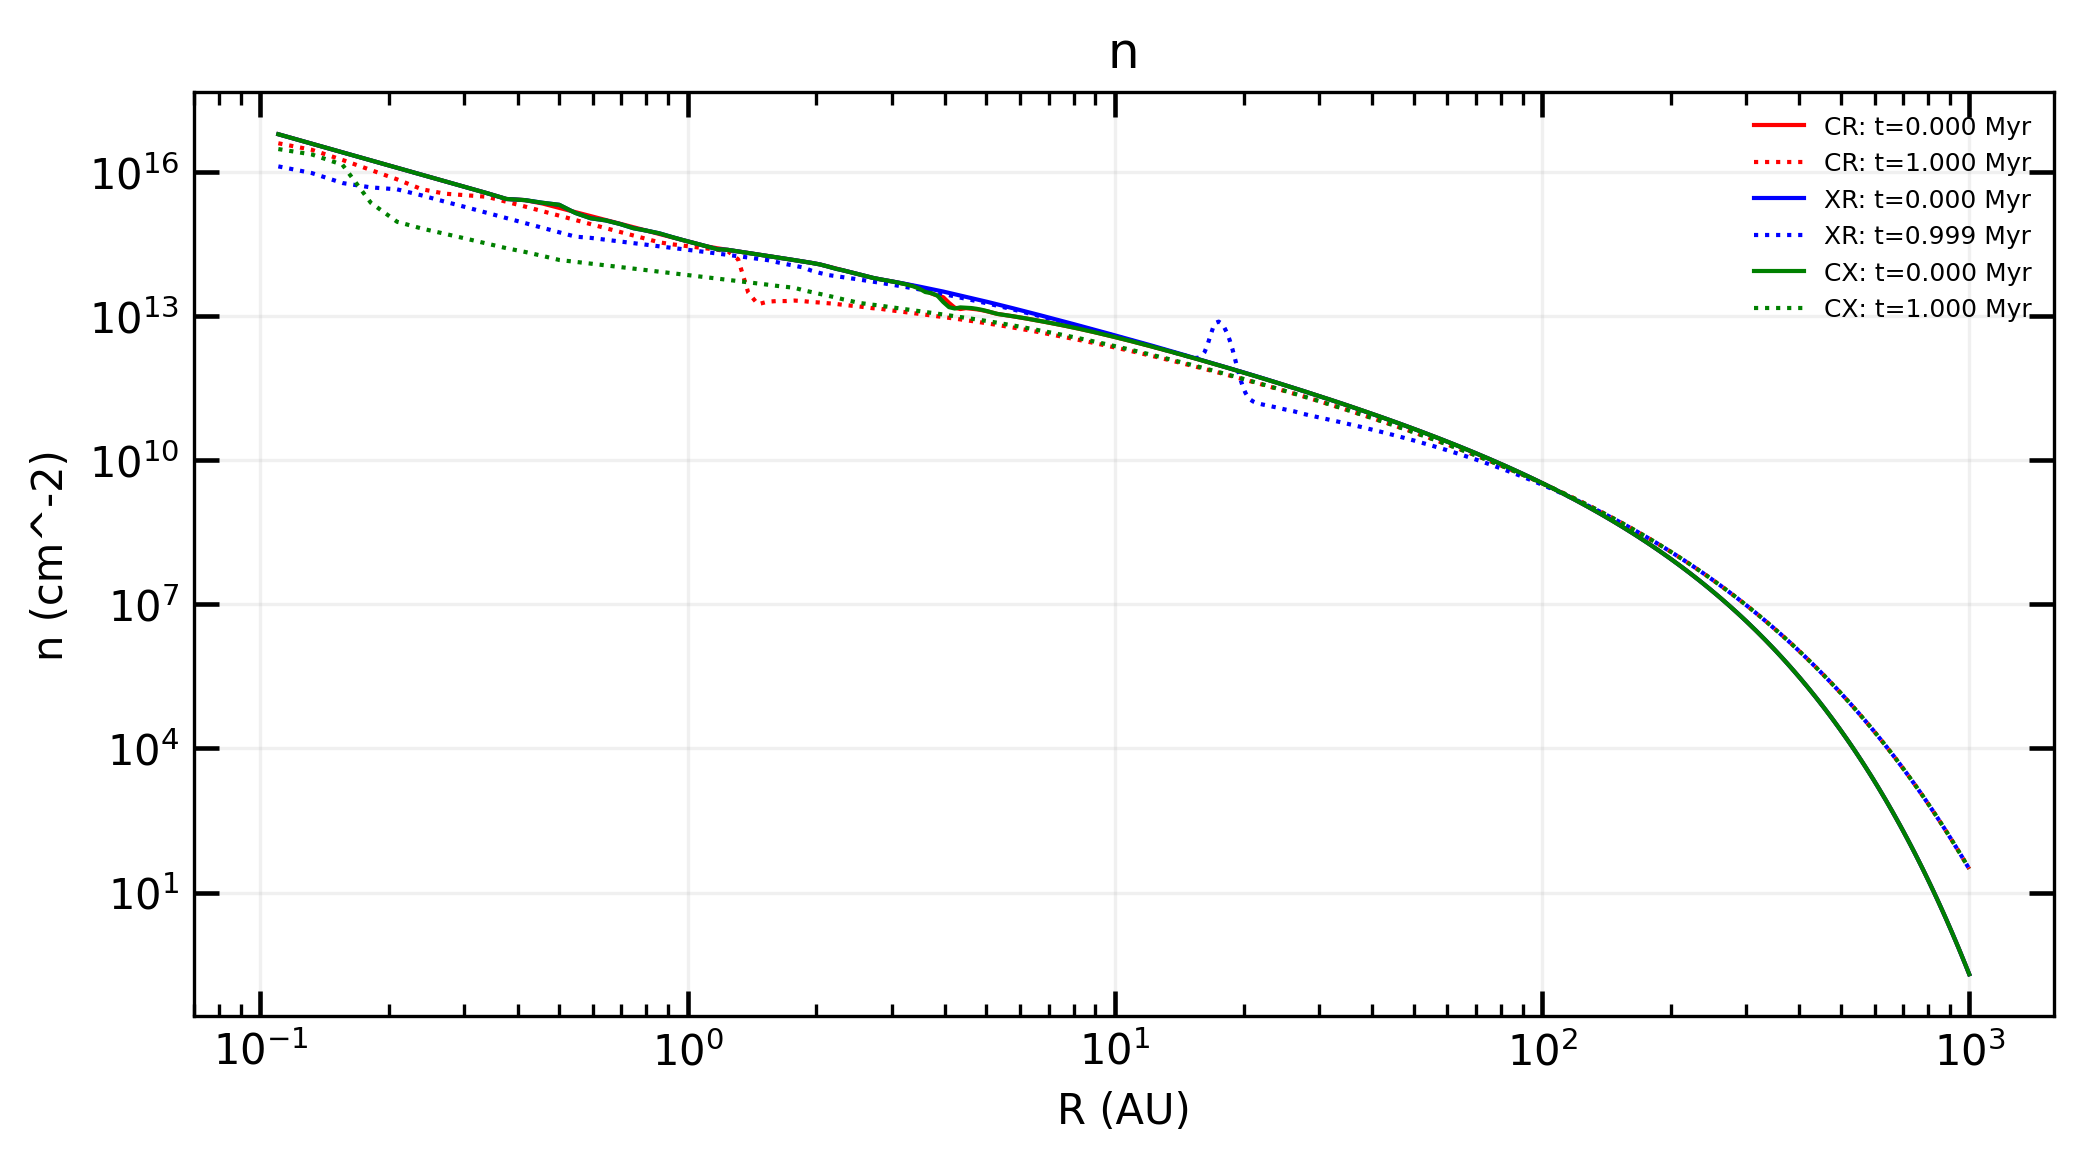

In [28]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crn[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crn[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrn[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrn[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxn[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxn[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

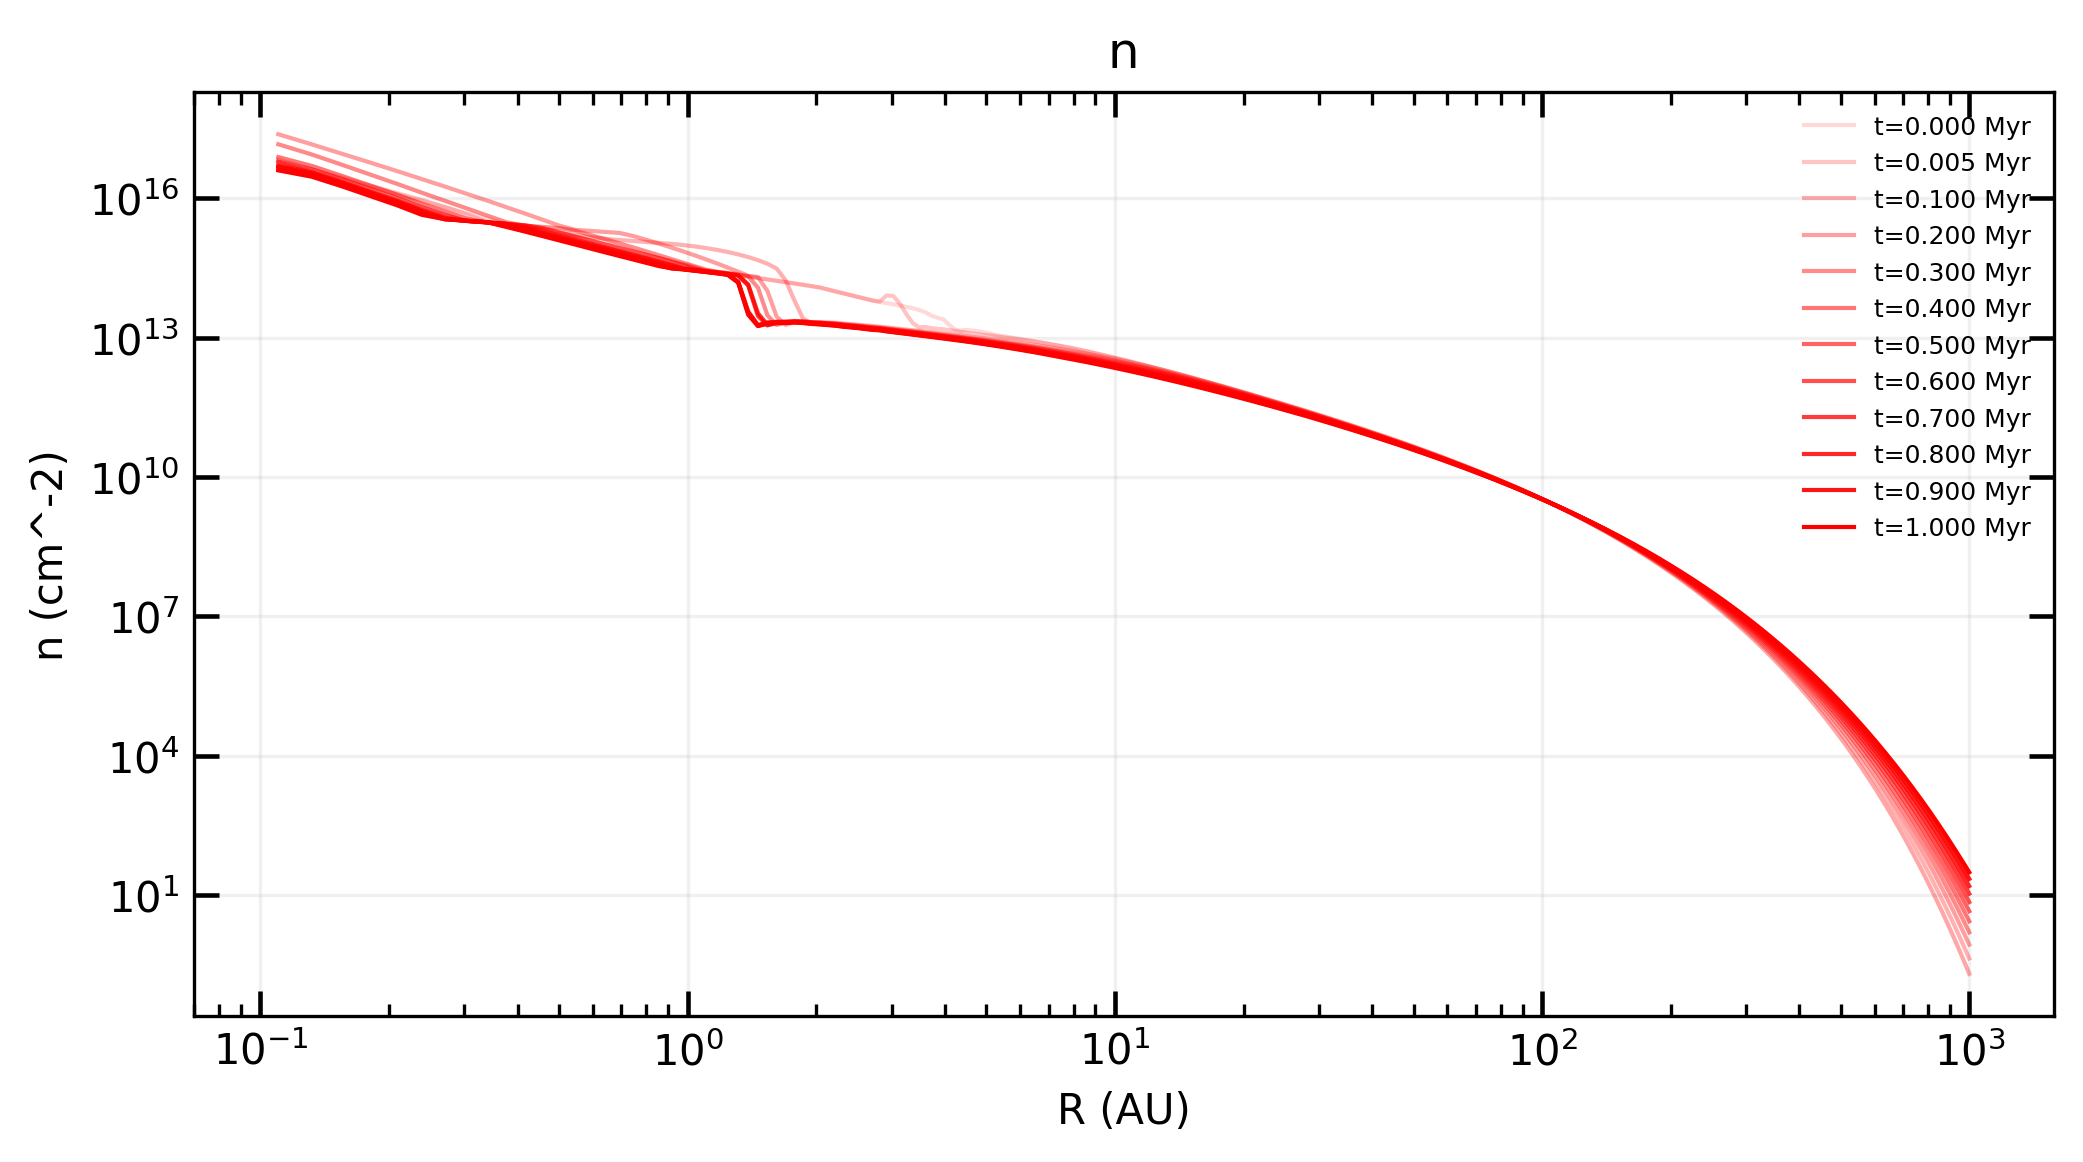

In [29]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crn
for a_i, i in enumerate(cridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

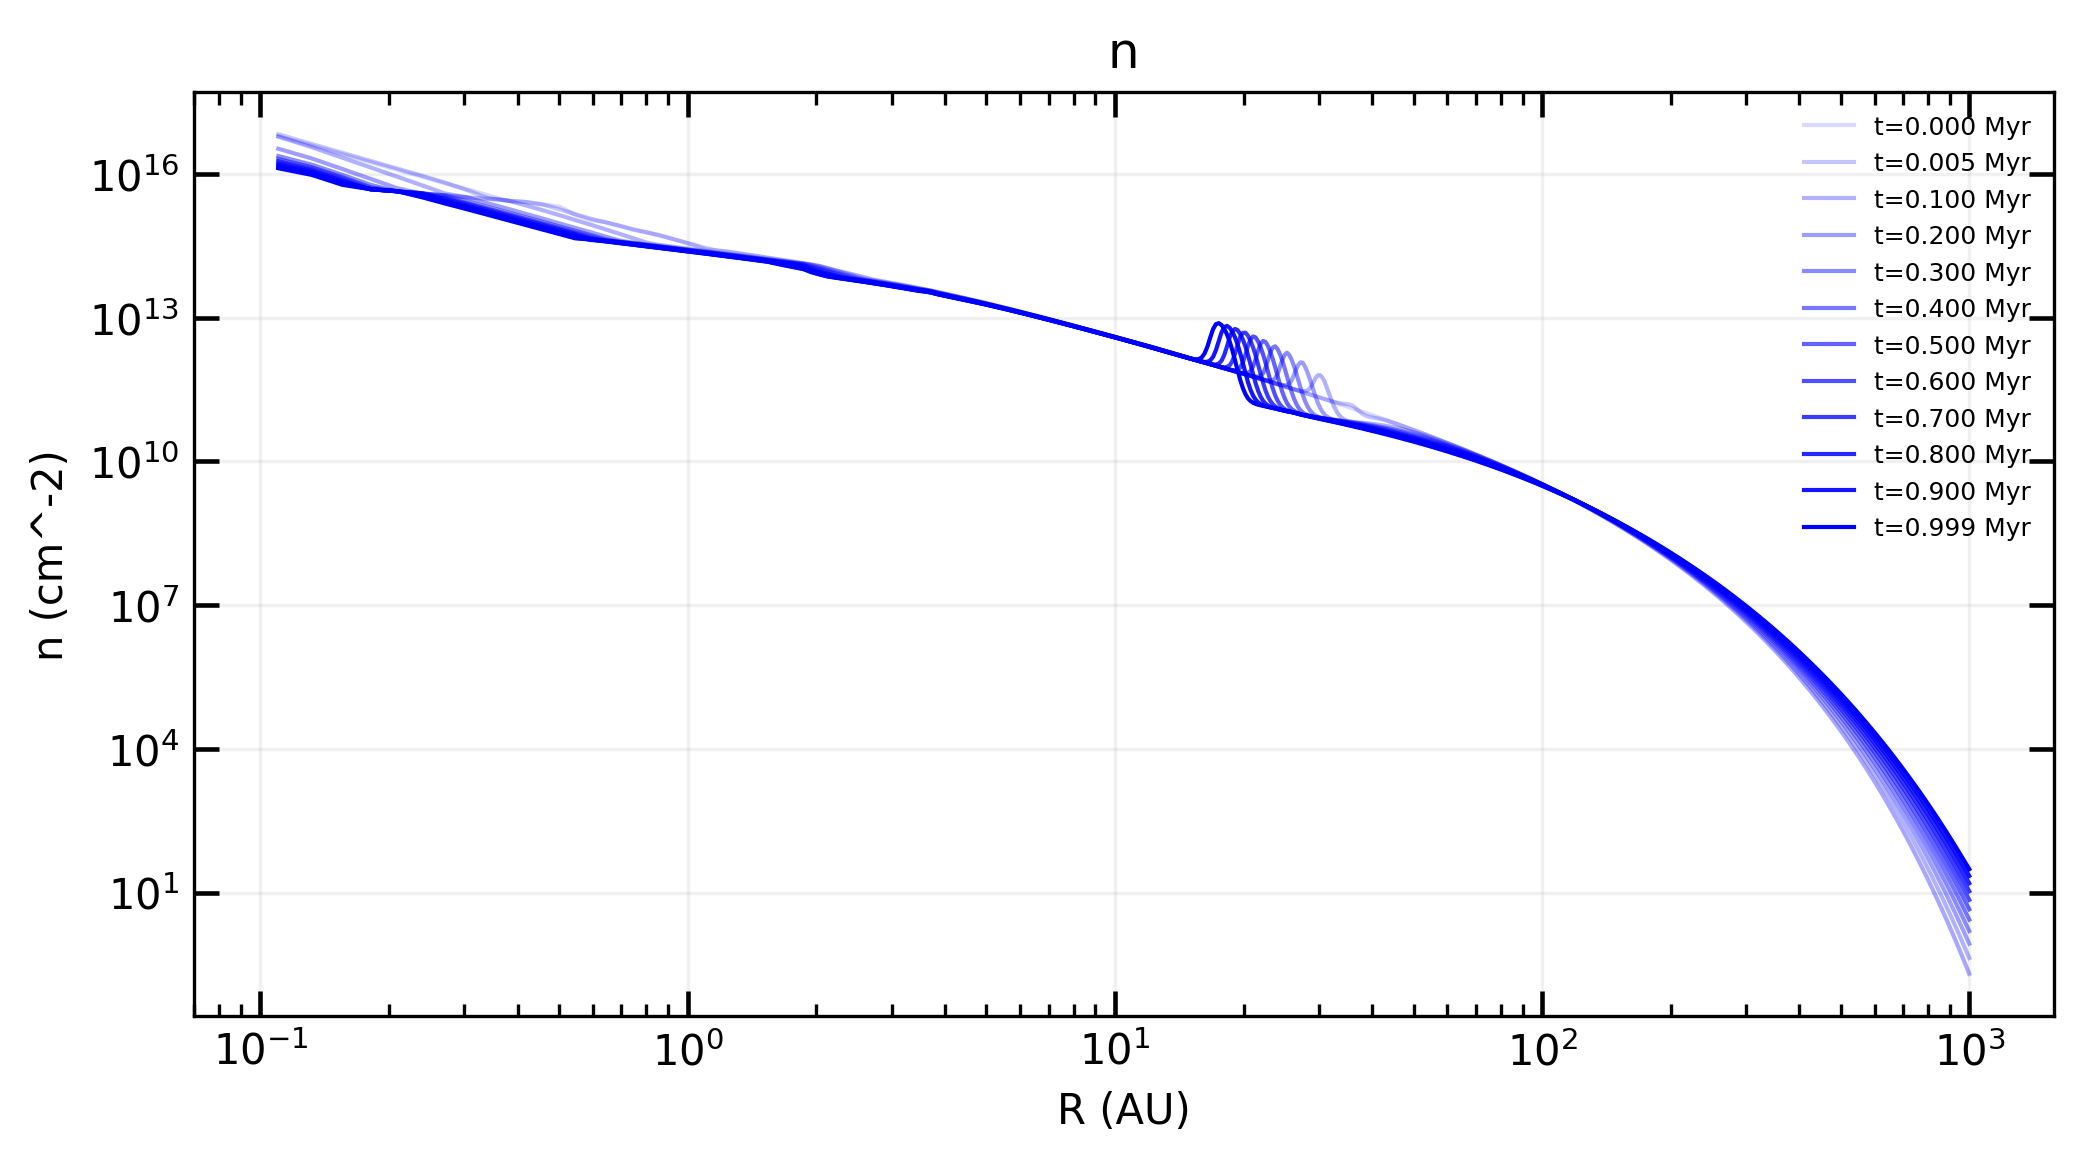

In [30]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrn
for a_i, i in enumerate(xridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

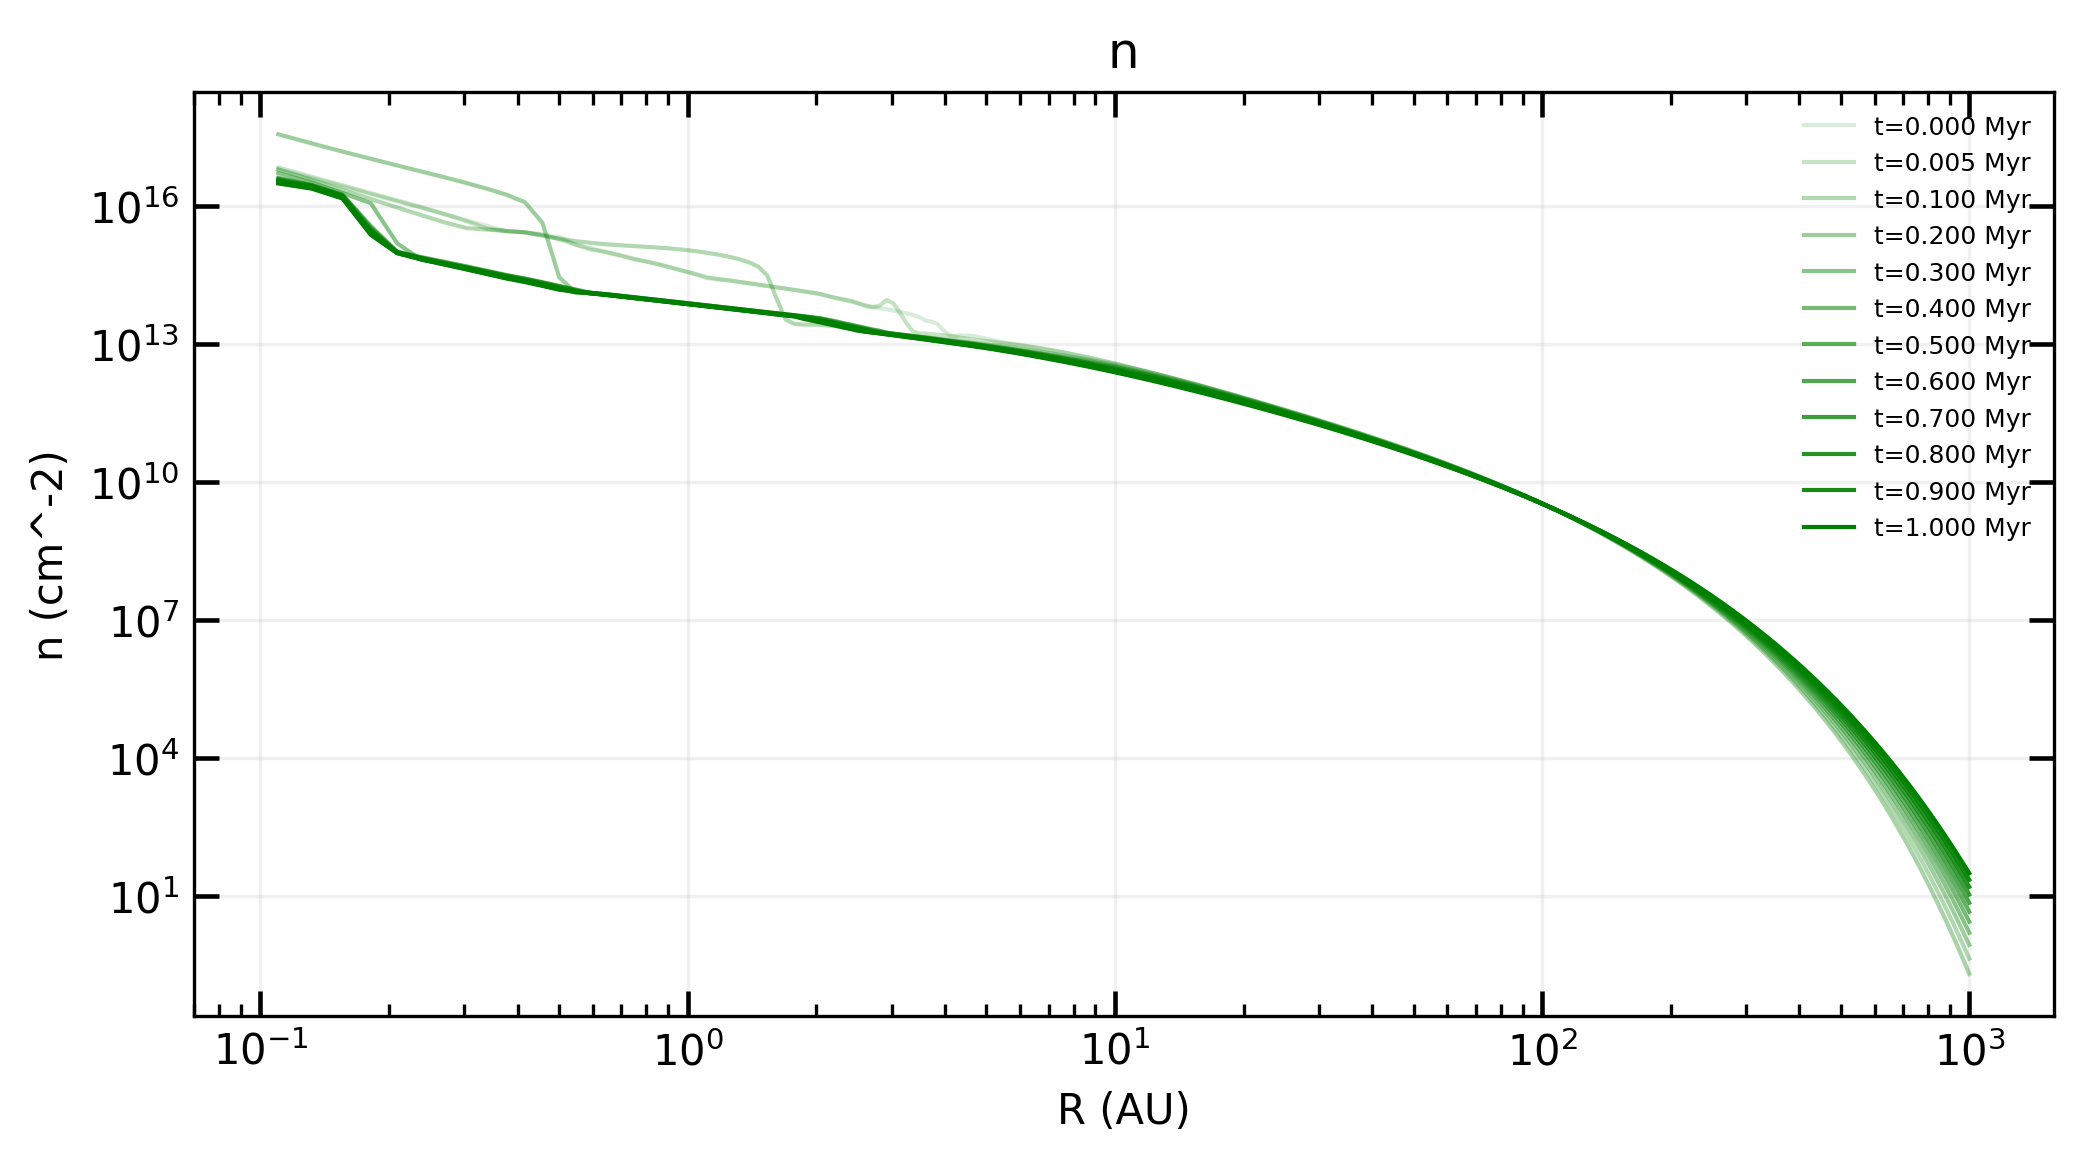

In [31]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxn
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Sigma

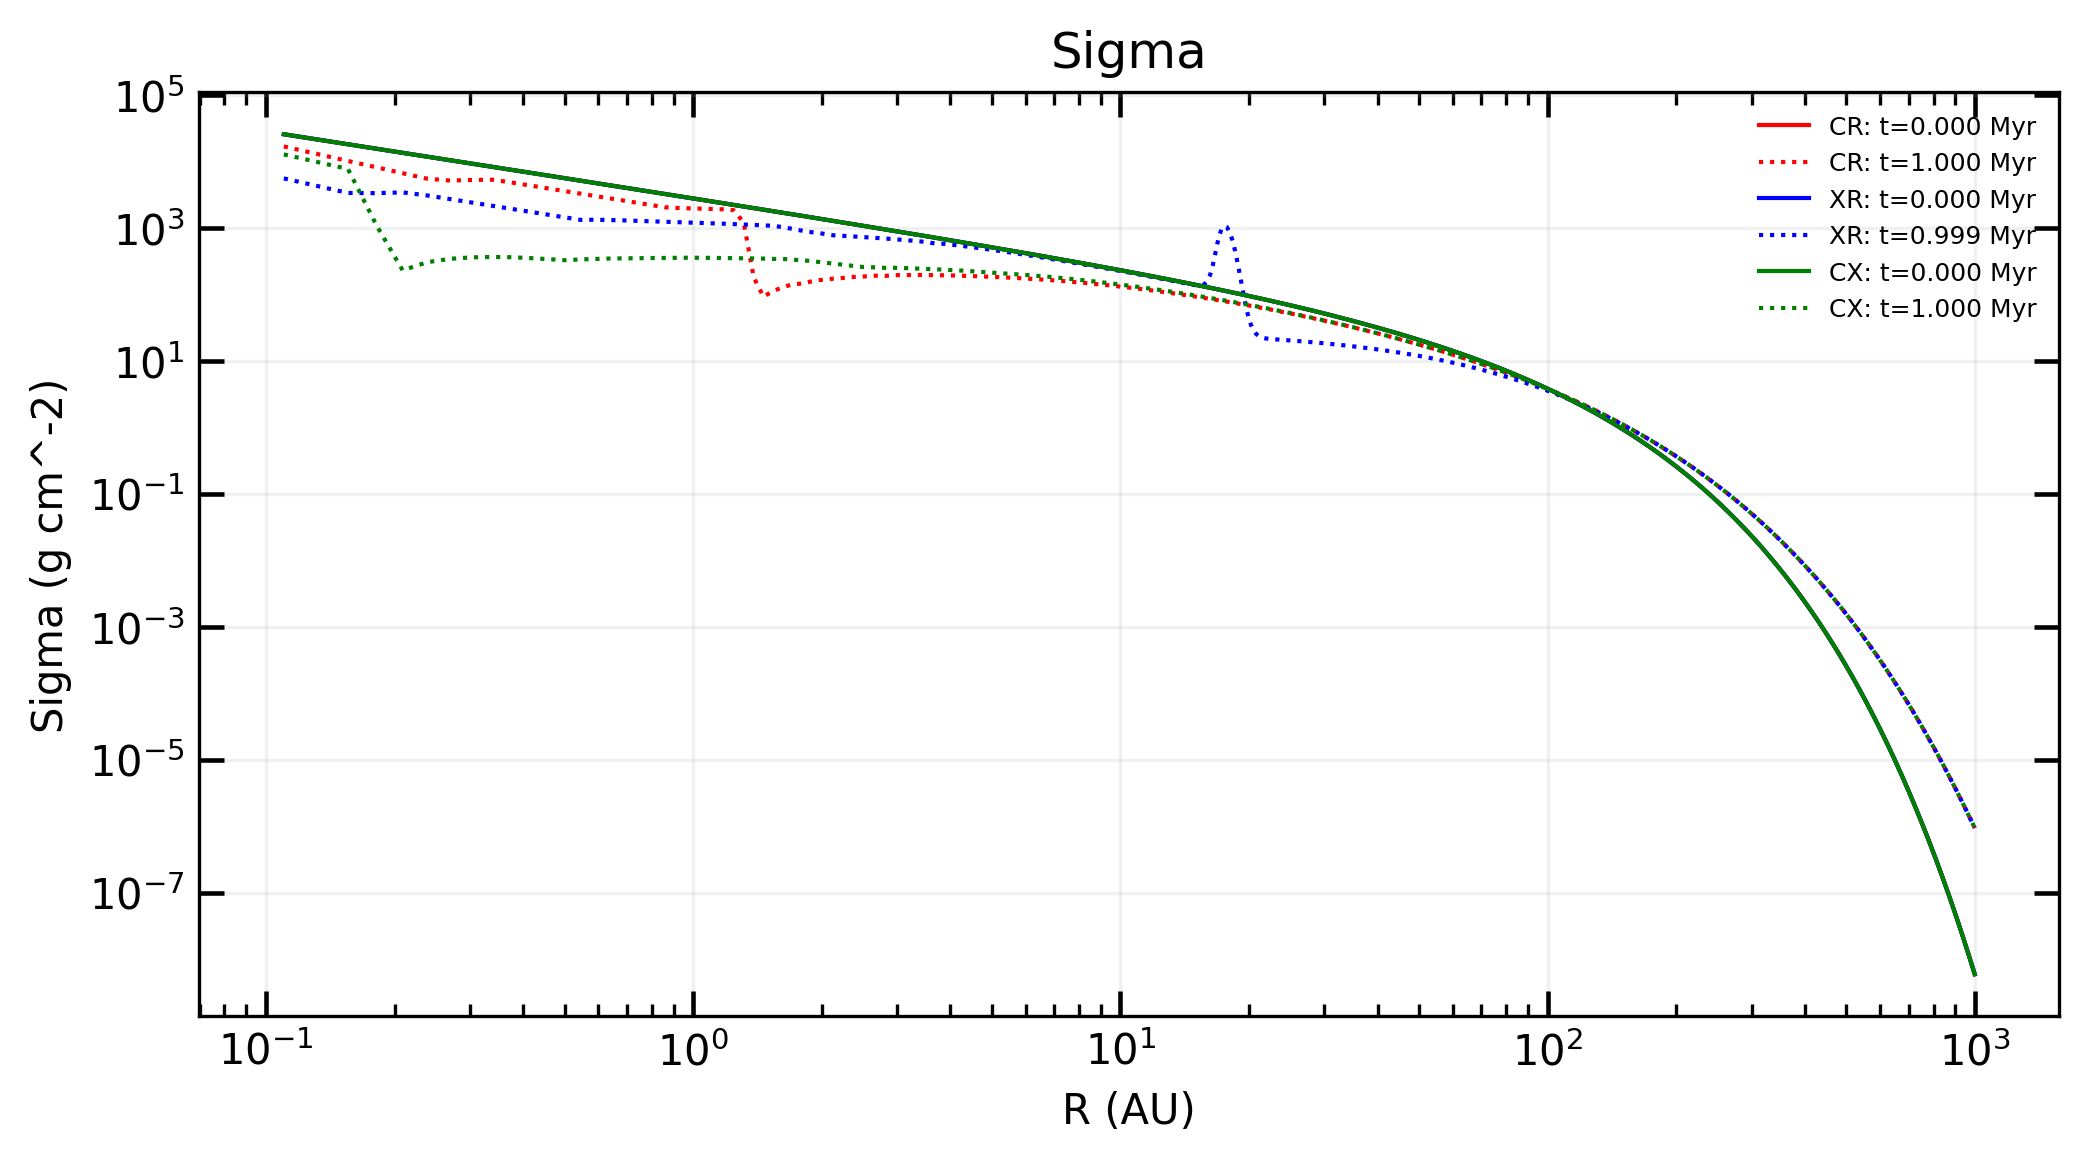

In [32]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('Sigma')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crSigma_g[0], linestyle='solid', color='red', label=rf"CR: t={crt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crSigma_g[-1], linestyle='dotted', color='red', label=rf"CR: t={crt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrSigma_g[0], linestyle='solid', color='blue', label=rf"XR: t={xrt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrSigma_g[-1], linestyle='dotted', color='blue', label=rf"XR: t={xrt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxSigma_g[0], linestyle='solid', color='green', label=rf"CX: t={cxt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxSigma_g[-1], linestyle='dotted', color='green', label=rf"CX: t={cxt[-1]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

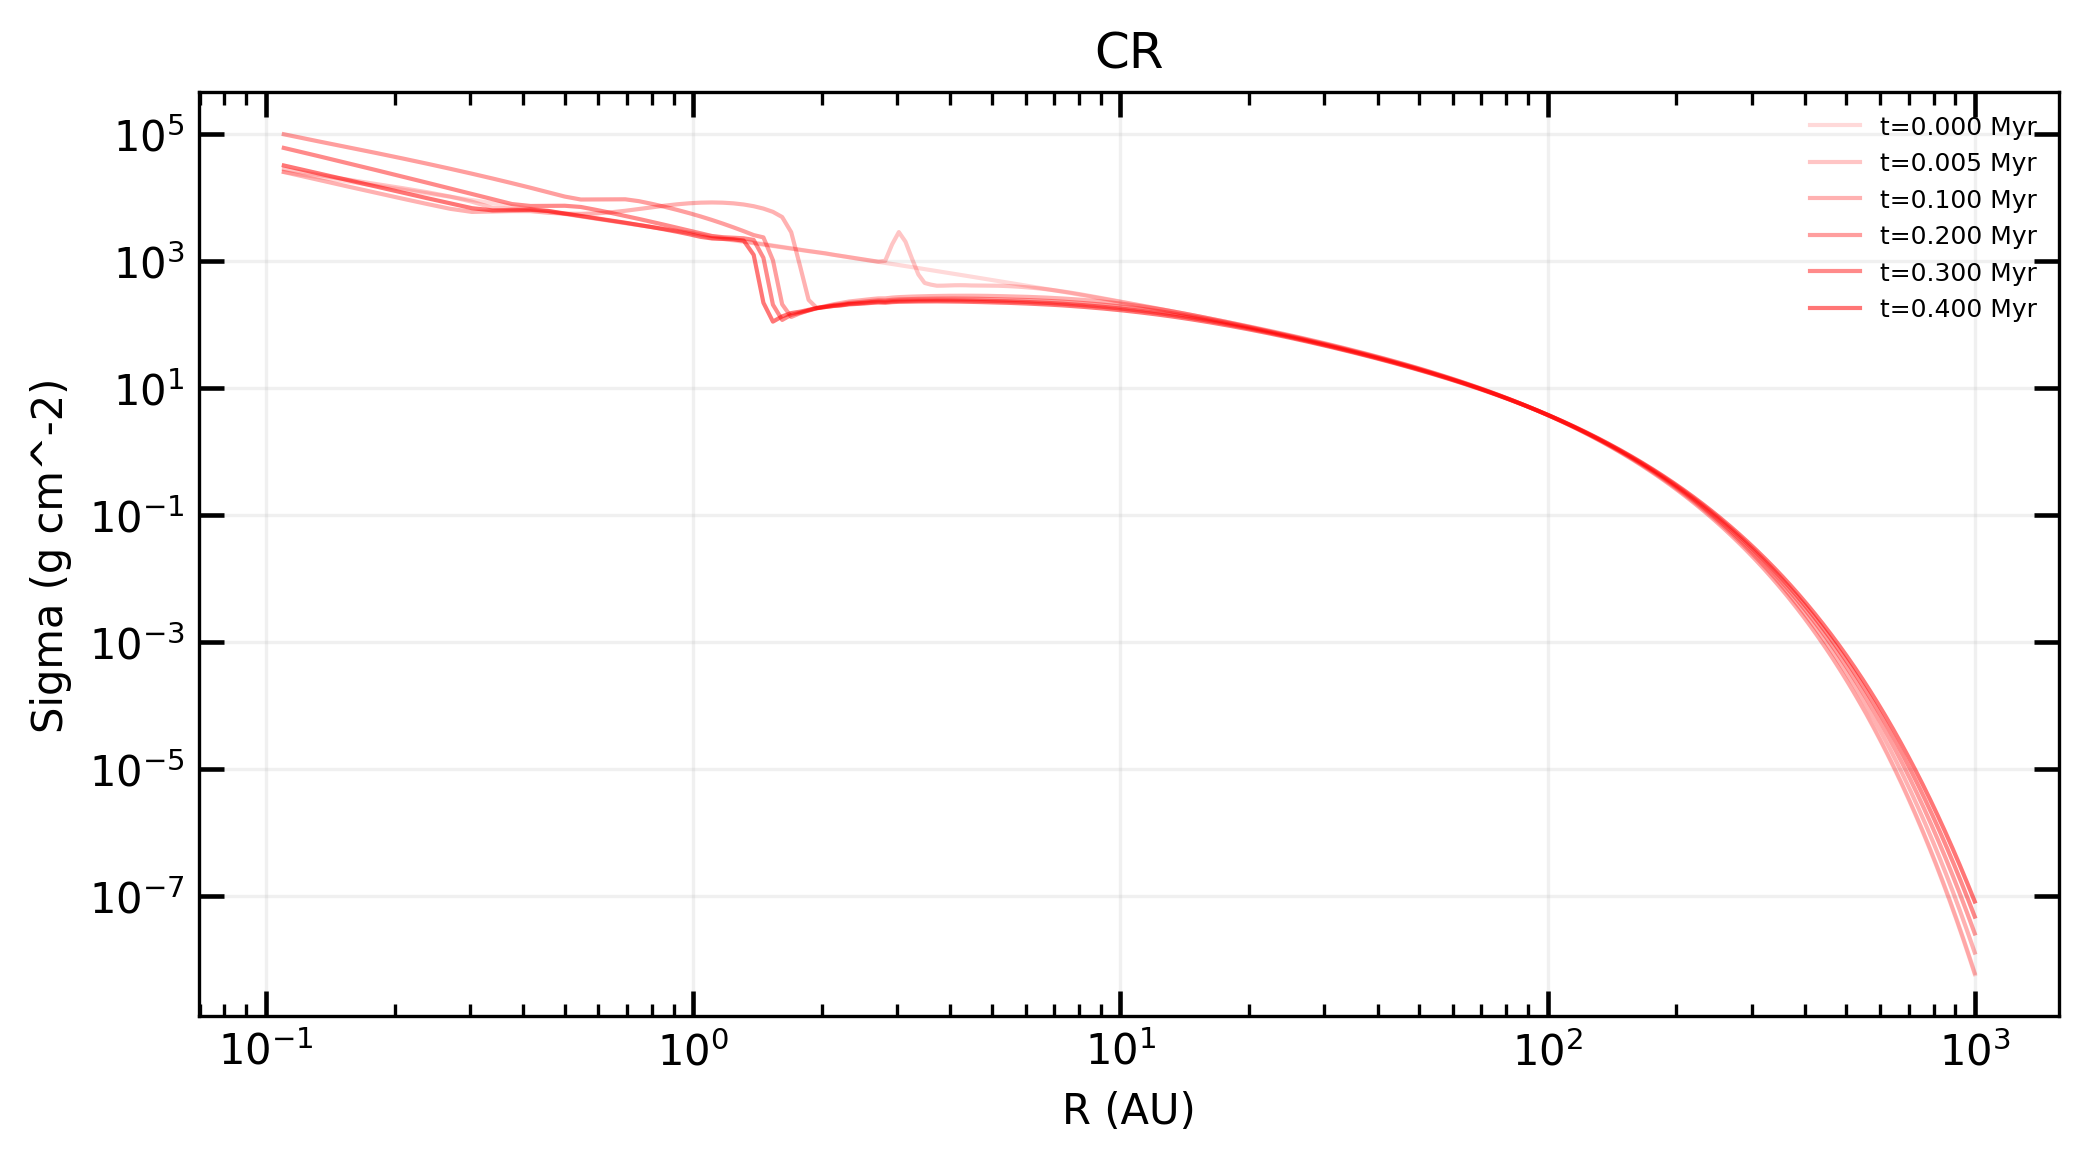

In [33]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('CR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crSigma_g
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

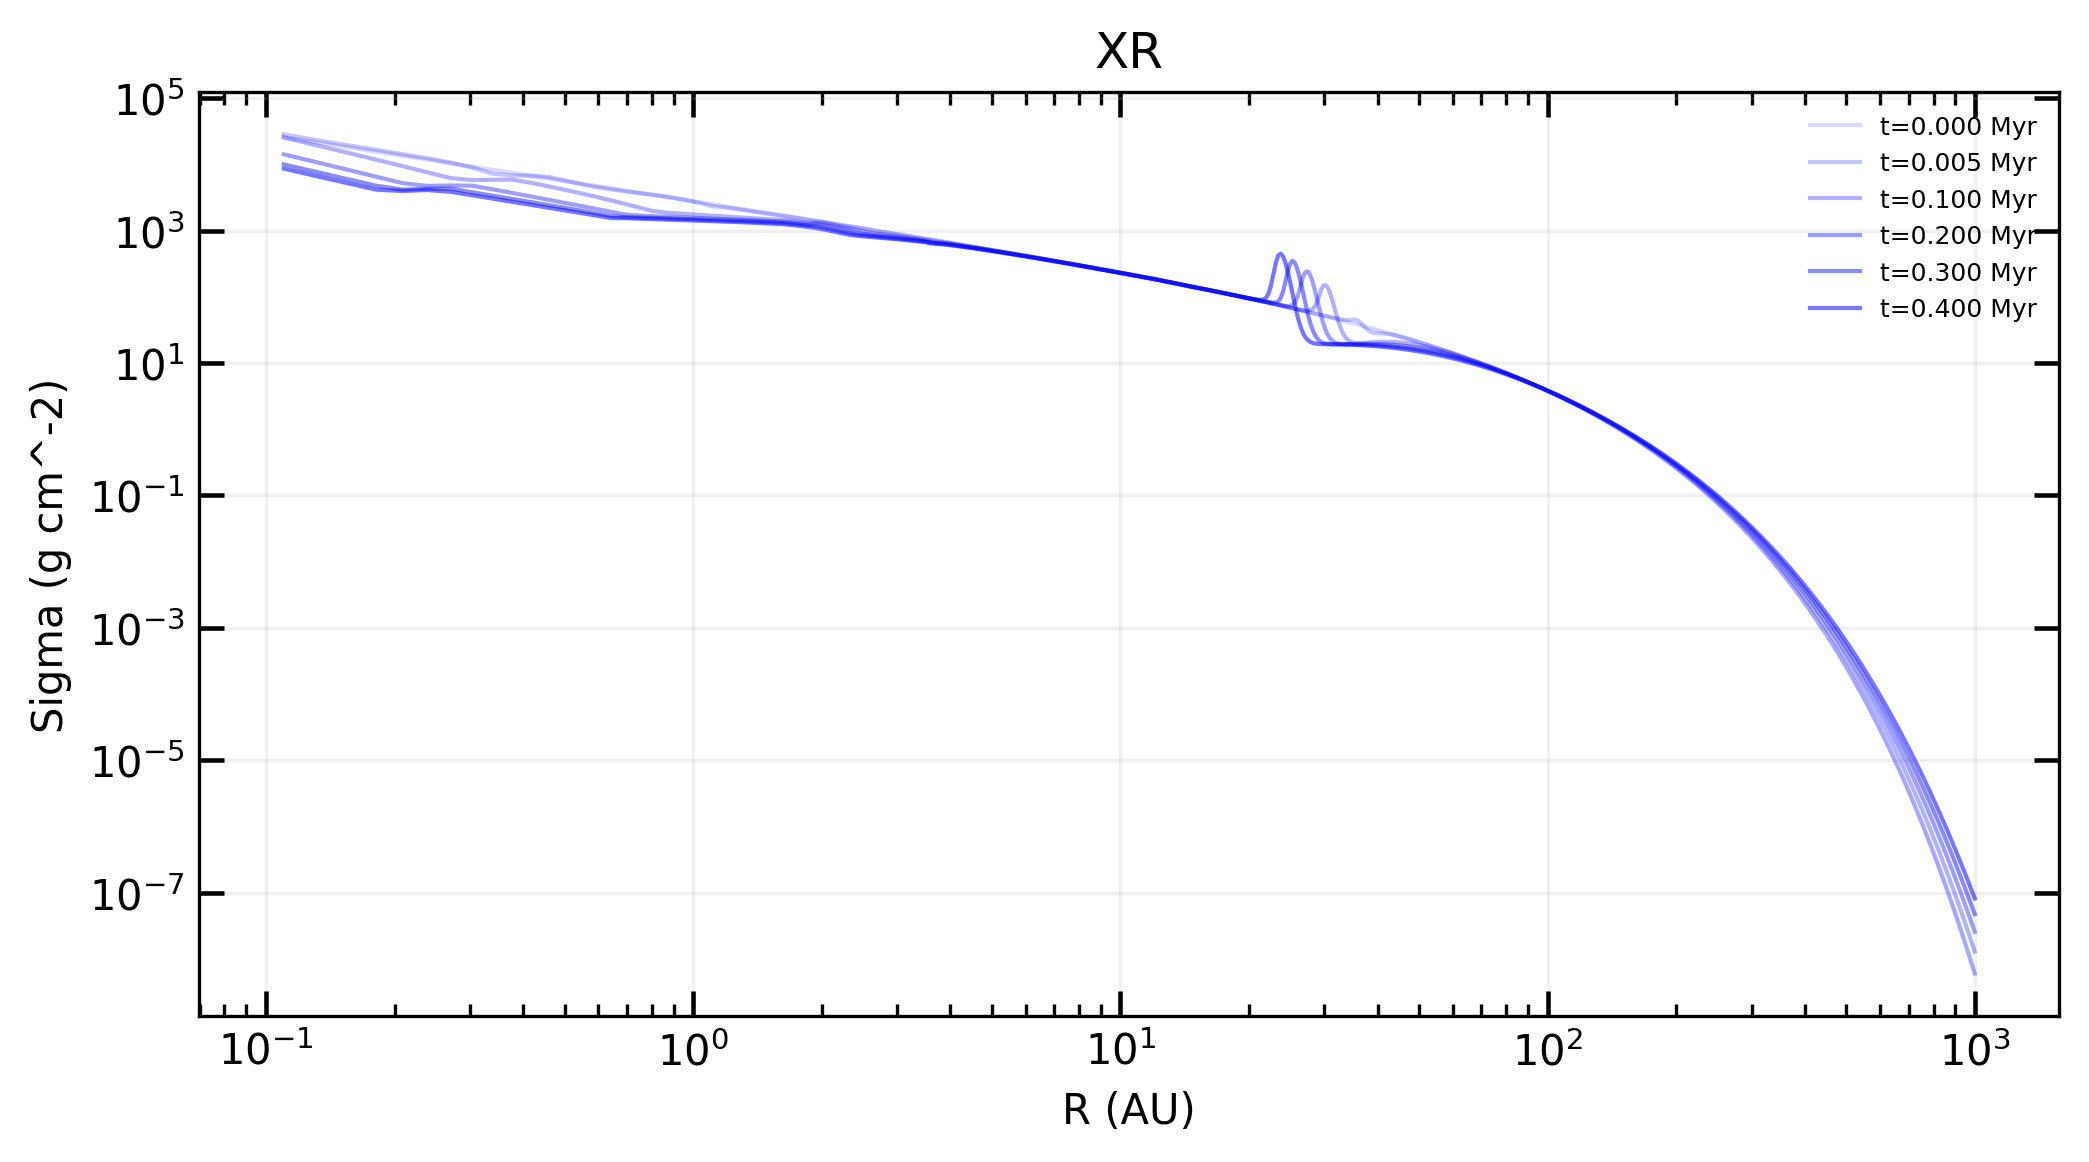

In [34]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrSigma_g
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

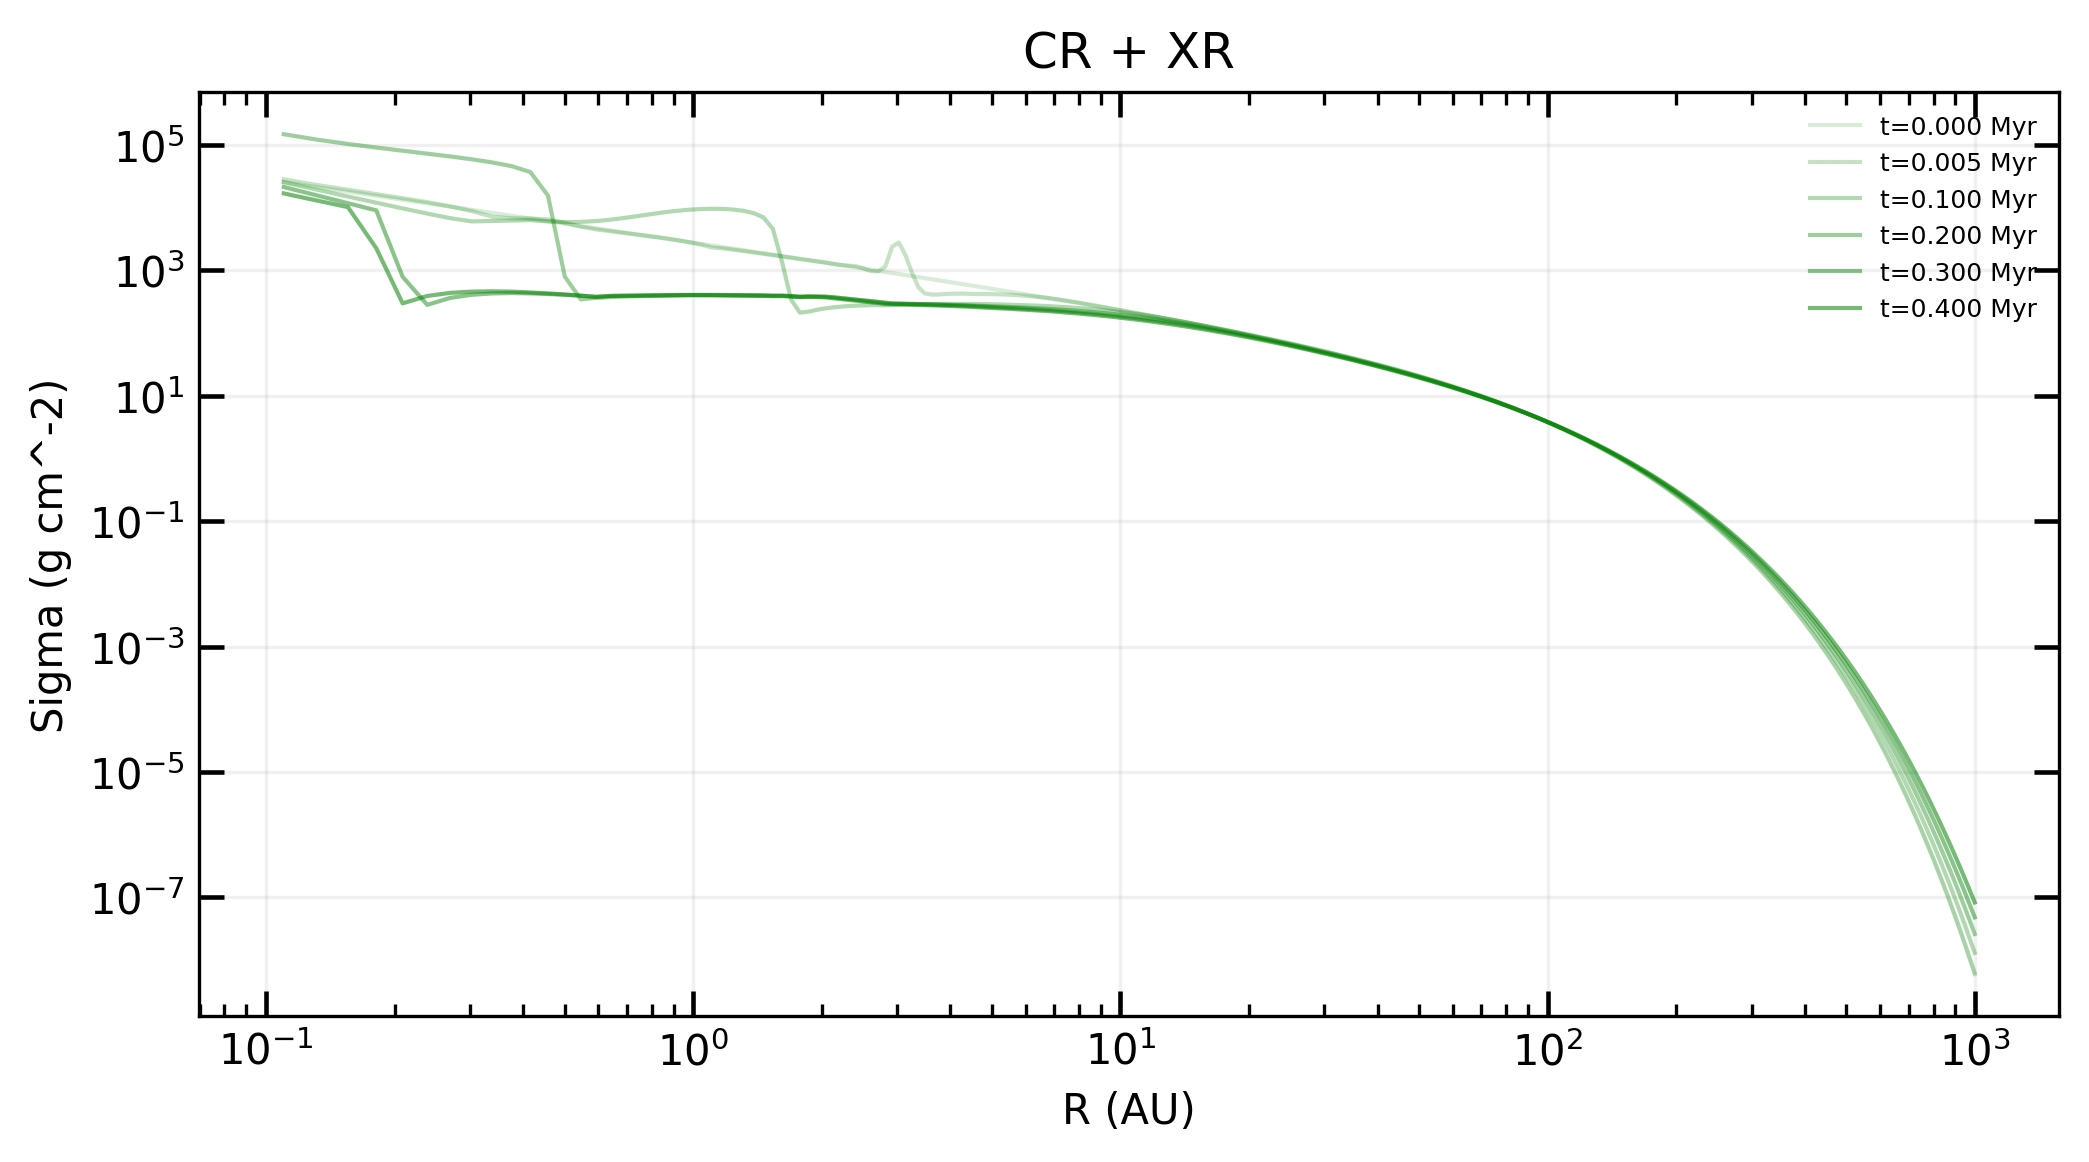

In [35]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxSigma_g
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

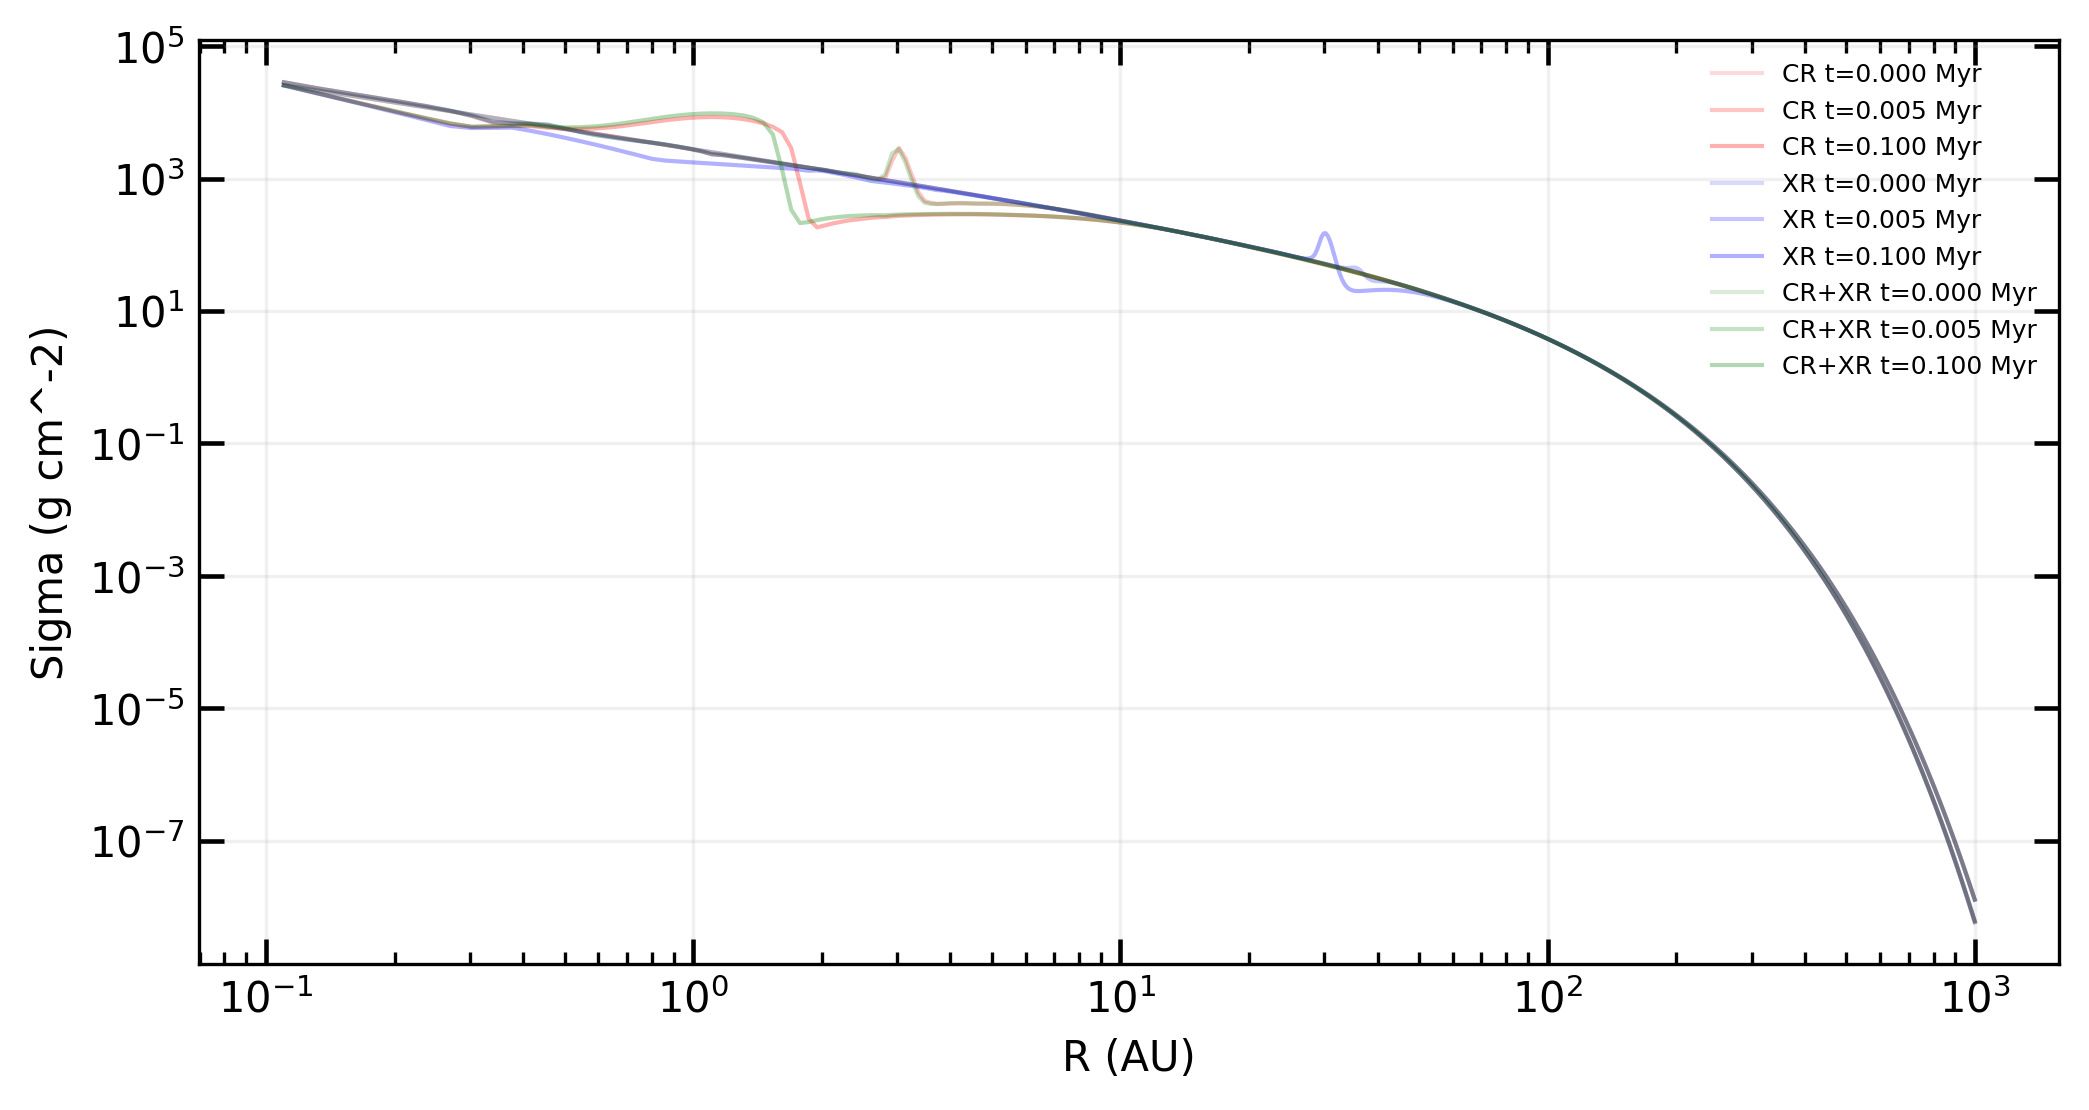

In [36]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

ran = range(0,3)

xdata = crR
ydata = crSigma_g
for a_i, i in enumerate(ran):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"CR t={crtsnap[i]:.3f} Myr", lw = 1.0)

xdata = xrR
ydata = xrSigma_g
for a_i, i in enumerate(ran):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"XR t={xrtsnap[i]:.3f} Myr", lw = 1.0)

xdata = cxR
ydata = cxSigma_g
for a_i, i in enumerate(ran):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"CR+XR t={cxtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# alpha

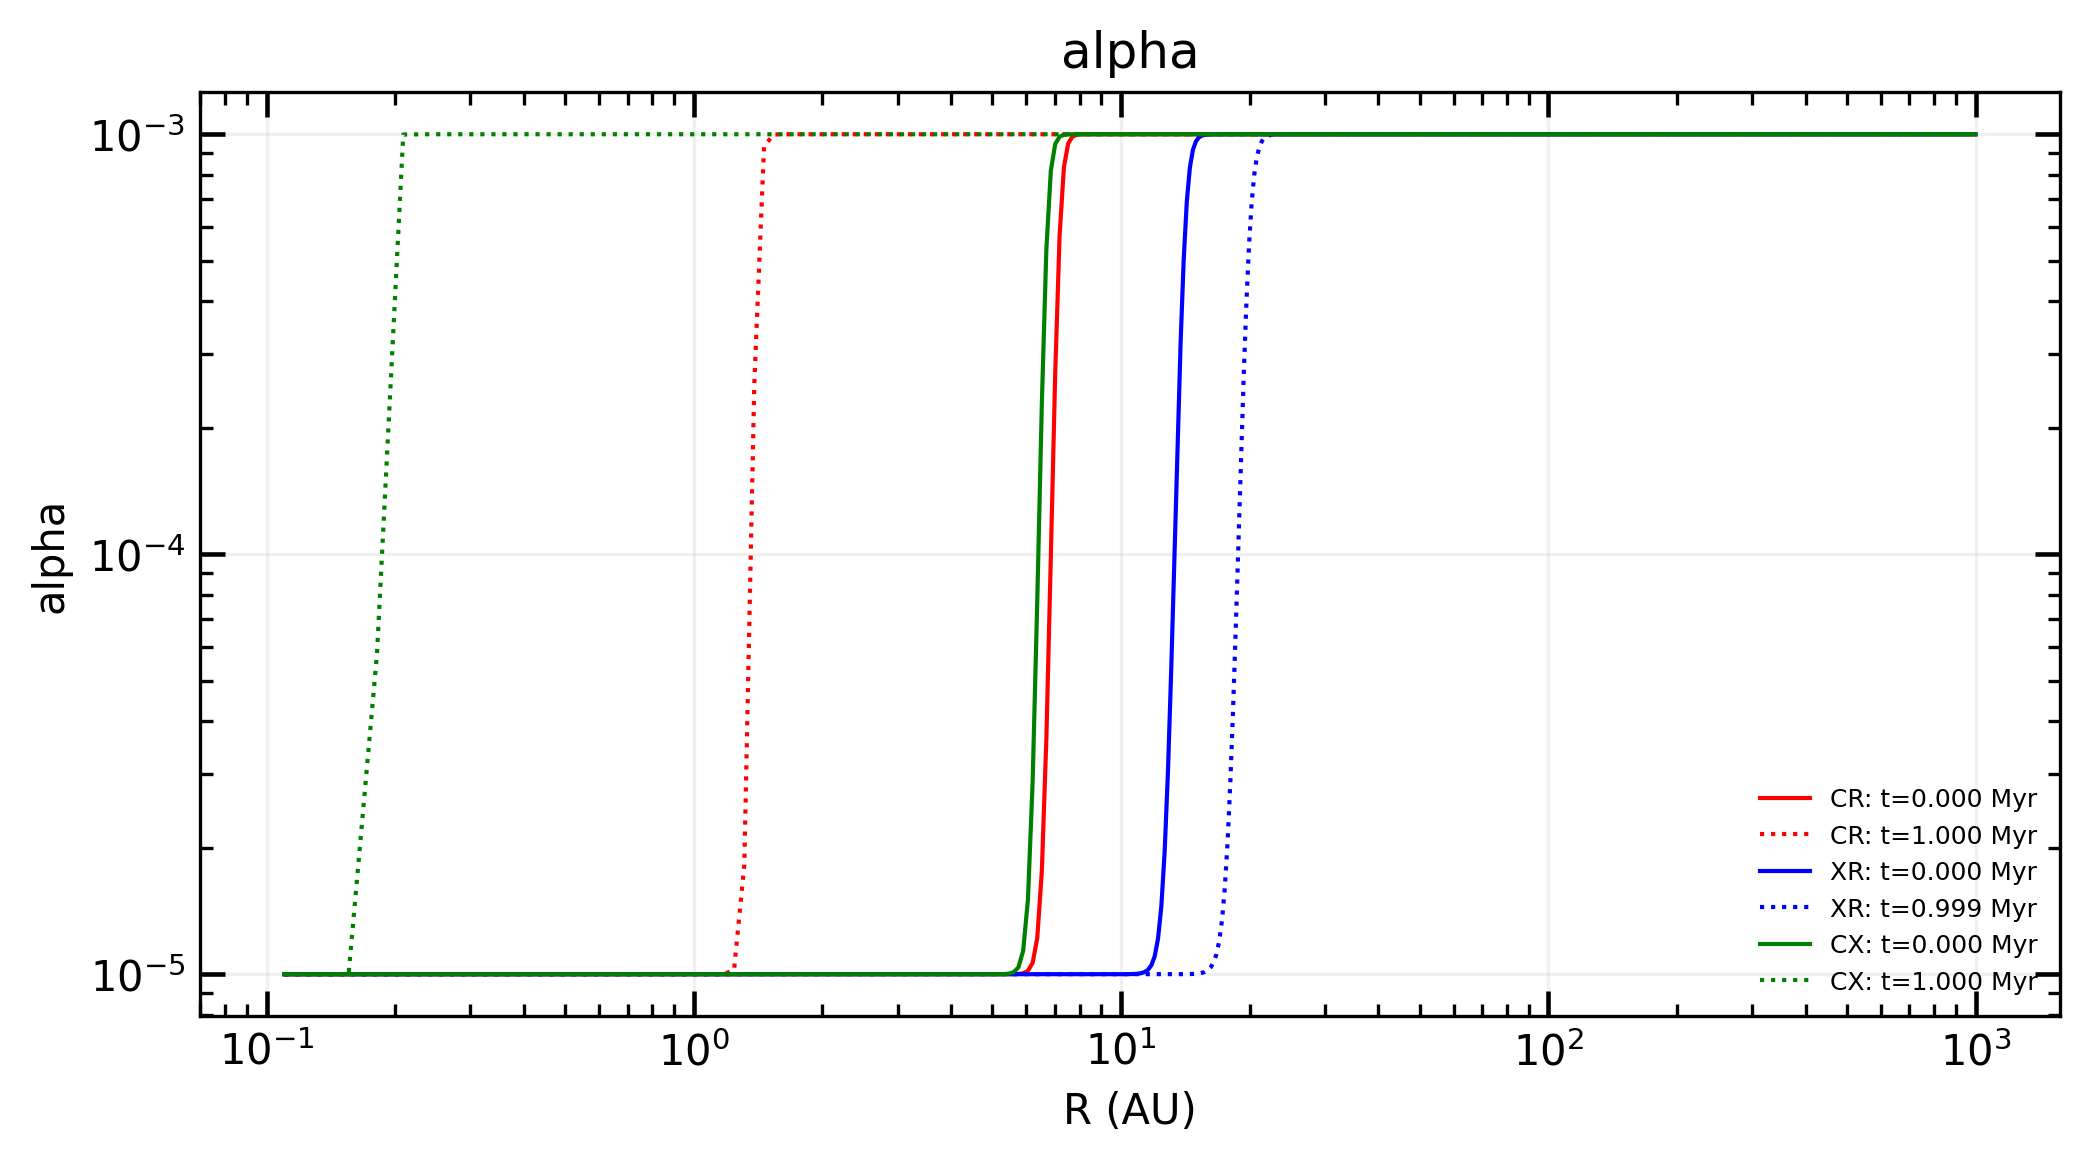

In [37]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('alpha')
plt.title('alpha')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-5,1e-3)

ax.loglog(crR, cralpha[0], linestyle='solid', color='red', label=rf"CR: t={crt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, cralpha[-1], linestyle='dotted', color='red', label=rf"CR: t={crt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xralpha[0], linestyle='solid', color='blue', label=rf"XR: t={xrt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xralpha[-1], linestyle='dotted', color='blue', label=rf"XR: t={xrt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxalpha[0], linestyle='solid', color='green', label=rf"CX: t={cxt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxalpha[-1], linestyle='dotted', color='green', label=rf"CX: t={cxt[-1]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

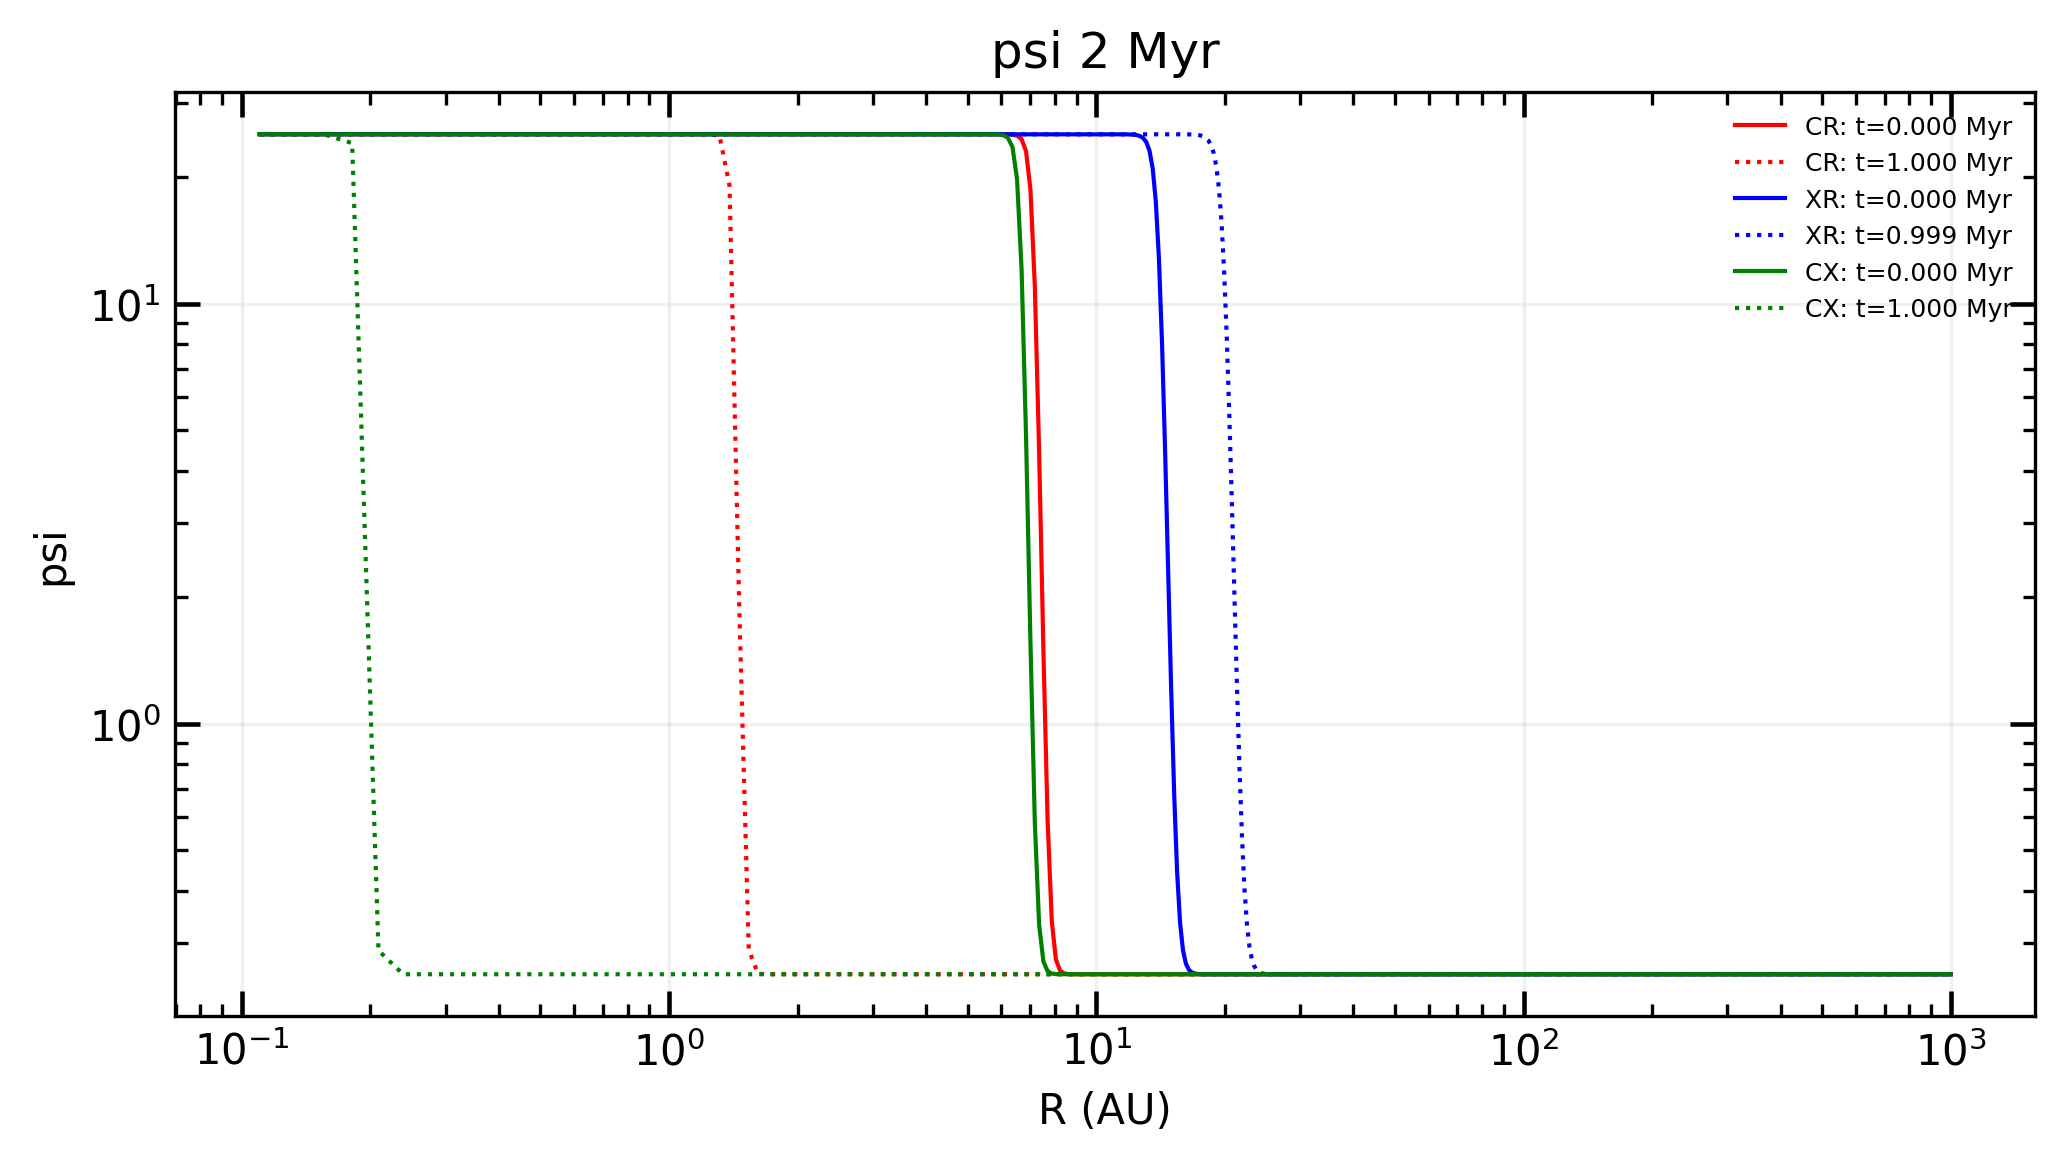

In [38]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('psi')
plt.title('psi 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-5,1e-3)

ax.loglog(crR, crpsi[0], linestyle='solid', color='red', label=rf"CR: t={crt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crpsi[-1], linestyle='dotted', color='red', label=rf"CR: t={crt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrpsi[0], linestyle='solid', color='blue', label=rf"XR: t={xrt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrpsi[-1], linestyle='dotted', color='blue', label=rf"XR: t={xrt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxpsi[0], linestyle='solid', color='green', label=rf"CX: t={cxt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxpsi[-1], linestyle='dotted', color='green', label=rf"CX: t={cxt[-1]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

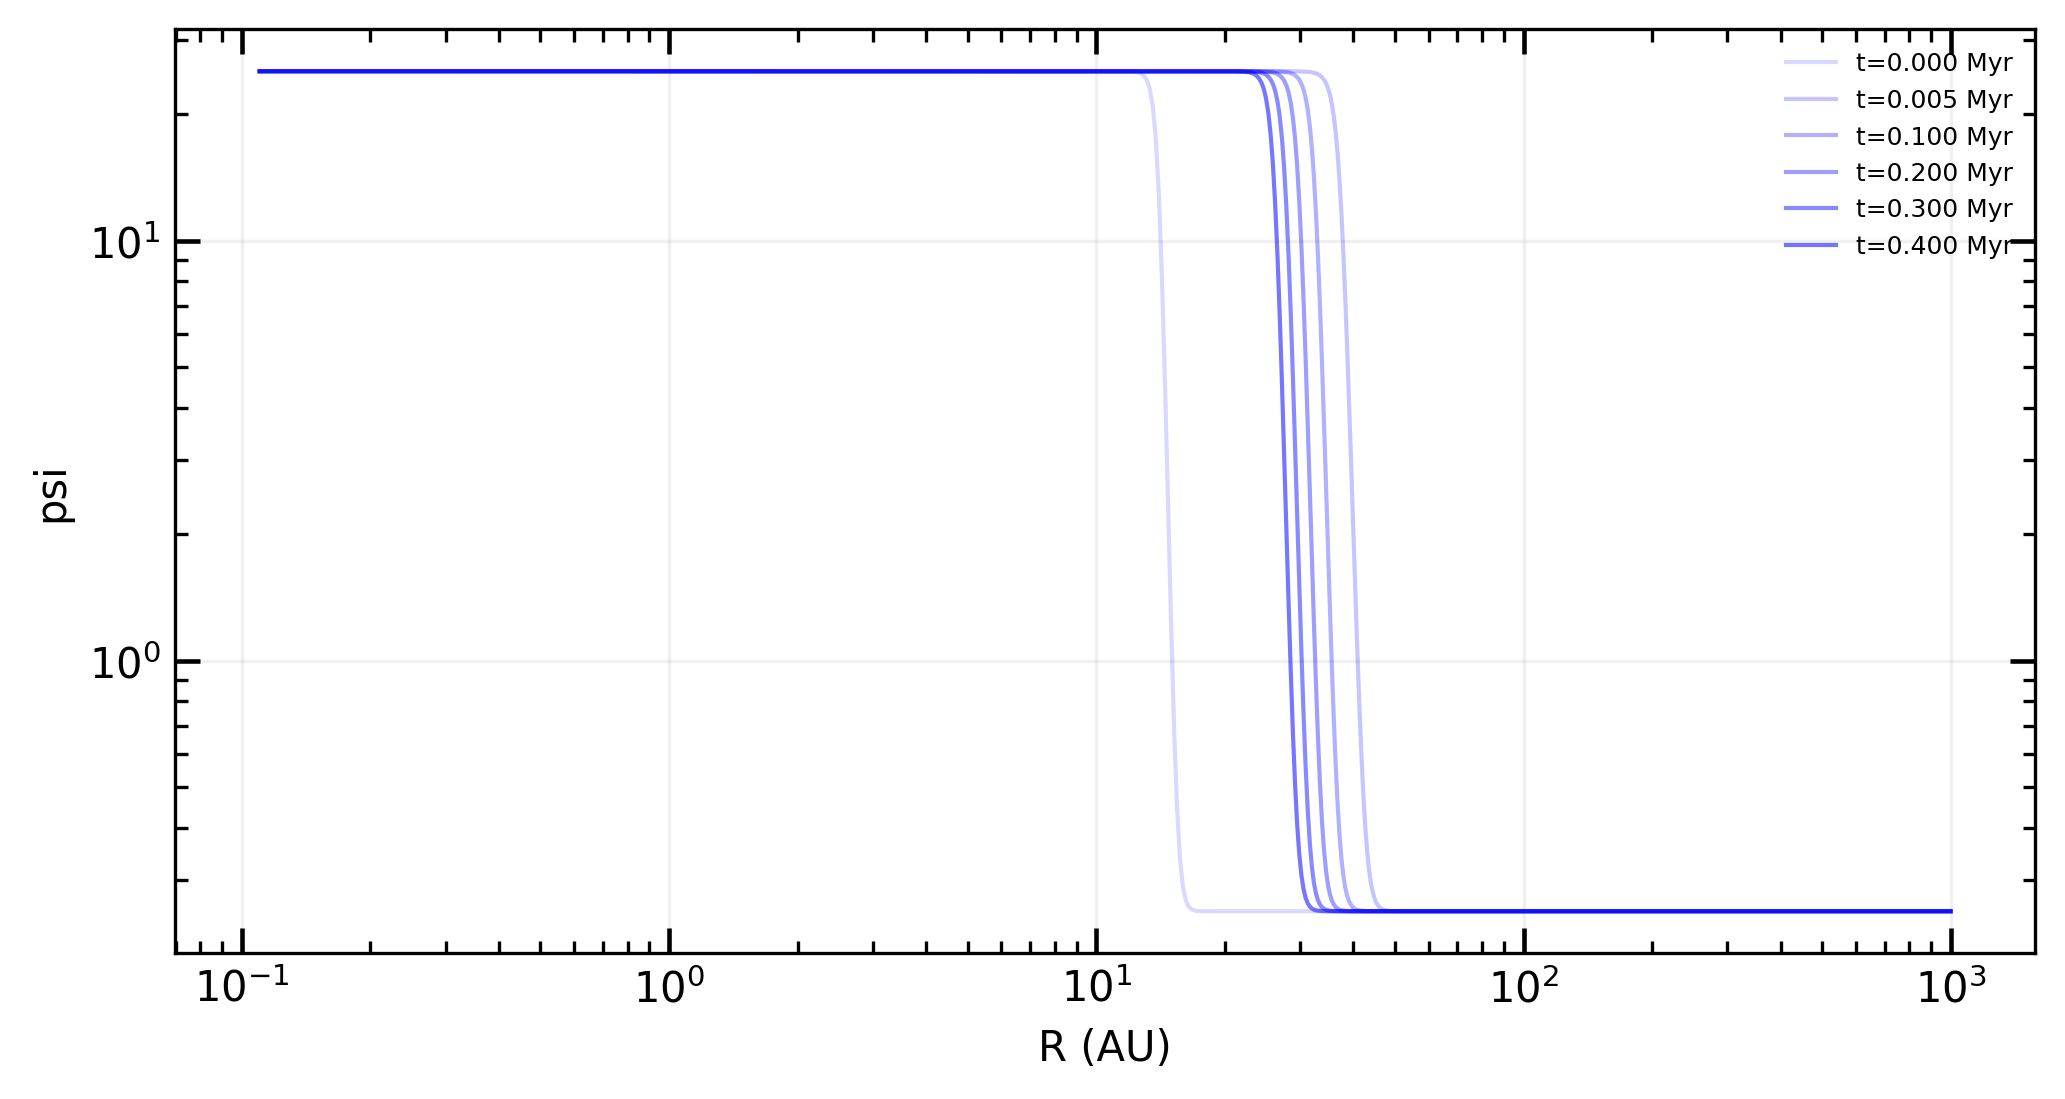

In [39]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('psi')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrpsi
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Temperature

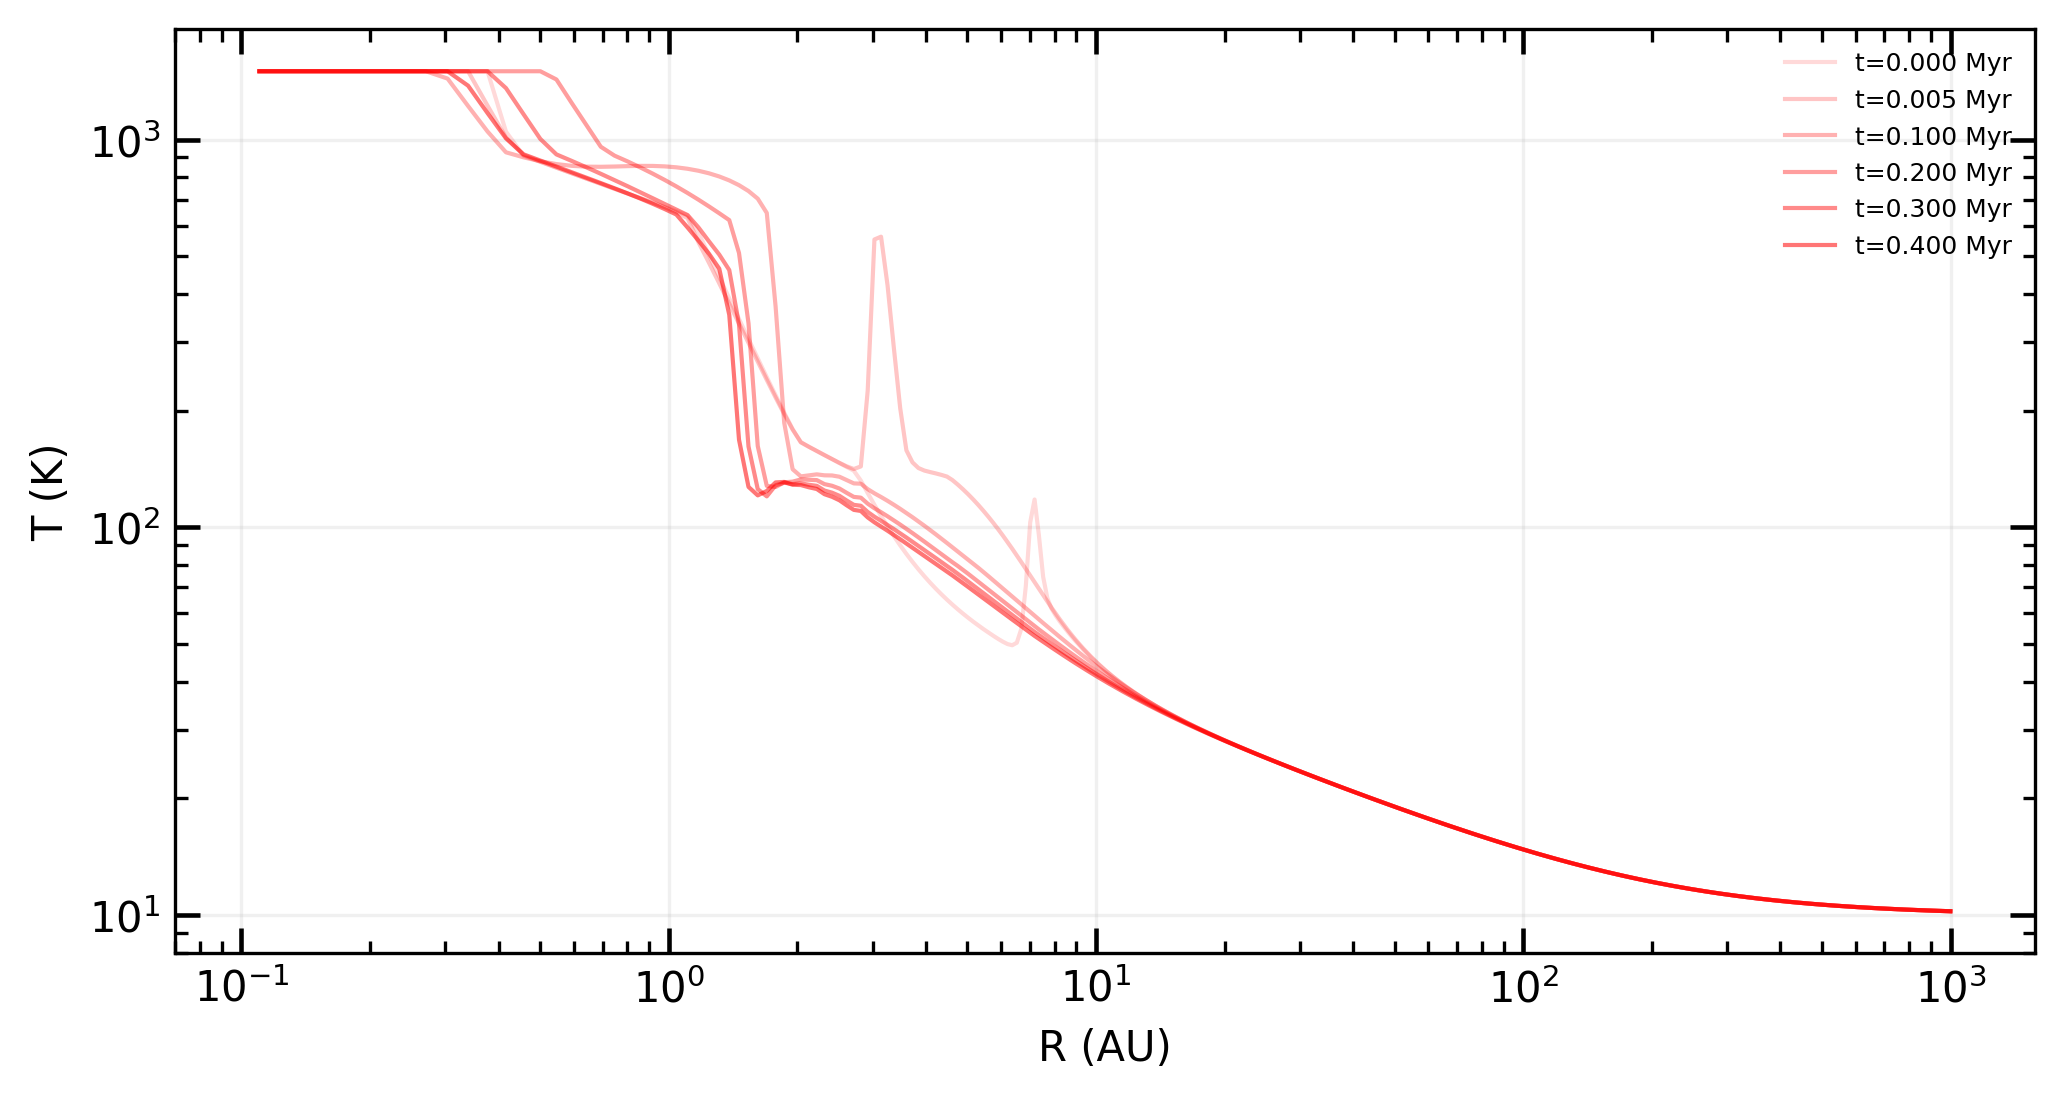

In [40]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('T (K)')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crT
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# M dot

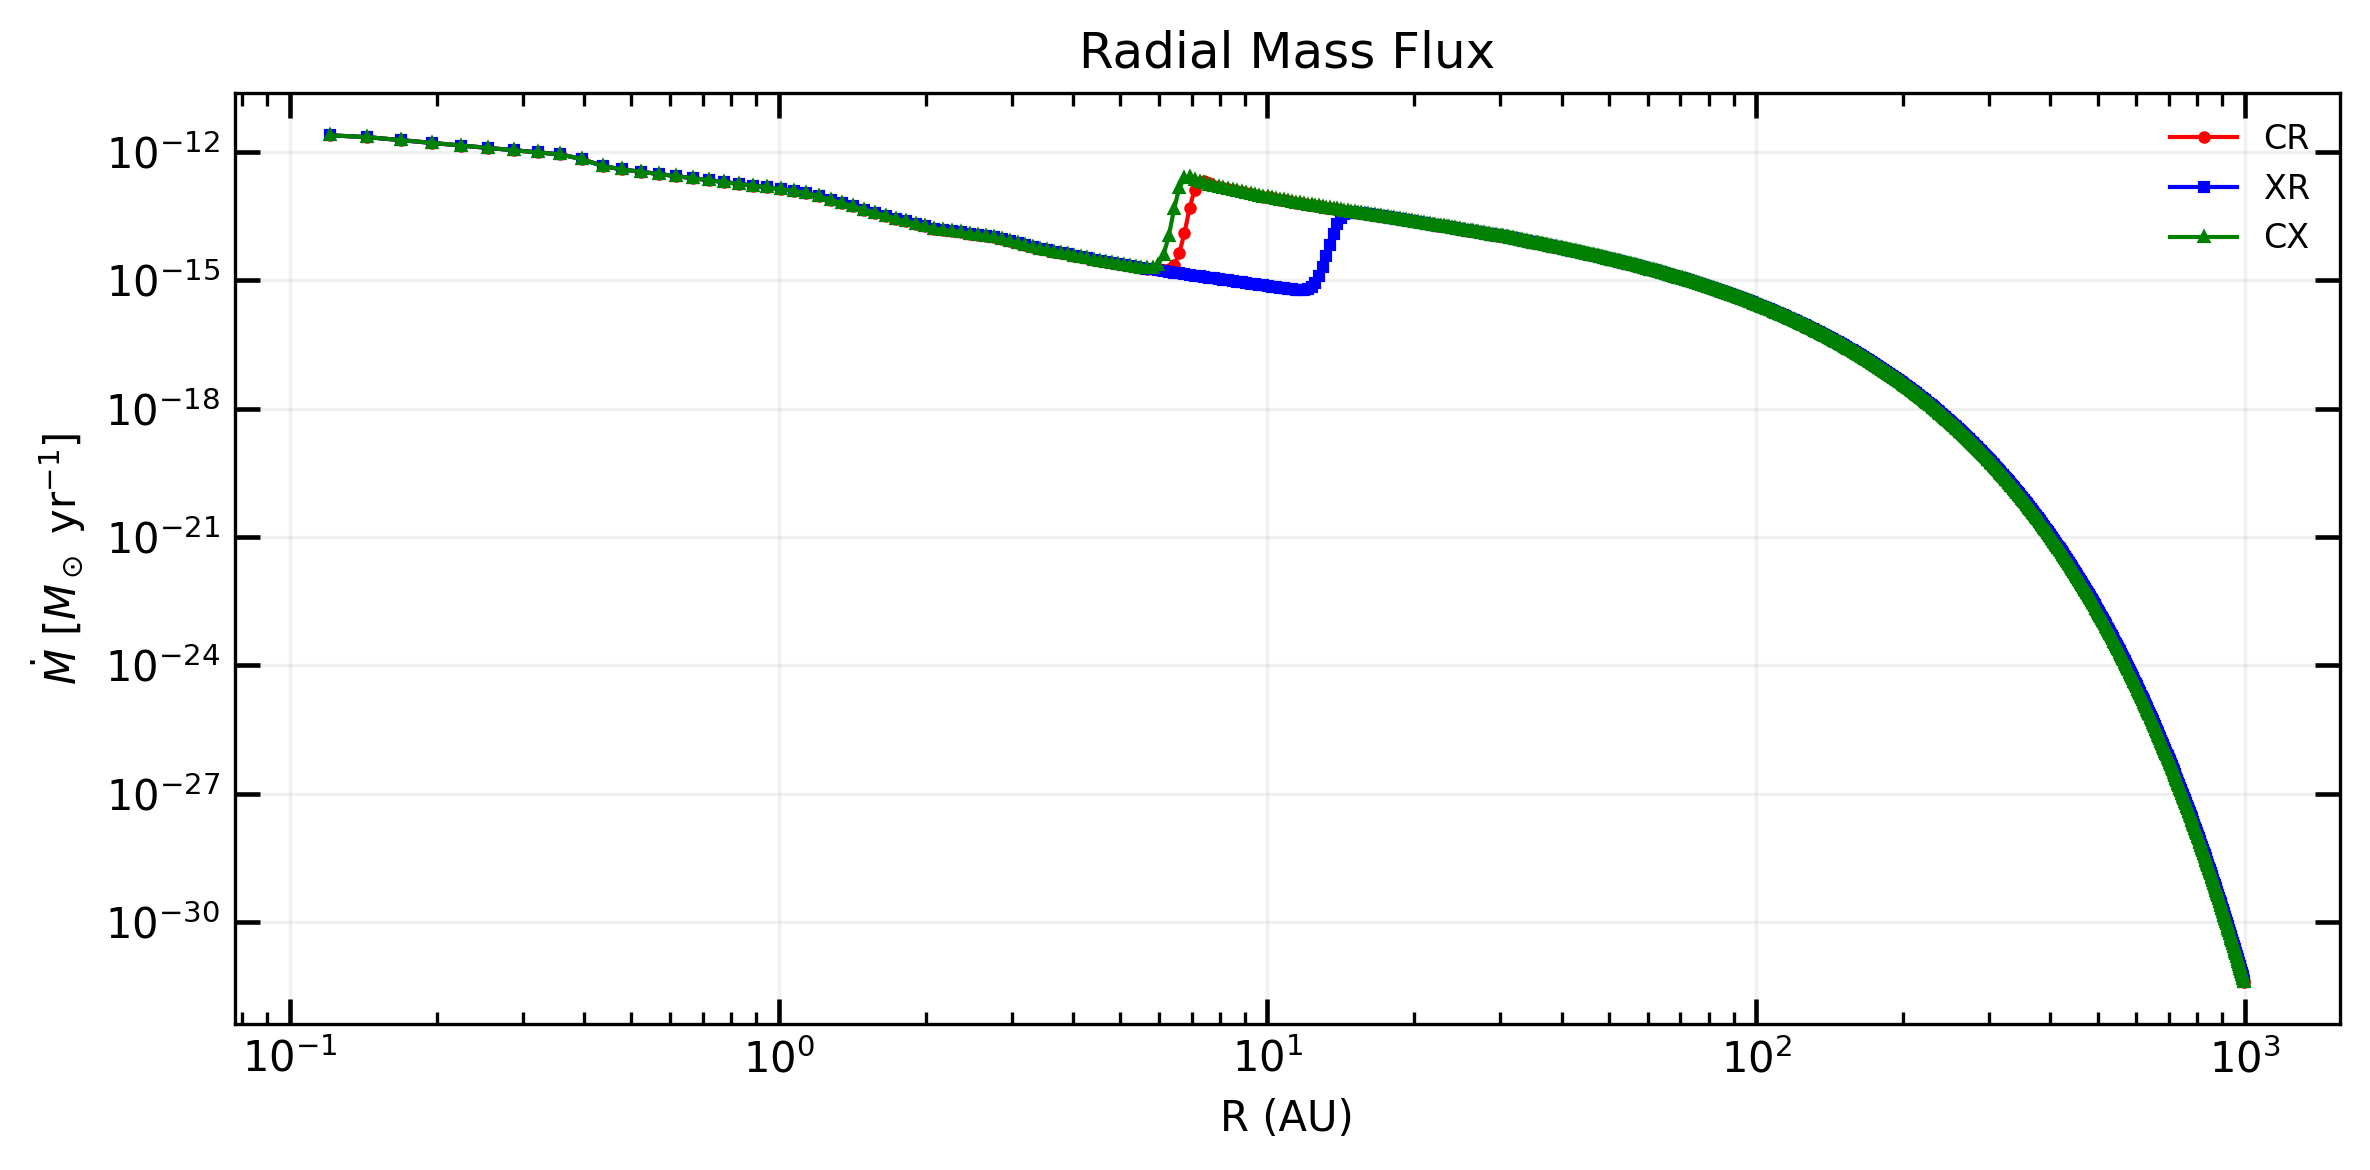

In [41]:
def compute_mdot_r_from_sigma_alpha(R, Sigma_G, alpha_R, T, mu=2.4):
    """
    Reconstruct Mdot_r from surface density, alpha, and temperature.
    
    Returns Mdot at cell faces (Msun/yr).
    """
    from DiscEvolution.constants import GasConst, AU, Msun, yr as yr_code
    
    # Sound speed: c_s = sqrt(k_B T / (mu * m_p))
    k_B = 1.380649e-16  # erg/K
    m_p = 1.67262192e-24  # g
    c_s = np.sqrt(k_B * T / (mu * m_p))  # cm/s
    
    # Keplerian angular velocity
    G_cgs = 6.67430e-8  # cm^3 g^-1 s^-2
    M_star_g = 1.989e33  # 1 Msun in grams
    Omega_k = np.sqrt(G_cgs * M_star_g / (R * AU)**3)  # rad/s
    
    # Scale height
    H = c_s / Omega_k  # cm
    
    # Viscosity
    nu = alpha_R * c_s * H  # cm^2/s
    
    # Gradient of (Sigma * sqrt(R))
    d_SigmaSqrtR = np.gradient(Sigma_G * np.sqrt(R), R)
    
    # Radial velocity at cell centers
    v_r_center = -3.0 * nu / (2.0 * (R * AU)) * d_SigmaSqrtR  # cm/s
    
    # Average to cell faces
    v_r_faces = (v_r_center[:-1] + v_r_center[1:]) / 2.0
    Sigma_faces = (Sigma_G[:-1] + Sigma_G[1:]) / 2.0
    R_faces = (R[:-1] + R[1:]) / 2.0
    
    # Mdot = 2π R Σ v_r, convert to Msun/yr
    Mdot_r = -2.0 * np.pi * (R_faces * AU) * Sigma_faces * v_r_faces * (yr_code / Msun)
    
    return R_faces, Mdot_r

# Compute for each model at a single snapshot
R_faces_cr, Mdot_r_cr = compute_mdot_r_from_sigma_alpha(crR, crSigma_g[0], cralpha[0], crT[0])
R_faces_xr, Mdot_r_xr = compute_mdot_r_from_sigma_alpha(xrR, xrSigma_g[0], xralpha[0], xrT[0])
R_faces_cx, Mdot_r_cx = compute_mdot_r_from_sigma_alpha(cxR, cxSigma_g[0], cxalpha[0], cxT[0])

# Plot
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')

ax.loglog(R_faces_cr, np.abs(Mdot_r_cr), 'o-', color='red', label='CR', ms=2, lw=1)
ax.loglog(R_faces_xr, np.abs(Mdot_r_xr), 's-', color='blue', label='XR', ms=2, lw=1)
ax.loglog(R_faces_cx, np.abs(Mdot_r_cx), '^-', color='green', label='CX', ms=2, lw=1)

ax.axhline(0, color='k', linestyle=':', lw=0.8)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

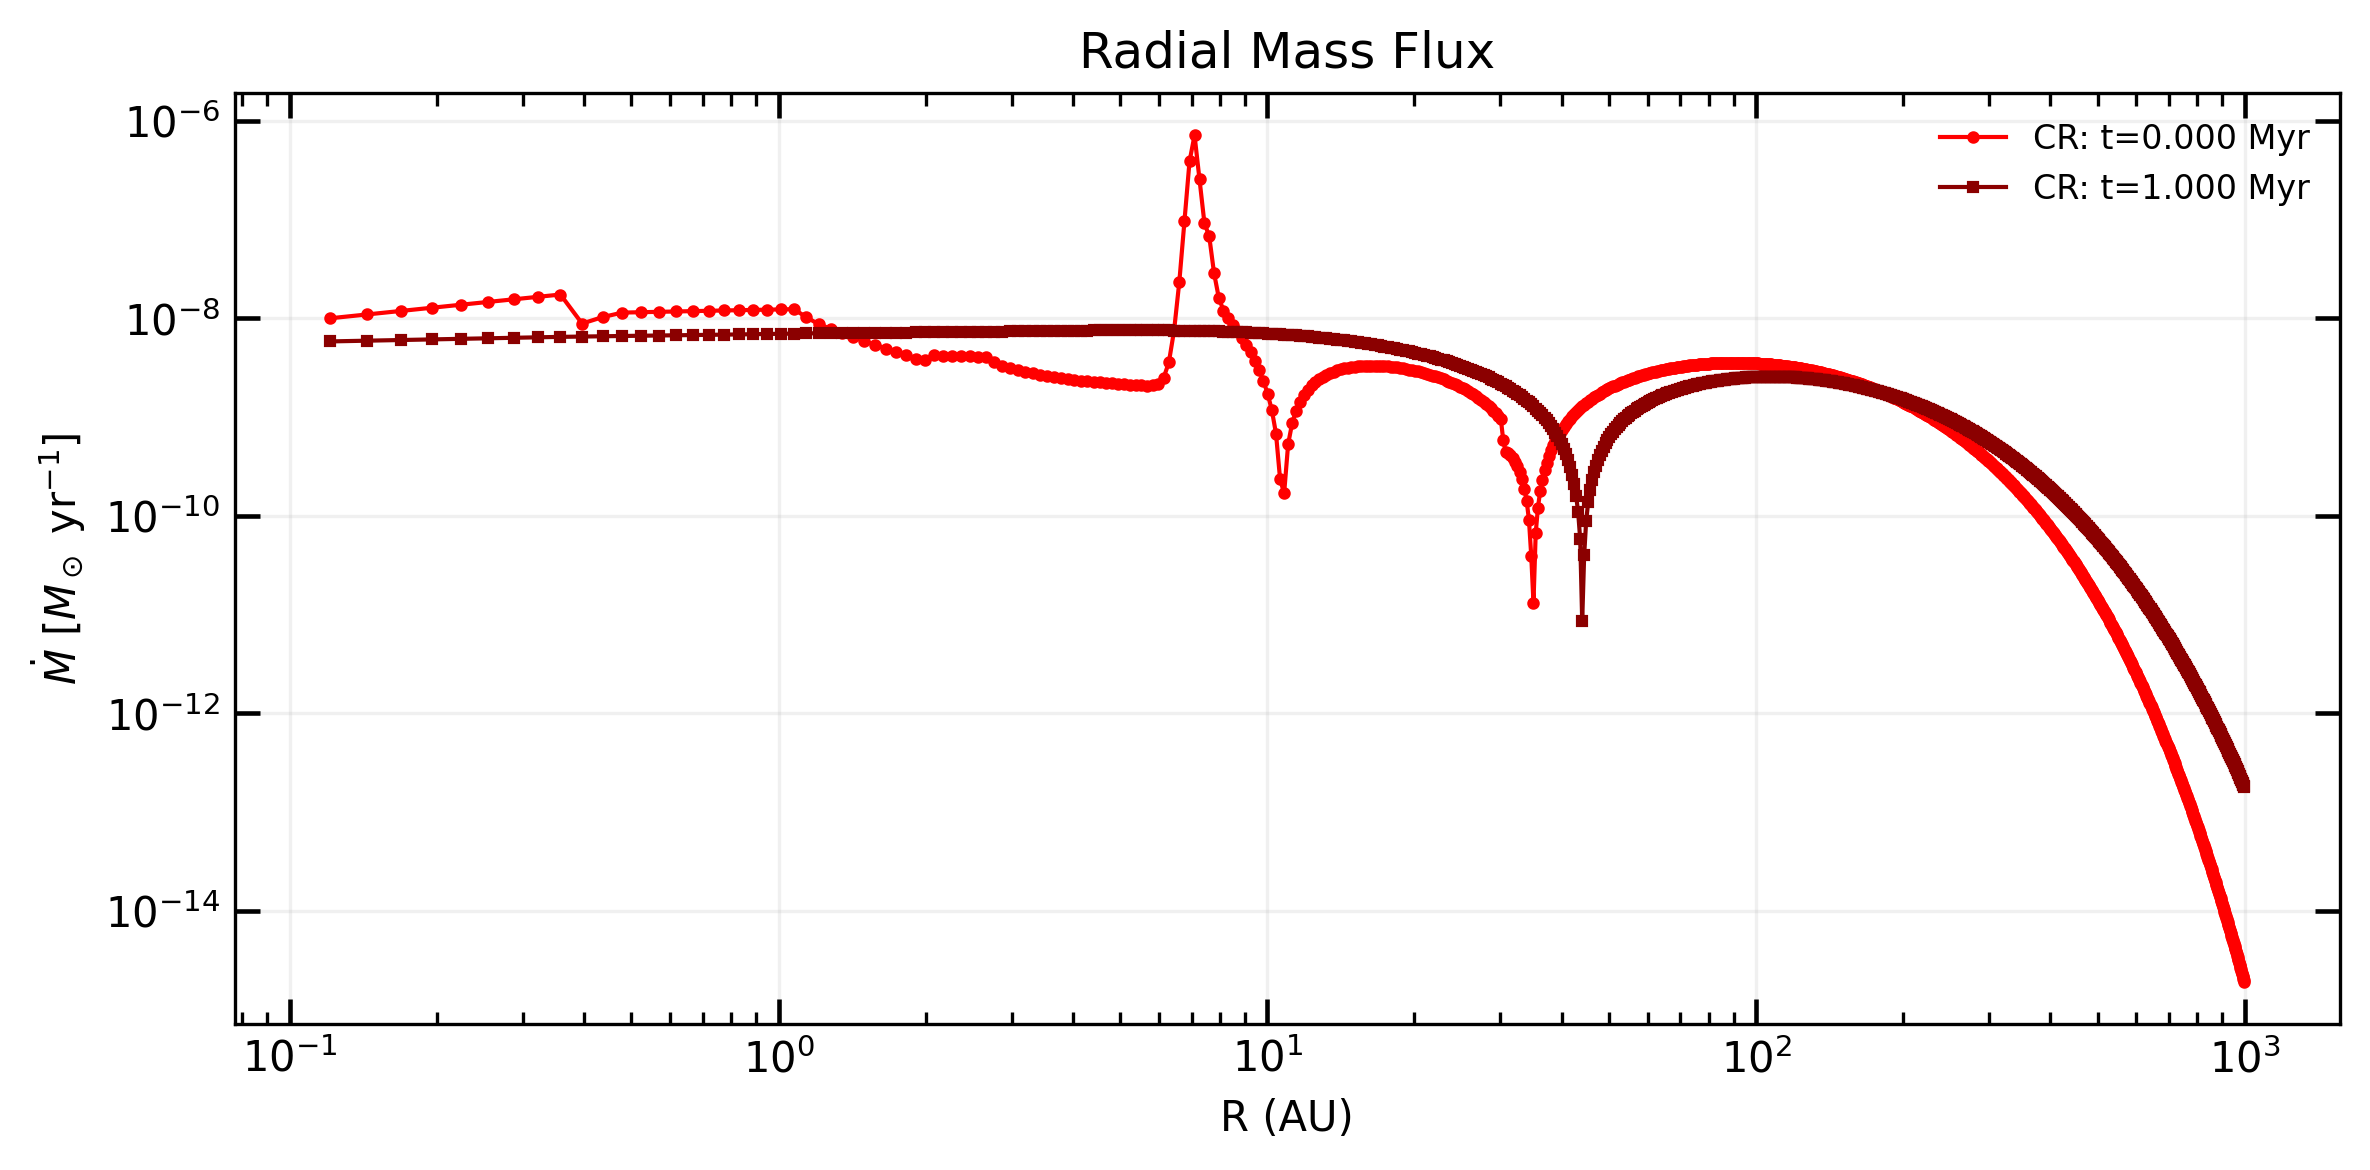

In [42]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')

ax.loglog(crR_faces, np.abs(crMdot_r[0]), 'o-', color='red', label=f'CR: t={crt[0]/1e6:.3f} Myr', ms=2, lw=1)
ax.loglog(crR_faces, np.abs(crMdot_r[-1]), 's-', color='darkred', label=f'CR: t={crt[-1]/1e6:.3f} Myr', ms=2, lw=1)

ax.axhline(0, color='k', linestyle=':', lw=0.8)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

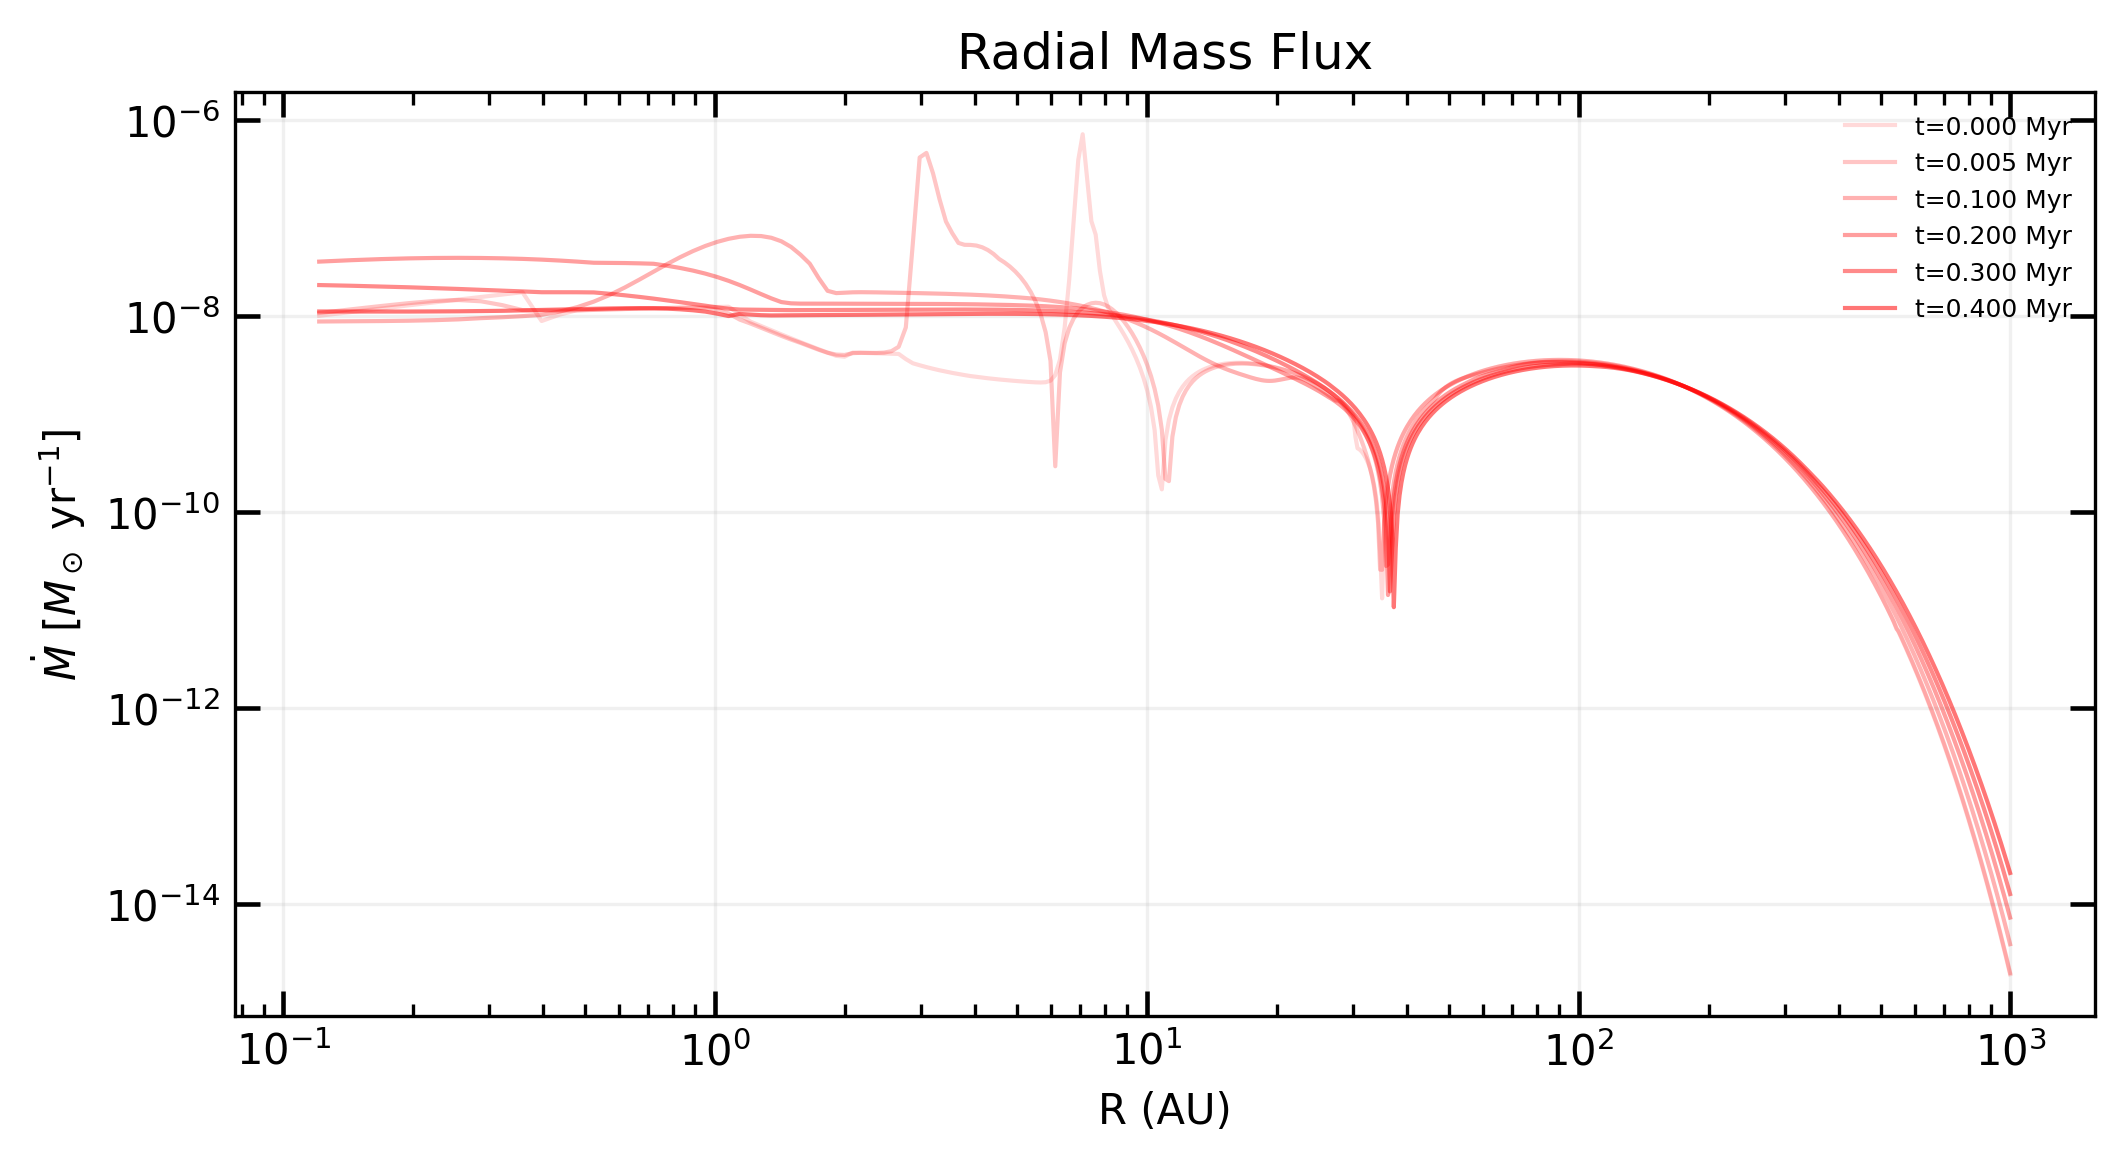

In [43]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR_faces
ydata = crMdot_r
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, np.abs(ydata[i]), linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

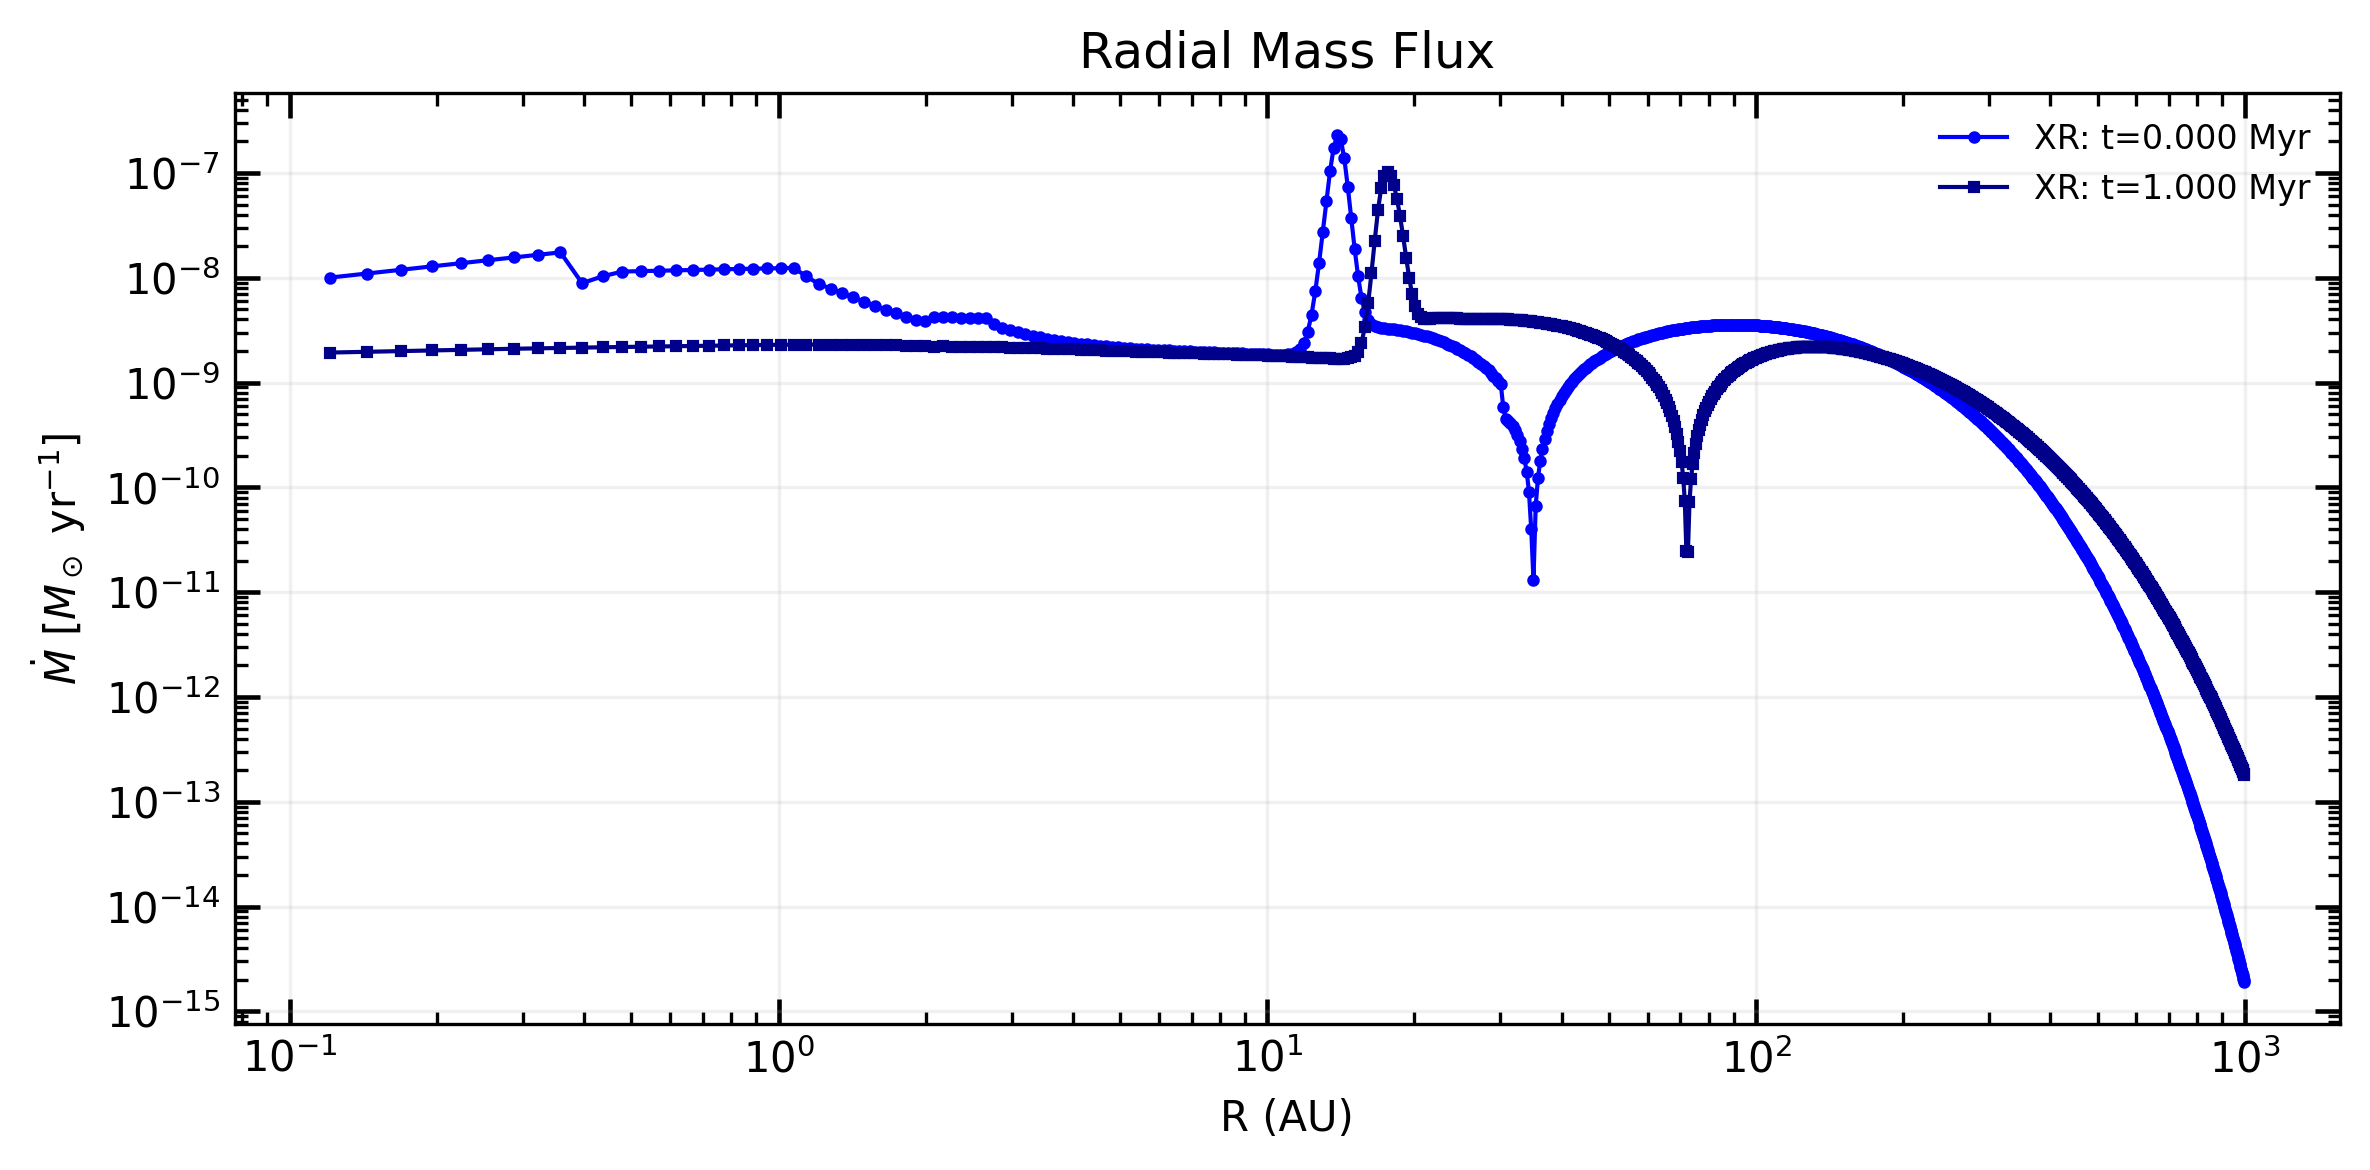

In [44]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')

ax.loglog(xrR_faces, np.abs(xrMdot_r[0]), 'o-', color='blue', label=f'XR: t={crt[0]/1e6:.3f} Myr', ms=2, lw=1)
ax.loglog(xrR_faces, np.abs(xrMdot_r[-1]), 's-', color='darkblue', label=f'XR: t={crt[-1]/1e6:.3f} Myr', ms=2, lw=1)

ax.axhline(0, color='k', linestyle=':', lw=0.8)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

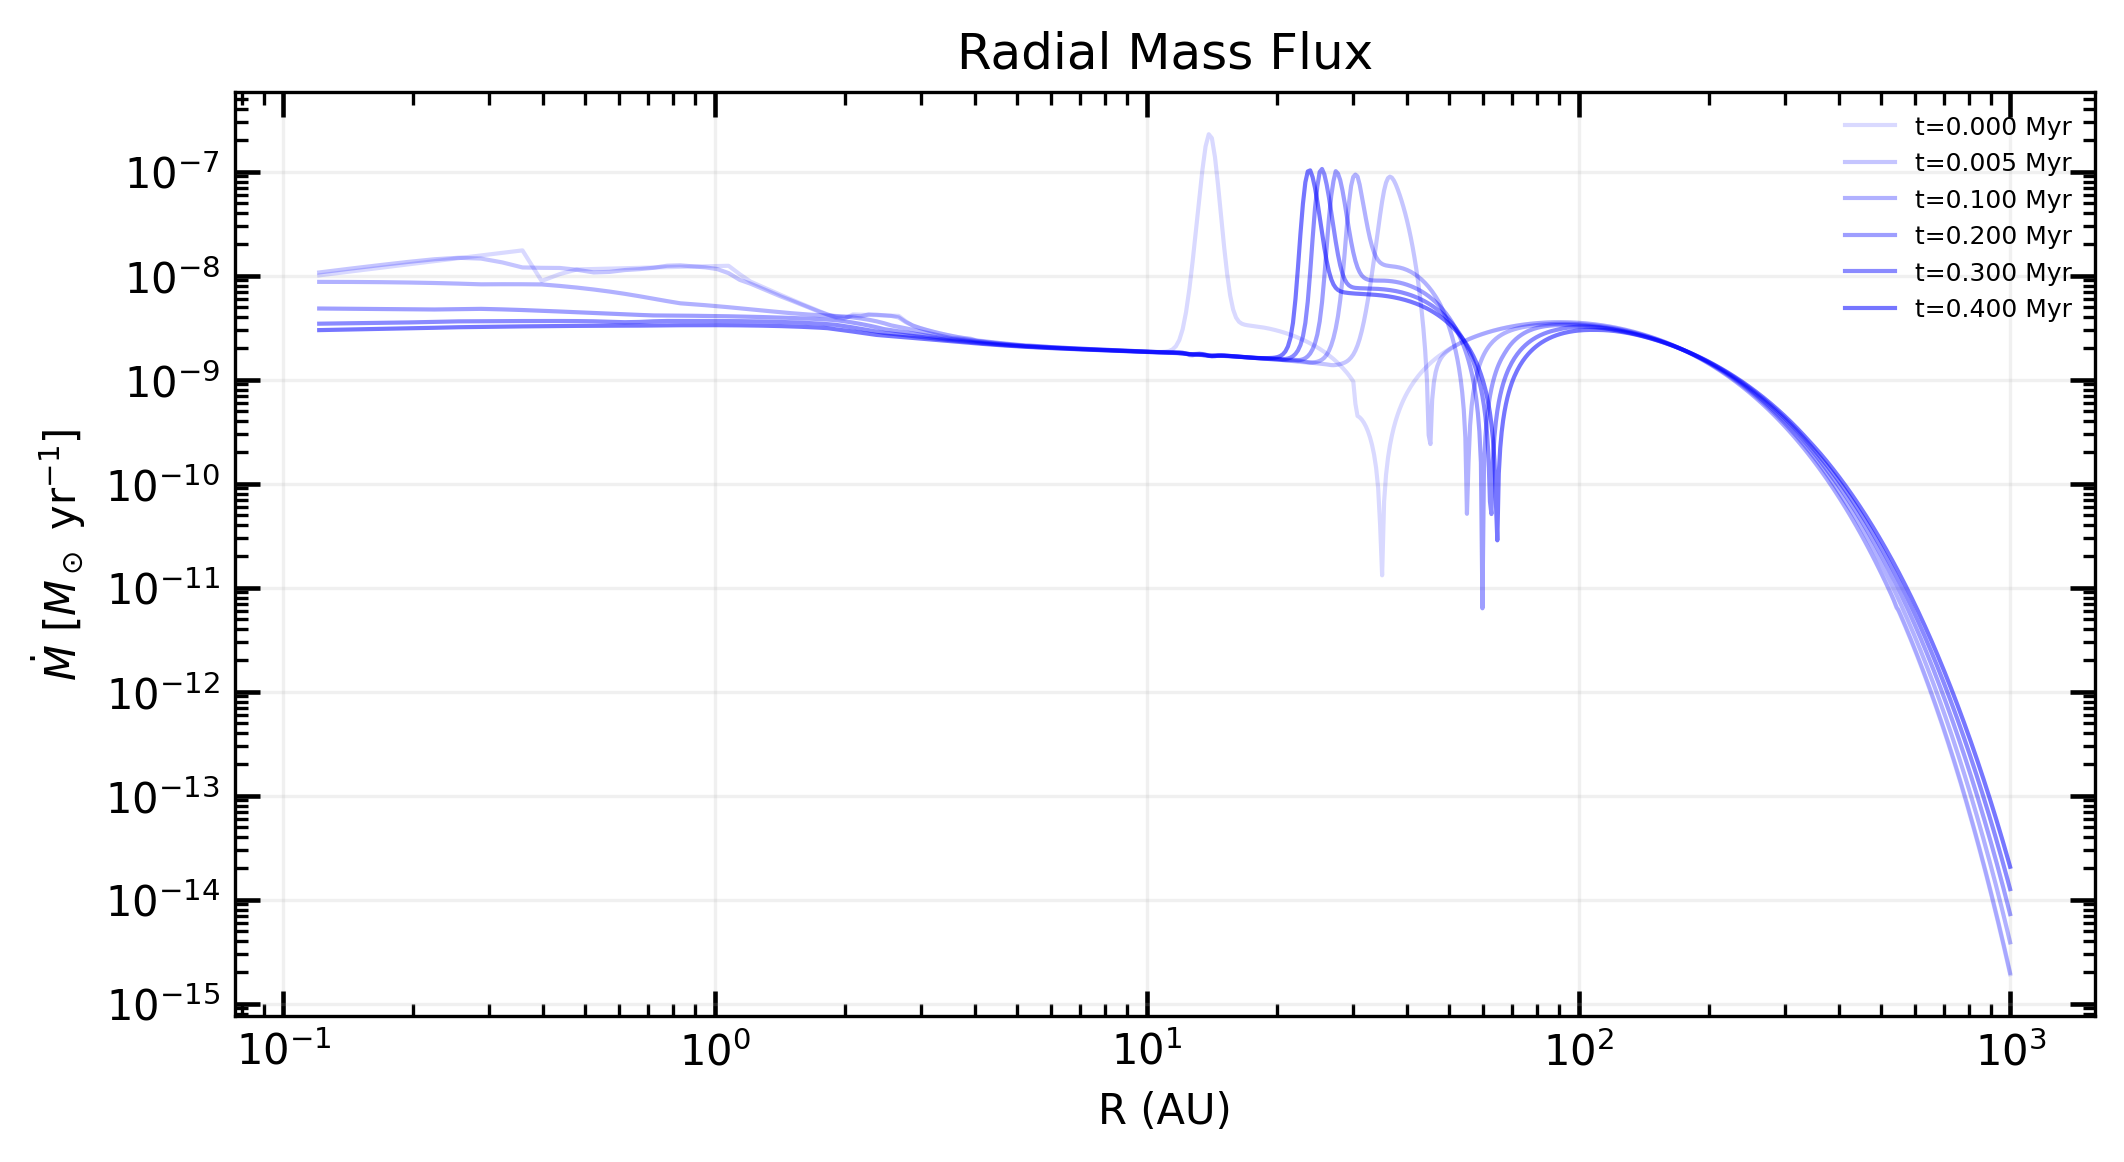

In [45]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR_faces
ydata = xrMdot_r
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, np.abs(ydata[i]), linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

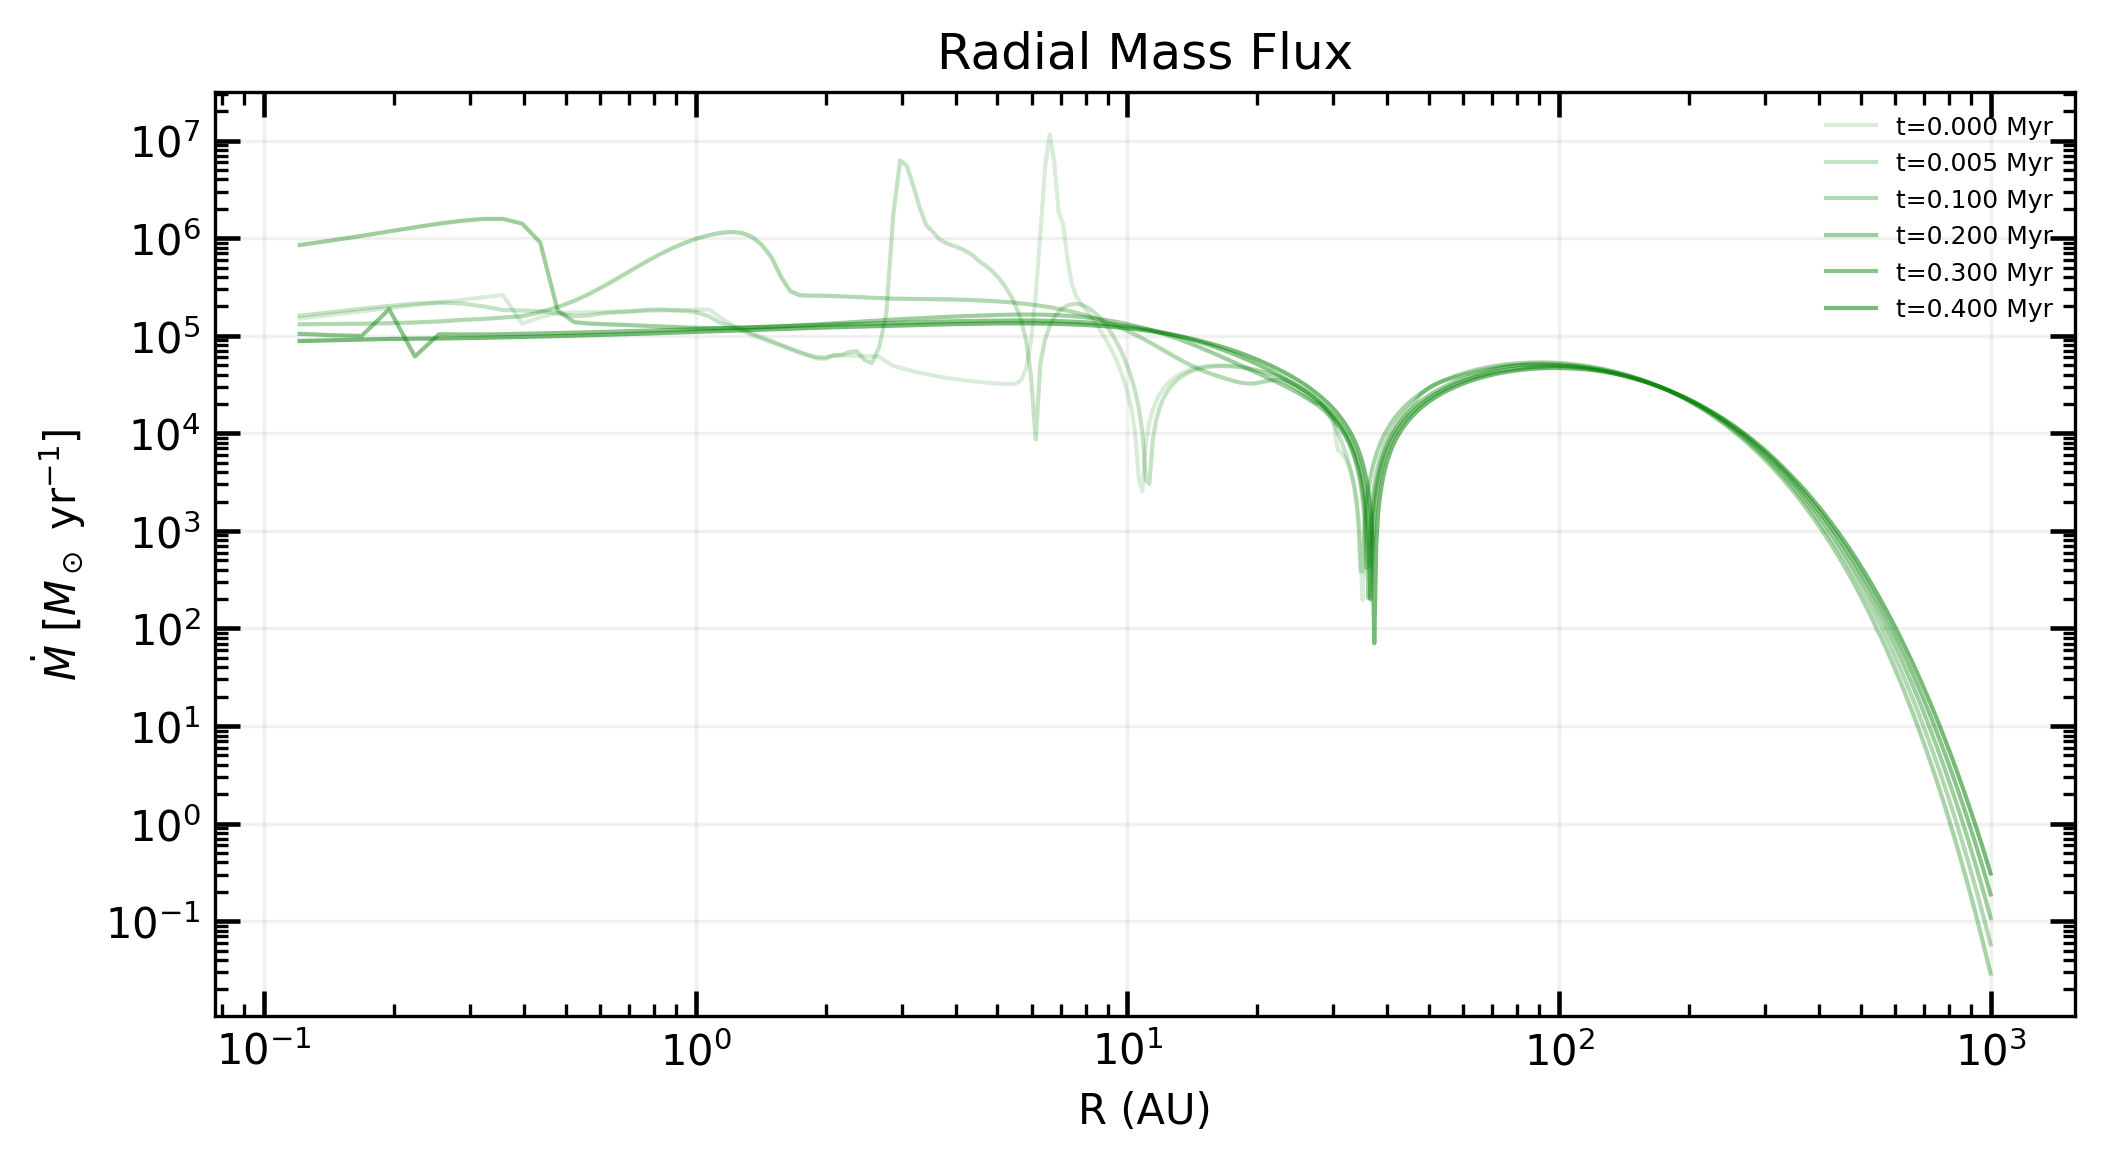

In [46]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR_faces
ydata = cxMdot_r
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, np.abs(ydata[i]*AU), linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

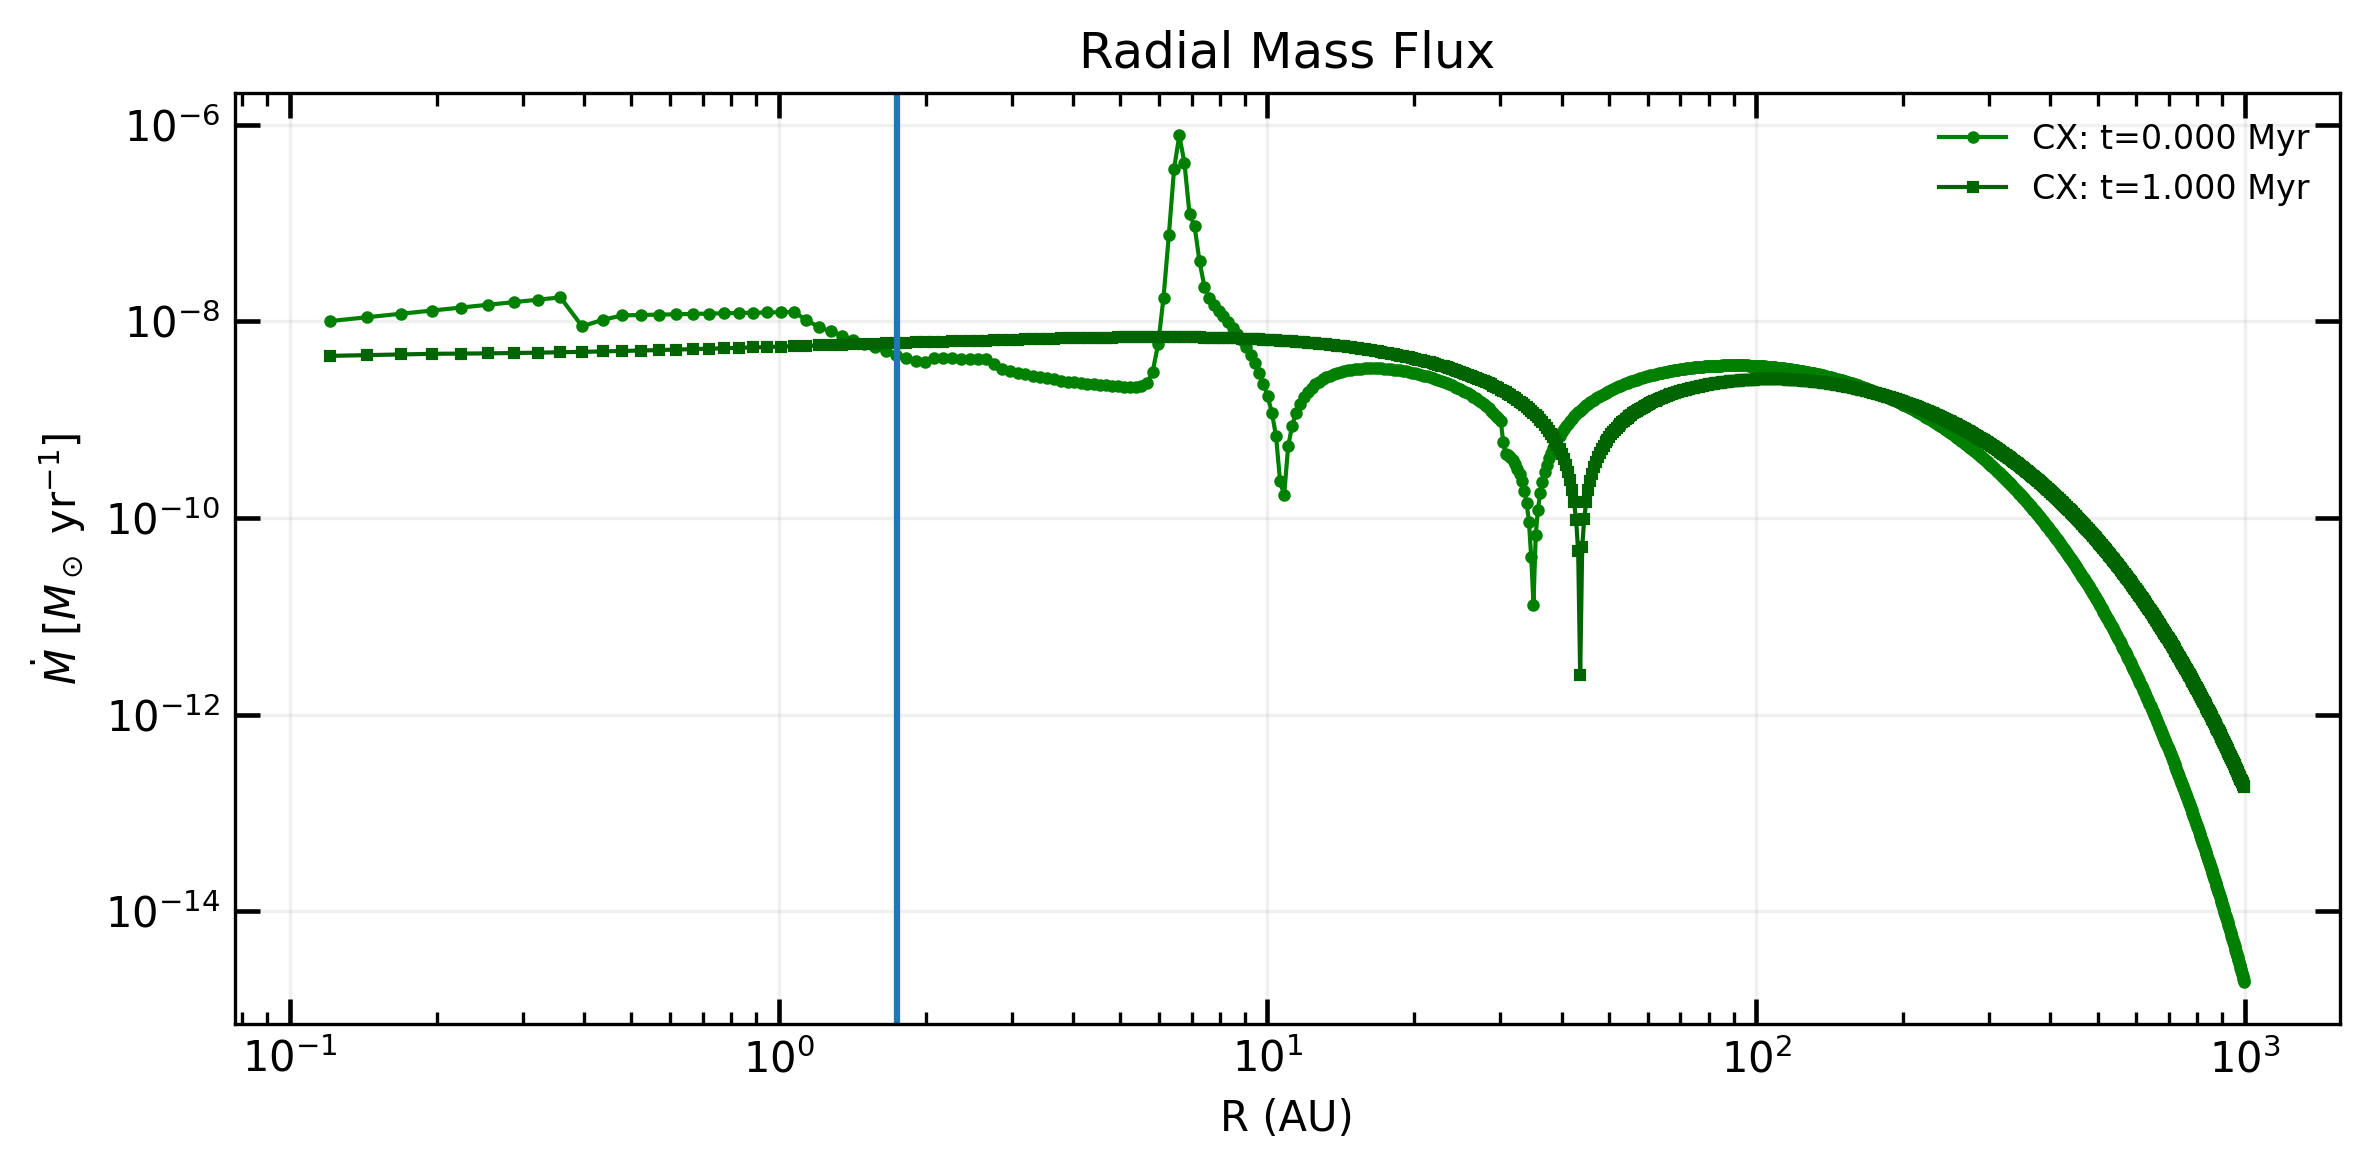

In [47]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')

ax.loglog(cxR_faces, np.abs(cxMdot_r[0]), 'o-', color='green', label=f'CX: t={crt[0]/1e6:.3f} Myr', ms=2, lw=1)
ax.loglog(cxR_faces, np.abs(cxMdot_r[-1]), 's-', color='darkgreen', label=f'CX: t={crt[-1]/1e6:.3f} Myr', ms=2, lw=1)

ax.axvline(1.75)
ax.axhline(0, color='k', linestyle=':', lw=0.8)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Elsasser Solver Test

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from DiscEvolution.eos import DeadZoneEOS
from DiscEvolution.star import SimpleStar
from DiscEvolution.grid import Grid
from DiscEvolution.opacity import Zhu2012

# Create a minimal DeadZoneEOS instance just for testing the tolerance function
star = SimpleStar(M=1.0, R=2.5, T_eff=4000)
grid = Grid(0.1, 1000, 1000)  # Small grid for testing

# Initialize DeadZoneEOS with minimal required parameters
eos_test = DeadZoneEOS(
    star,
    psi=1.0,
    Mdot=1e-8,
    alpha_guess=1e-5,  # Required parameter
    evolution_model='static',  # Static model for testing
    kappa=Zhu2012,
    warm_start=False
)
eos_test.set_grid(grid)

print("DeadZoneEOS initialized for testing")
print(f"Grid: {len(grid.Rc)} cells from {grid.Rc[0]:.2f} to {grid.Rc[-1]:.1f} AU")

DeadZoneEOS initialized for testing
Grid: 1000 cells from 0.10 to 995.4 AU


In [49]:
# Test Case 1: Perfect monotonic profile (increasing with radius)
# Inner regions: low Lambda (dead), Outer regions: high Lambda (active)
R_test = np.linspace(0.1, 100, 100)
Lambda_mono = 0.525 * (1 + np.tanh((R_test - 5) / 2))  # Smooth S-curve: ranges ~0 to ~1.1

tol0 = 1e-3
Rdz_mono = eos_test._find_deadzone_radius(R_test, Lambda_mono)
print(f"Test 1 - Monotonic profile (dead inner, active outer):")
print(f"  Rdz = {Rdz_mono:.3f} AU")
print(f"  Lambda at Rdz = {np.interp(Rdz_mono, R_test, Lambda_mono):.4f} (should be ~1.0)")
print(f"  Lambda at inner edge (R={R_test[0]:.1f} AU) = {Lambda_mono[0]:.4f}")
print(f"  Lambda at outer edge (R={R_test[-1]:.1f} AU) = {Lambda_mono[-1]:.4f}\n")

Test 1 - Monotonic profile (dead inner, active outer):
  Rdz = 8.054 AU
  Lambda at Rdz = 1.0000 (should be ~1.0)
  Lambda at inner edge (R=0.1 AU) = 0.0078
  Lambda at outer edge (R=100.0 AU) = 1.0500



In [50]:
# Test Case 2: Non-monotonic with oscillations (still increasing overall)
# Add wiggles around the main trend while preserving dead→active transition
Lambda_wiggly = 0.5 * (1 + np.tanh((R_test - 5) / 2)) + 0.1 * np.sin(8 * R_test)

tol1 = 1e-2
Rdz_wiggly = eos_test._find_deadzone_radius(R_test, Lambda_wiggly)
print(f"Test 2 - Wiggly profile (tol={tol1}):")
print(f"  Rdz = {Rdz_wiggly:.3f} AU")
print(f"  Lambda at Rdz = {np.interp(Rdz_wiggly, R_test, Lambda_wiggly):.4f}\n")

# Test with stricter tolerance
tol2 = 3e-2
Rdz_wiggly_strict = eos_test._find_deadzone_radius(R_test, Lambda_wiggly)
print(f"Test 2b - Same profile (tol={tol2}, stricter):")
print(f"  Lambda at Rdz = {np.interp(Rdz_wiggly_strict, R_test, Lambda_wiggly):.4f}\n")
print(f"  Rdz = {Rdz_wiggly_strict:.3f} AU\n")

Test 2 - Wiggly profile (tol=0.01):
  Rdz = 7.857 AU
  Lambda at Rdz = 1.0000

Test 2b - Same profile (tol=0.03, stricter):
  Lambda at Rdz = 1.0000

  Rdz = 7.857 AU



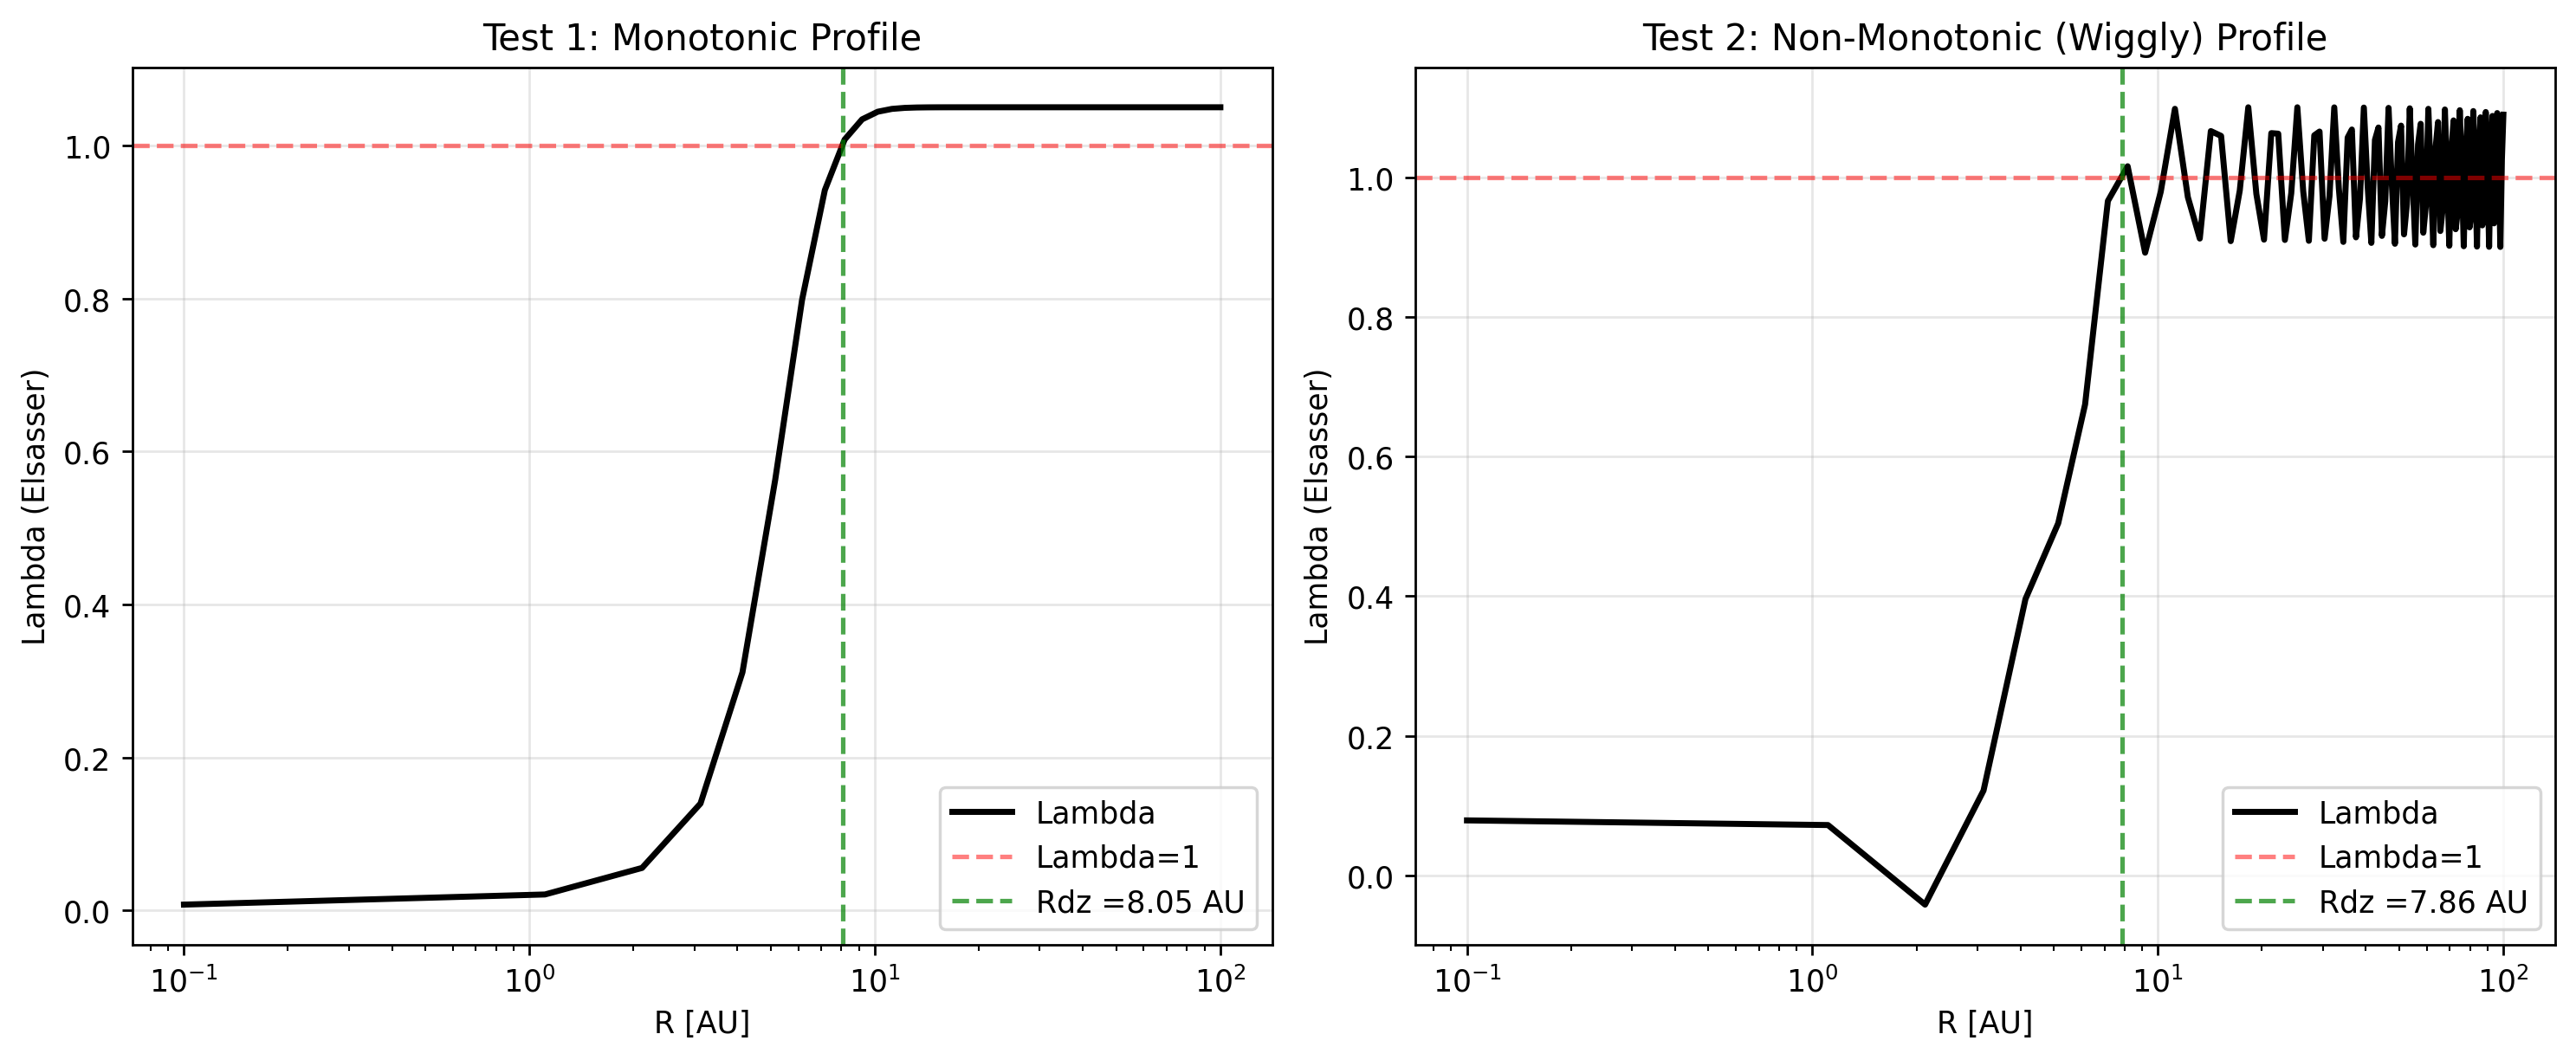

In [51]:
# Visualize the test cases
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi = 250)

# Test 1: Monotonic
ax = axes[0]
ax.semilogx(R_test, Lambda_mono, 'k-', linewidth=2, label='Lambda')
ax.axhline(1, color='r', linestyle='--', alpha=0.5, label='Lambda=1')
ax.axvline(Rdz_mono, color='g', linestyle='--', alpha=0.7, label=f'Rdz ={Rdz_mono:.2f} AU')
ax.set_xlabel('R [AU]')
ax.set_ylabel('Lambda (Elsasser)')
ax.set_title('Test 1: Monotonic Profile')
ax.legend()
ax.grid(True, alpha=0.3)

# Test 2: Wiggly
ax = axes[1]
ax.semilogx(R_test, Lambda_wiggly, 'k-', linewidth=2, label='Lambda')
ax.axhline(1, color='r', linestyle='--', alpha=0.5, label='Lambda=1')
ax.axvline(Rdz_wiggly, color='g', linestyle='--', alpha=0.7, label=f'Rdz ={Rdz_wiggly:.2f} AU')
ax.set_xlabel('R [AU]')
ax.set_ylabel('Lambda (Elsasser)')
ax.set_title('Test 2: Non-Monotonic (Wiggly) Profile')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
L = cxLam
R = cxR

for i, _ in enumerate(cxidx):
    Rdz = eos_test._find_deadzone_radius(cxR, cxLam[i])
    print(f"t={cxt[i]/1e6:.3f} Myr: Computed Rdz = {Rdz:.3f} AU, Stored Rdz = {cxRdz[i]:.3f} AU")

t=0.000 Myr: Computed Rdz = 4.110 AU, Stored Rdz = 4.110 AU
t=0.001 Myr: Computed Rdz = 4.004 AU, Stored Rdz = 4.004 AU
t=0.001 Myr: Computed Rdz = 3.917 AU, Stored Rdz = 3.917 AU
t=0.001 Myr: Computed Rdz = 3.866 AU, Stored Rdz = 3.866 AU
t=0.001 Myr: Computed Rdz = 3.795 AU, Stored Rdz = 3.795 AU
t=0.002 Myr: Computed Rdz = 3.756 AU, Stored Rdz = 3.756 AU
t=0.002 Myr: Computed Rdz = 3.697 AU, Stored Rdz = 3.697 AU
t=0.002 Myr: Computed Rdz = 3.658 AU, Stored Rdz = 3.658 AU
t=0.003 Myr: Computed Rdz = 3.634 AU, Stored Rdz = 3.634 AU
t=0.003 Myr: Computed Rdz = 3.593 AU, Stored Rdz = 3.593 AU
t=0.003 Myr: Computed Rdz = 3.549 AU, Stored Rdz = 3.549 AU
t=0.004 Myr: Computed Rdz = 3.511 AU, Stored Rdz = 3.511 AU


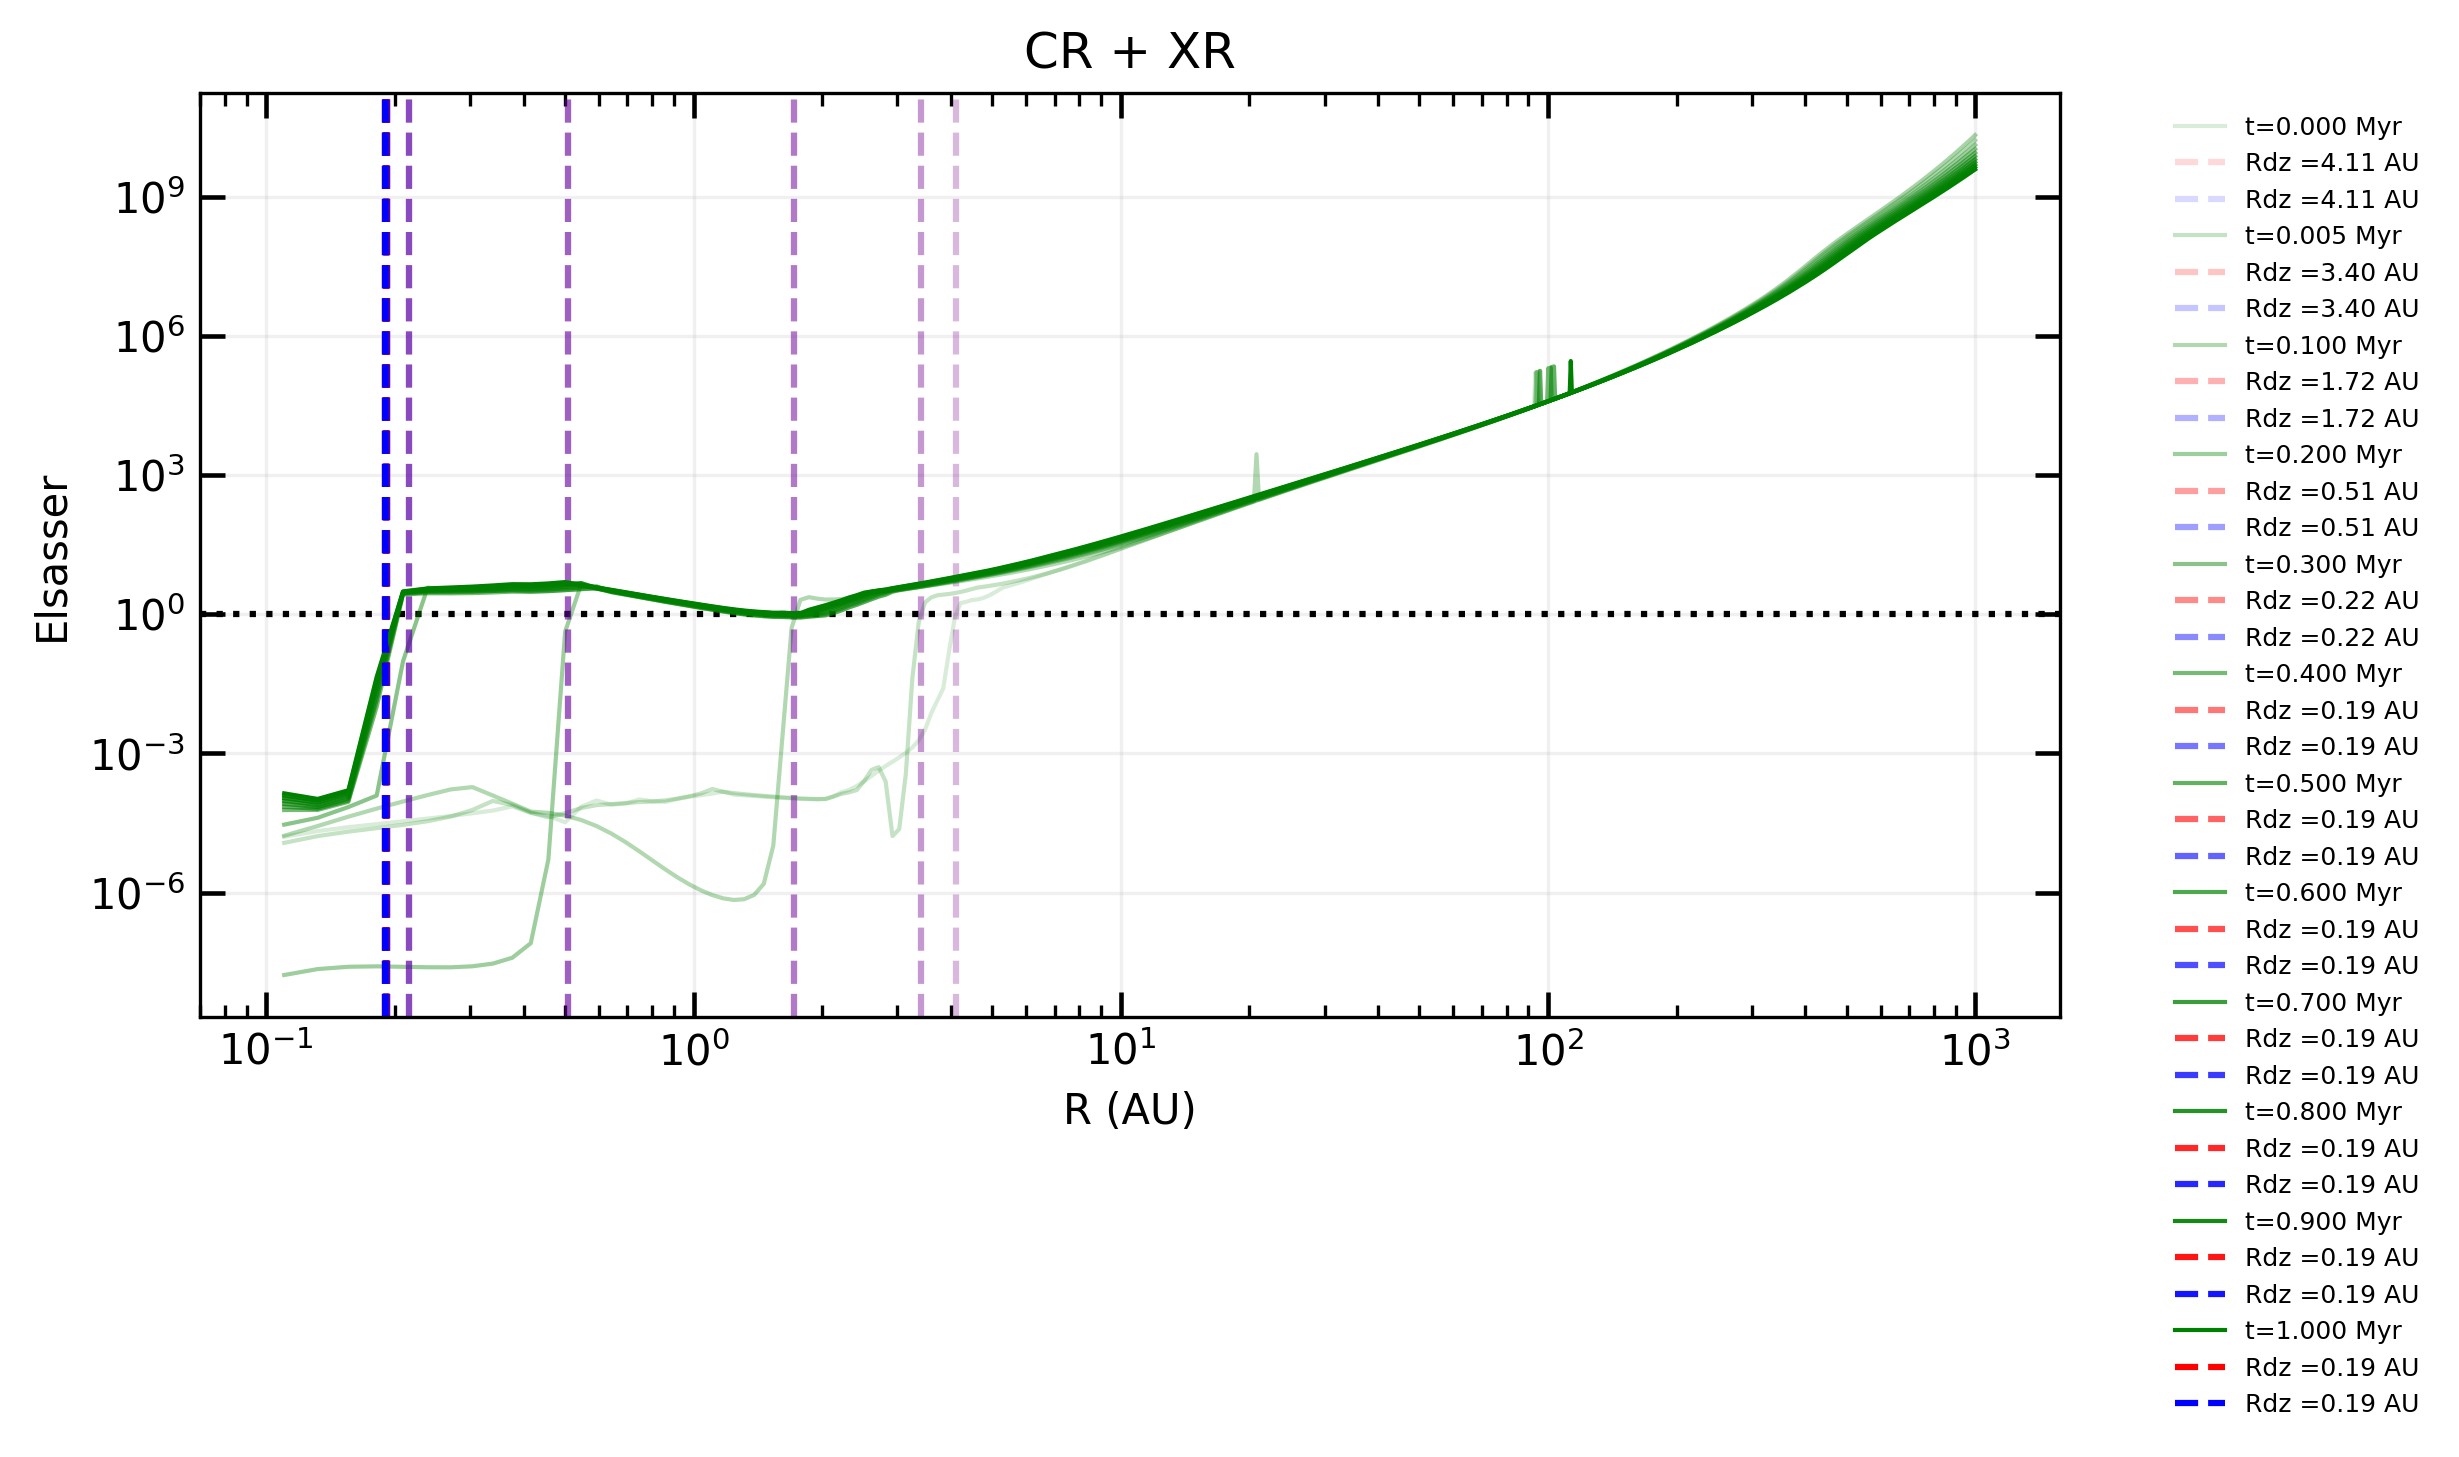

In [53]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Elsasser')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)
ax.axhline(y = 1.0, color = 'black', ls = 'dotted')

xdata = cxR
ydata = cxLam
for a_i, i in enumerate(cxidx):
    Rdz = eos_test._find_deadzone_radius(cxR, cxLam[i])
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)
    ax.axvline(Rdz, color='red', linestyle='--', alpha=alphas[a_i], label=f'Rdz ={Rdz:.2f} AU')
    ax.axvline(cxRdz[i], color='blue', linestyle='--', alpha=alphas[a_i], label=f'Rdz ={cxRdz[i]:.2f} AU')

ax.legend(frameon=False, fontsize=6, bbox_to_anchor=(1.05, 1.0), loc='upper left')

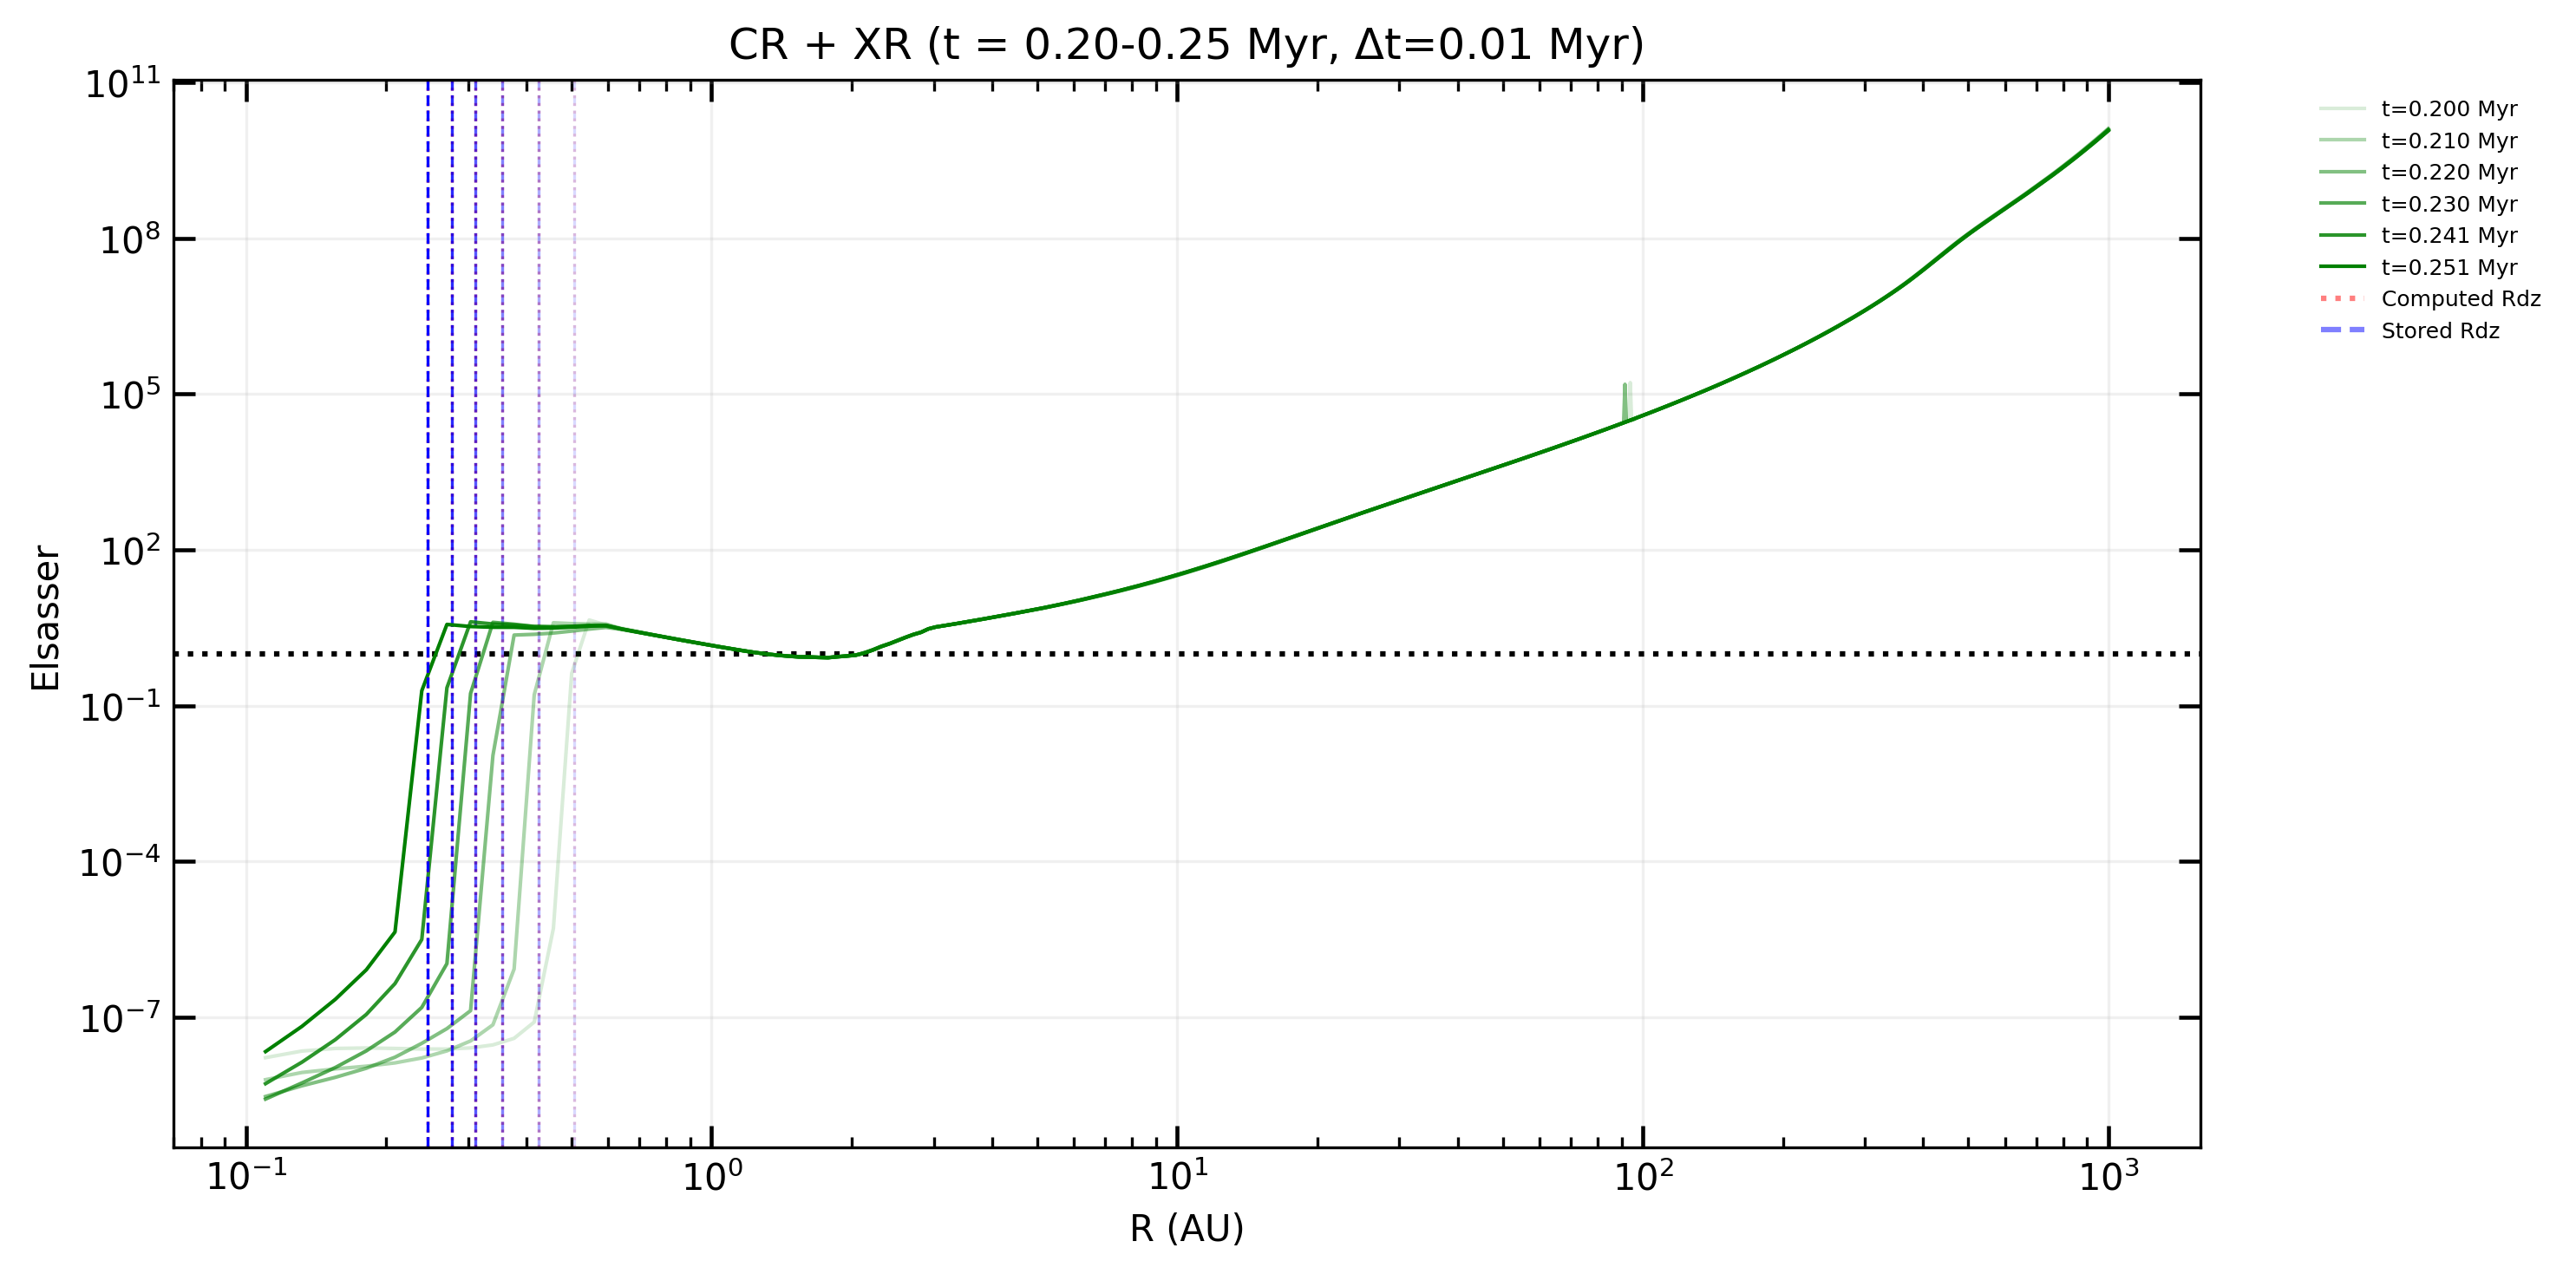

In [54]:
time_min = 0.2  # Myr
time_max = 0.25  # Myr
time_step = 0.01  # Myr

# Create array of desired times in years
times_myr = np.arange(time_min, time_max + time_step/2, time_step)
times_yr = times_myr * 1e6

# Find closest index in cxt for each desired time
sampled_idx = np.searchsorted(cxt, times_yr)
sampled_idx = np.clip(sampled_idx, 0, len(cxt) - 1)

# Double-check we're within range
mask = (cxt[sampled_idx] >= times_yr[0]) & (cxt[sampled_idx] <= times_yr[-1] + time_step*1e6)
sampled_idx = sampled_idx[mask]
times_myr_actual = cxt[sampled_idx] / 1e6

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
alphas = np.linspace(0.15, 1.0, len(sampled_idx)) if len(sampled_idx) > 1 else [1.0]

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Elsasser')
plt.title(f'CR + XR (t = {time_min:.2f}-{time_max:.2f} Myr, Δt={time_step:.2f} Myr)')
ax.axhline(y=1.0, color='black', ls='dotted')

xdata = cxR
ydata = cxLam

for a_i, i in enumerate(sampled_idx):
    Rdz = eos_test._find_deadzone_radius(cxR, cxLam[i])
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
              label=rf"t={times_myr_actual[a_i]:.3f} Myr", lw=1.0)
    ax.axvline(Rdz, color='red', linestyle=':', alpha=alphas[a_i], linewidth=0.8)
    ax.axvline(cxRdz[i], color='blue', linestyle='--', alpha=alphas[a_i], linewidth=0.8)

# Add legend entries for the vertical lines
ax.axvline(0, color='red', linestyle=':', alpha=0.5, label=f'Computed Rdz')
ax.axvline(0, color='blue', linestyle='--', alpha=0.5, label='Stored Rdz')

ax.legend(frameon=False, fontsize=6, bbox_to_anchor=(1.05, 1.0), loc='upper left')
#ax.set_ylim(0.5,1.5)

plt.tight_layout()
plt.show()